# Experiment 2 (MNIST): Lipschitz Estimation on Real Classifiers

## Motivation and relation to Experiment 1

Experiment 1 (`toy_example`, sibling folder) built three ways to estimate
a function's **Lipschitz constant** `L` -- how much its output can change
for a given change in input, `|f(x')-f(x)| <= L * ||x'-x||` -- and
validated all three against a **known, closed-form ground truth** `L*` on
a toy 1D/2D regression problem. It also showed that replacing plain
Euclidean distance with a **Mahalanobis distance** fit from the data
itself can substantially change (and, there, improve) the resulting
estimate.

This experiment scales the same three estimators up to real classifiers
trained on MNIST. **There is no closed-form `L*` here** -- a trained
neural network's exact Lipschitz constant is not analytically knowable in
general. So this experiment cannot ask "how close is the estimate to the
truth"; it can only ask two weaker but still meaningful questions:

1. **Do the three independent sub-methods (pairwise, local-perturbation,
   gradient-norm) roughly agree with each other?** Disagreement doesn't
   necessarily mean a bug (see this notebook's results below -- it turns
   out they *don't* agree well here, and that's a real, reportable
   finding, not an error), but it tells you how much to trust any single
   number.
2. **Is the estimate stable under resampling?** An estimate that swings
   wildly depending on which random subset of the data it was computed
   from is fitting sampling noise, not a real property of the model.

These two checks -- sub-method agreement and subsample stability --
replace Experiment 1's "compare to `L*`" checkpoint everywhere in this
notebook.

**Out of scope for this notebook**: adversarial examples, FGSM/PGD attacks, robustness
mitigations, layer decomposition -- covered in the sibling `notebook_adversarial.ipynb`
instead, matching this project's `distance_measures.md`/`adversarial.md` doc split.

## What's being measured

Instead of a scalar regression output `f(x)` (Experiment 1), a classifier
outputs 10 logits. The Lipschitz estimators here are applied to the
**margin function**, `margin(x) = logit[y_true] - max(logit[j] for j !=
y_true)` -- the natural classifier analogue of a scalar output, and the
quantity robustness actually depends on: the margin crossing zero is
exactly where the predicted class flips.

Three classifiers are trained (logistic regression, a small MLP, a small
CNN), and for each, all three sub-methods are computed twice: once under
plain Euclidean distance, once under a **ridge-regularized Mahalanobis
distance** fit from MNIST's own pixel covariance (raw pixel covariance is
exactly singular -- many border pixels are 0 in every image -- so it must
be regularized before it can be inverted; how much regularization to use
is itself selected by a data-driven sweep, mirroring Experiment 1's
polynomial-embedding-degree selection).

This is a thin driver notebook -- all reusable logic lives in the sibling
`.py` modules (`data.py`, `models.py`, `estimators.py`, `distance.py`,
`run_experiment.py`, `plots.py`); this notebook only calls into them and
displays the results. See `README.md` in this folder for a plain
file-by-file reference of the codebase and `distance_measures.md` for the
full write-up of what was found.

## Notebook contents

1. **Main experiment** (below): logistic regression, MLP, and CNN, all three Lipschitz
   sub-methods, Euclidean vs. Mahalanobis, the embedding-degree sweep.
2. **UMAP as an alternative distance metric** -- a *learned* embedding instead of a
   hand-built one.
3. **Smoothing, the `radius_multiplier` sweep, and truncated-eigenvalue Mahalanobis** --
   three follow-ups fixing/refining `local_patch_cross_terms`'s Mahalanobis instability.

In [1]:
%pip install scikit-learn

Note: you may need to restart the kernel to use updated packages.


In [2]:
import sys
from pathlib import Path

sys.path.insert(0, str(Path.cwd().parent))

%load_ext autoreload
%autoreload 2

%matplotlib inline
import matplotlib.pyplot as plt
from IPython.display import display

from mnist_example import run_experiment, plots

## Running the full experiment

`run_mnist_experiment()` runs, in order:

1. **Train** logistic regression, MLP, and a small CNN on full MNIST.
2. **Euclidean-distance estimates**: all three sub-methods (pairwise,
   local-perturbation, gradient-norm), on all three models, evaluated on a
   fixed set of held-out test points.
3. **Epsilon selection**: fit the full-training-set pixel covariance,
   sweep several candidate ridge strengths (`epsilon`), and pick the
   smallest one whose regularized covariance is well-conditioned *and*
   whose resulting estimate is stable across independent random
   subsamples of the training data.
4. **Mahalanobis-distance estimates**: the same three sub-methods on the
   same three models, now under the selected Mahalanobis distance.
5. **Save** everything to `results/` (`mnist_experiment_results.json` for
   scalar summaries, `mnist_experiment_arrays.npz` for the full per-point
   arrays).

This takes about a minute on CPU.

In [3]:
results = run_experiment.run_mnist_experiment()

=== Step 1: training models ===


  epoch  1/15  train loss 0.8430


  epoch  2/15  train loss 0.4254


  epoch  3/15  train loss 0.3603


  epoch  4/15  train loss 0.3299


...

  mlp: pairwise=1.1760  local_max=0.3674  grad_max=16.0362  grad_mean=9.6752


  cnn: pairwise=1.0345  local_max=0.1868  grad_max=10.1109  grad_mean=5.3112

=== Step 4b: Mahalanobis ratio-distribution analysis (epsilon=0.01, all models) ===


  [mahalanobis/logistic_regression] all-pairs ratio:        mean=0.1389  max=1.2492  n=499500
  [mahalanobis/logistic_regression] near-neighbor ratio:     mean=0.1078  max=1.0980  n=5000


  [mahalanobis/mlp] all-pairs ratio:        mean=0.1870  max=1.1762  n=499500
  [mahalanobis/mlp] near-neighbor ratio:     mean=0.1537  max=0.9965  n=5000


  [mahalanobis/cnn] all-pairs ratio:        mean=0.1899  max=1.0681  n=499500
  [mahalanobis/cnn] near-neighbor ratio:     mean=0.1459  max=0.8733  n=5000

Saved results to /Users/swarn2/Downloads/Datasig-1/mnist_example/results


## Model accuracies

Sanity check before looking at any Lipschitz numbers: did training
actually work? (Thresholds validated in `tests/test_models.py`: logistic
regression > 90%, MLP > 96%, CNN > 98%, each with headroom below what's
typically observed.)

In [4]:
for name, acc in results["accuracies"].items():
    print(f"{name:20s} train_acc={acc['train']:.4f}  test_acc={acc['test']:.4f}")

logistic_regression  train_acc=0.9287  test_acc=0.9270
mlp                  train_acc=0.9931  test_acc=0.9782
cnn                  train_acc=0.9888  test_acc=0.9860


## Euclidean-distance estimates: do the three sub-methods agree?

Plain Euclidean distance in raw pixel space, for all three models. Each
panel below is one model; the three bars are the three independently
implemented sub-methods, on a log scale (they live on very different
natural scales here, which is itself part of the finding).

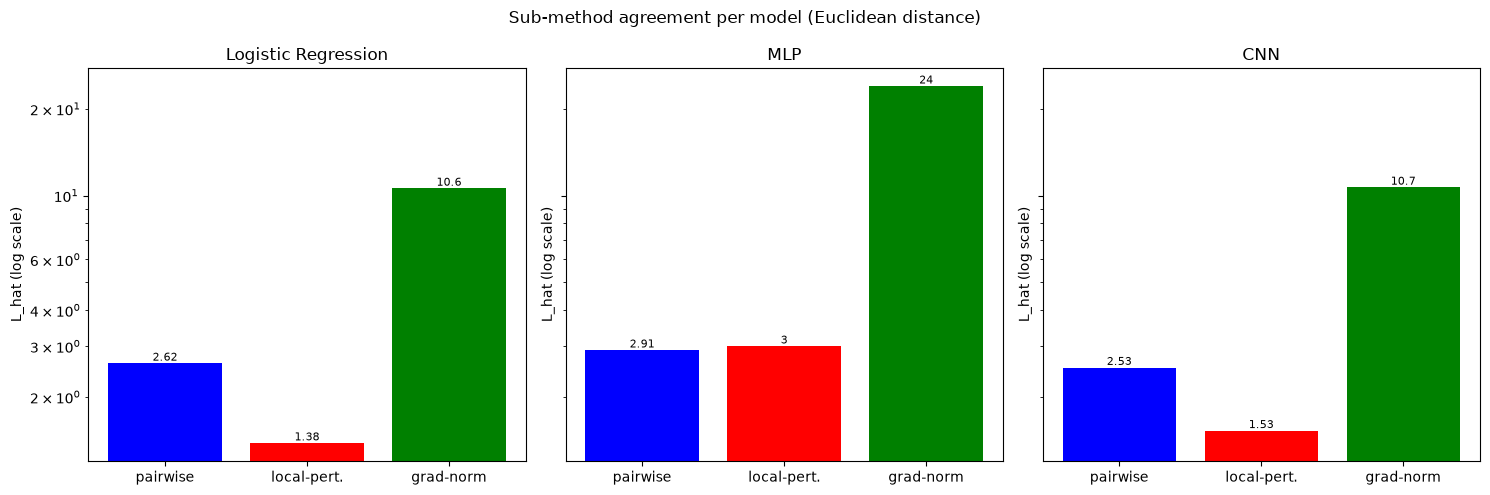

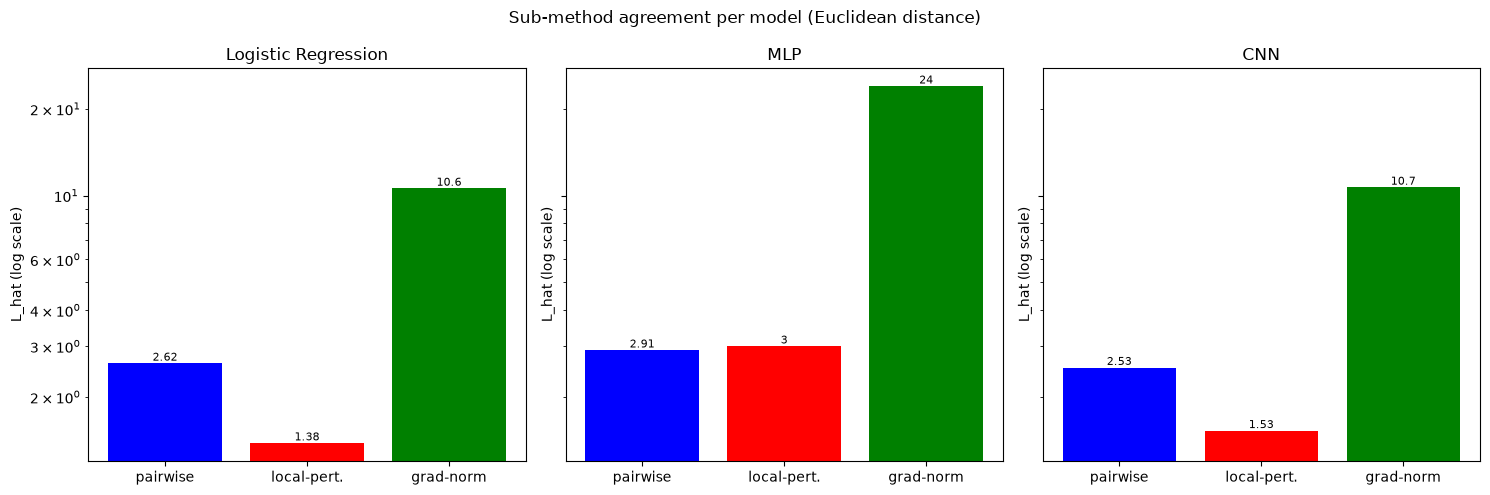

In [5]:
fig_agree_euclidean = plots.plot_submethod_agreement(
    results["euclidean_results"], metric_name="Euclidean",
    save_path=run_experiment.RESULTS_DIR / "submethod_agreement_euclidean.png")
display(fig_agree_euclidean)

## Epsilon selection

MNIST's raw pixel covariance is exactly singular (constant-zero border
pixels), so it can't be inverted directly. The plot below shows, across a
range of candidate `epsilon` values (log scale): the condition number of
the ridge-regularized covariance (should shrink as epsilon grows -- always
true, this is a deterministic mathematical fact) and the coefficient of
variation of the resulting estimate across independent random subsamples
of the training set (should not get *worse* as epsilon grows -- this one
is an empirical check, not a mathematical guarantee, and is where a real
implementation bug would show up first). The selected epsilon (dashed
line) is the smallest one meeting both a condition-number bound and a
stability bound.

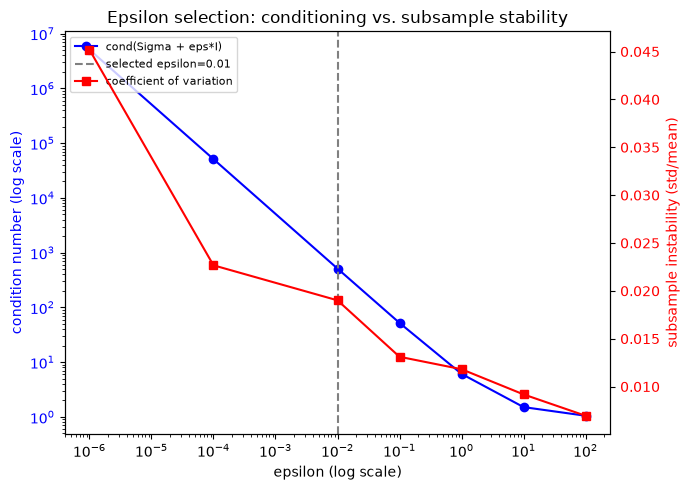

selected epsilon = 0.01


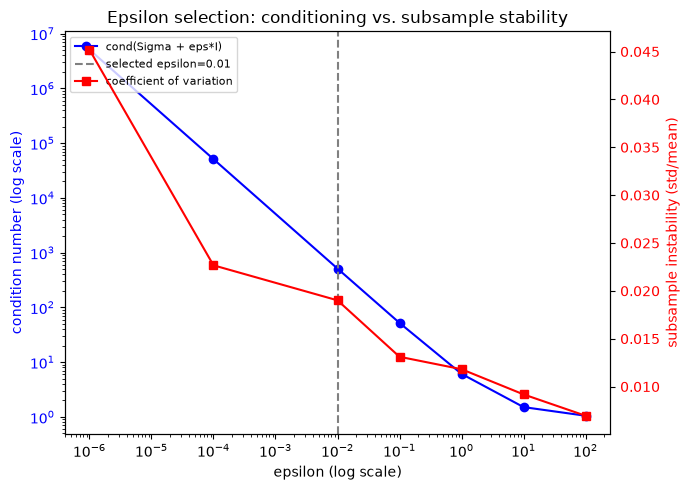

In [6]:
fig_epsilon = plots.plot_epsilon_sweep(
    results["epsilon_values"], results["cond_numbers"], results["cv_values"],
    selected_epsilon=results["selected_epsilon"],
    save_path=run_experiment.RESULTS_DIR / "epsilon_sweep.png")
display(fig_epsilon)
print(f"selected epsilon = {results['selected_epsilon']:g}")

## Why regularization is needed: the covariance's eigenvalue spectrum

The epsilon sweep above is a downstream *consequence* of a more basic
fact: MNIST's raw pixel covariance `Sigma` is singular. This section
makes that directly visible by plotting `Sigma`'s eigenvalue spectrum
(sorted largest to smallest, log scale), together with the
ridge-regularized spectrum `Sigma + epsilon*I` at the epsilon selected
above.

`Sigma + epsilon*I` has the *same eigenvectors* as `Sigma` -- adding
`epsilon*I` only shifts every eigenvalue up by exactly `epsilon` -- so the
two curves below differ only where `epsilon` actually matters: once an
eigenvalue of `Sigma` drops below `epsilon`, the regularized curve
flattens out at `epsilon` instead of continuing to fall, which is exactly
what keeps `(Sigma + epsilon*I)^{-1}` (the precision matrix used for
Mahalanobis distance) from blowing up in those directions.

largest eigenvalue:  5.1169
smallest eigenvalue: 6.1375e-34
eigenvalues below 1e-6: 94 / 784


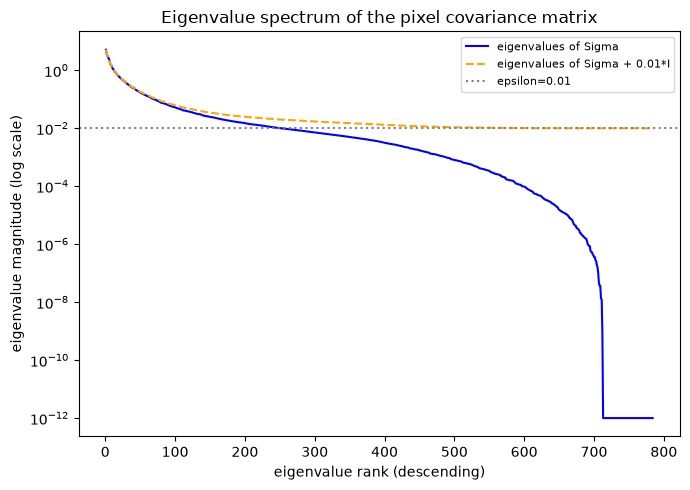

In [7]:
eigenvalues = results["covariance_eigenvalues"]
fig_eigenvalues = plots.plot_covariance_eigenvalues(
    eigenvalues, epsilon=results["selected_epsilon"],
    save_path=run_experiment.RESULTS_DIR / "covariance_eigenvalues.png")

n_near_zero = (eigenvalues < 1e-6).sum().item()
print(f"largest eigenvalue:  {eigenvalues[0].item():.4f}")
print(f"smallest eigenvalue: {eigenvalues[-1].item():.4e}")
print(f"eigenvalues below 1e-6: {n_near_zero} / {len(eigenvalues)}")

## Mahalanobis vs. Euclidean: does the metric change the estimates?

This is the central question of the experiment -- the same question
Experiment 1 asked on the toy problem, now on real classifiers. Same
three models, same three sub-methods, only the distance metric changes.

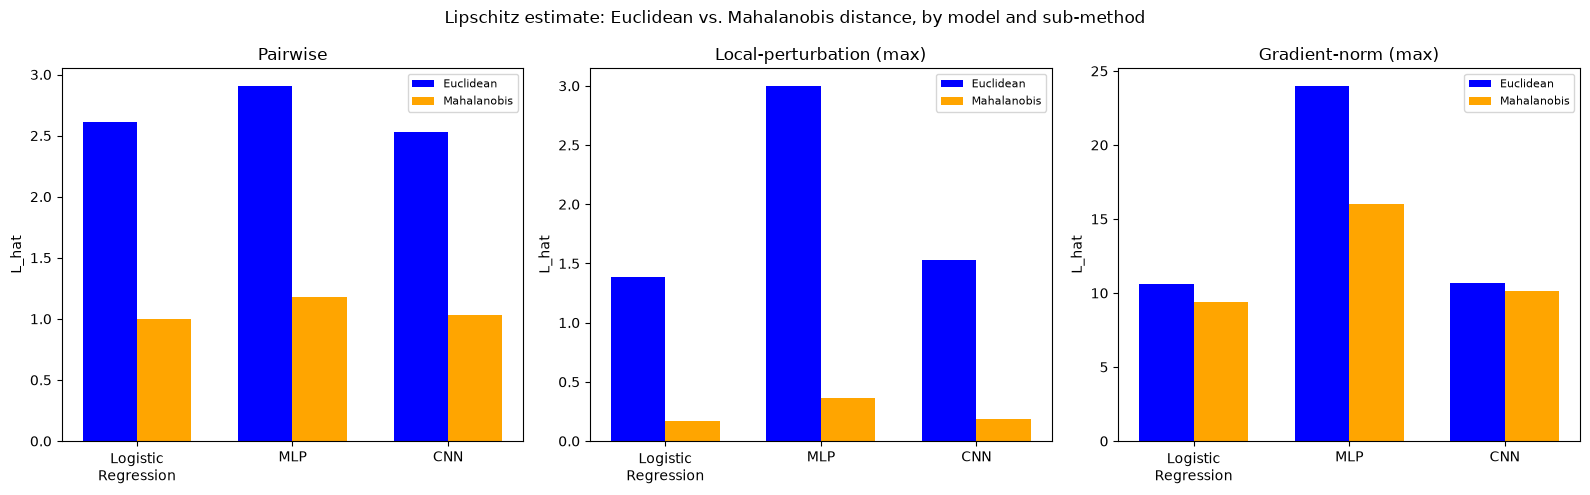

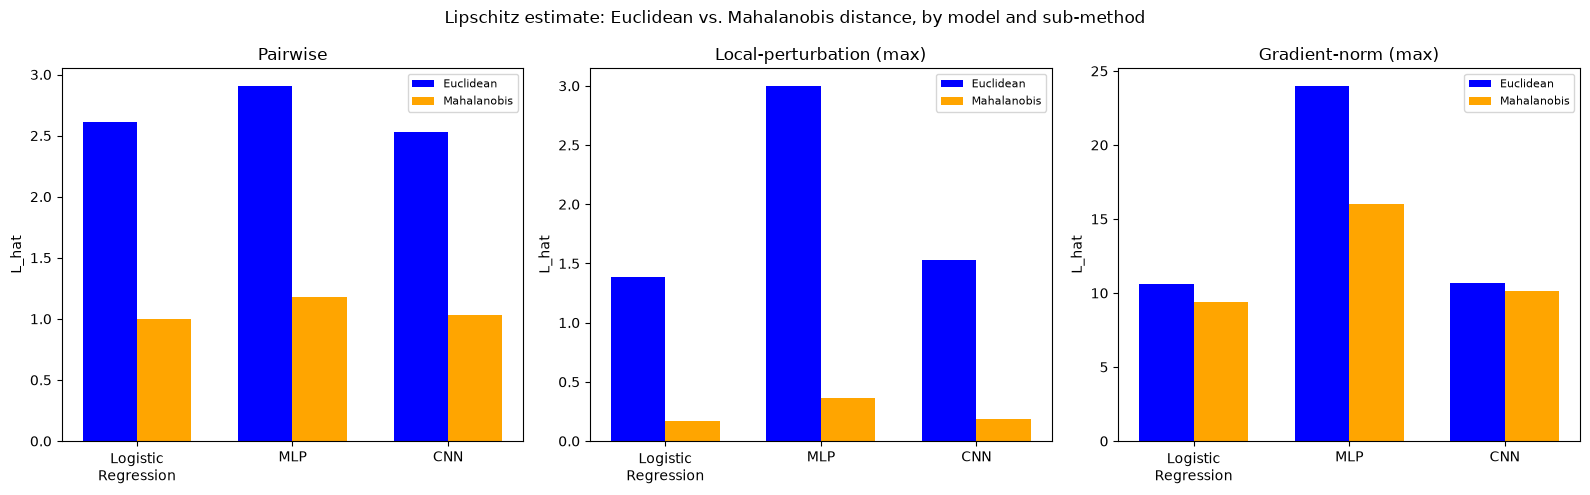

In [8]:
fig_compare = plots.plot_euclidean_vs_mahalanobis(
    results["euclidean_results"], results["mahalanobis_results"],
    save_path=run_experiment.RESULTS_DIR / "euclidean_vs_mahalanobis.png")
display(fig_compare)

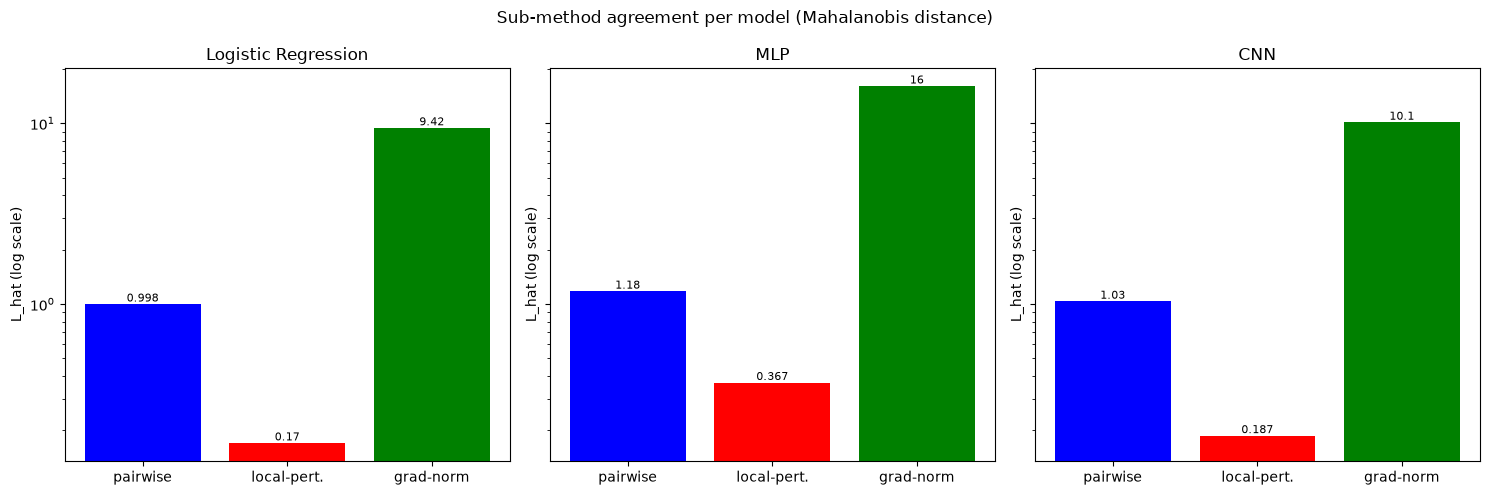

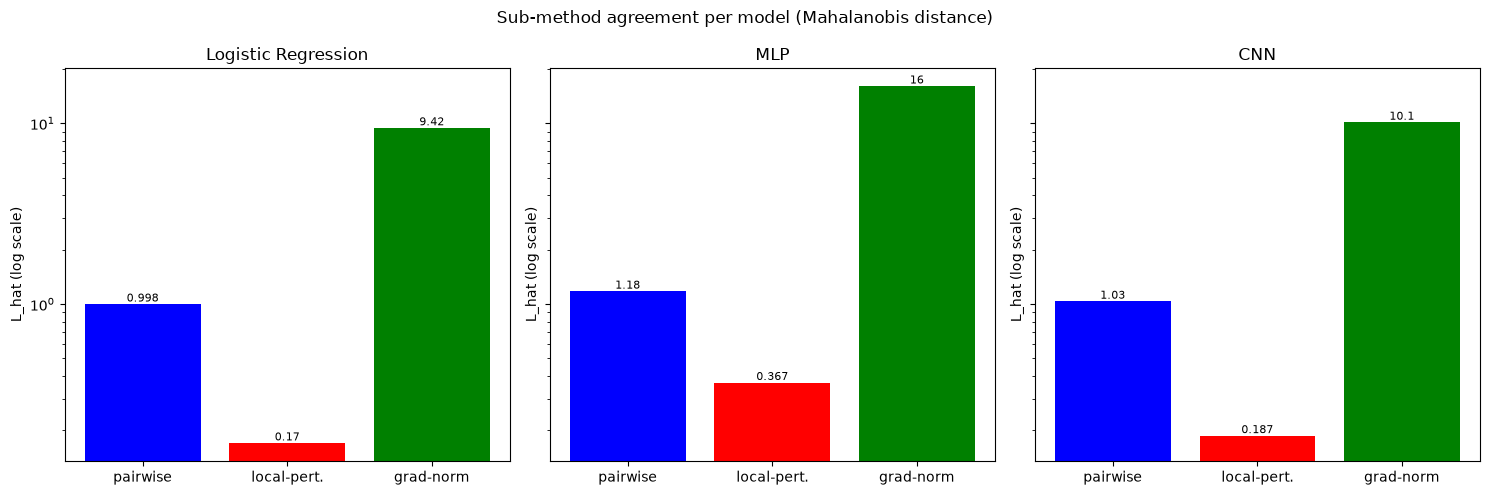

In [9]:
fig_agree_mahalanobis = plots.plot_submethod_agreement(
    results["mahalanobis_results"], metric_name="Mahalanobis",
    save_path=run_experiment.RESULTS_DIR / "submethod_agreement_mahalanobis.png")
display(fig_agree_mahalanobis)

## Ratio distribution and near-neighbour pairs

Every checkpoint above looks at a single summary number per model/metric
-- a max (`pairwise`), or a max/mean over a few hundred points. This
checkpoint instead looks at the full **distribution** of pairwise ratios,
`|margin_i - margin_j| / distance(x_i, x_j)`, computed over all pairs in
a **stratified sample** of 1000 test points (roughly 100 per digit, so no
class dominates by chance) that's disjoint from the 300-point sample used
above.

It then asks a more specific question: does that distribution look
different when restricted to **near-neighbour** pairs -- points that are
actually close together in raw pixel space (5-nearest-neighbours), rather
than arbitrary pairs of digits that may look nothing alike? This matters
because adversarial-style local stretch is a *local* phenomenon: the
ratio between two visually unrelated digits (a 1 and an 8 on opposite
sides of pixel space) says little about how sensitive the model is to a
*small* perturbation, whereas the ratio between two visually similar
images is closer to what a local Lipschitz constant is actually meant to
capture.

This is now run for **all three models**, under **Euclidean distance**.
The Mahalanobis distance is a planned follow-up, reusing the
epsilon/precision already selected below (Epsilon selection) rather than
re-running epsilon selection.

In [10]:
# Reuses the result already computed inside run_mnist_experiment() above (Step 2b),
# for all three models -- run_ratio_distribution_analysis is directly callable with a
# different distance_fn (e.g. Mahalanobis) when extending further.
ratio_dist_euclidean_results = results["ratio_dist_euclidean_results"]

## Does the distribution shift near neighbours?

For each model: if near-neighbour pairs behaved just like a random pair
of digits, the two distributions in that model's panel below would
overlap almost exactly. If local stretch concentrates near visually
similar images, the near-neighbour curve should sit measurably to the
right of (or otherwise diverge from) the full distribution -- not
necessarily a dramatic difference, but a detectable one.

model                 set                      shape       min       max      mean    median       std
logistic_regression   all pairs            (499500,)    0.0000    2.9369    0.3100    0.2542    0.2483
logistic_regression   near-neighbour         (5000,)    0.0002    2.9369    0.3488    0.2822    0.2897
mlp                   all pairs            (499500,)    0.0000    2.7766    0.4195    0.3460    0.3303
mlp                   near-neighbour         (5000,)    0.0001    2.7766    0.4974    0.4162    0.3867
cnn                   all pairs            (499500,)    0.0000    2.8300    0.4260    0.3579    0.3265
cnn                   near-neighbour         (5000,)    0.0002    2.5000    0.4703    0.3823    0.3801


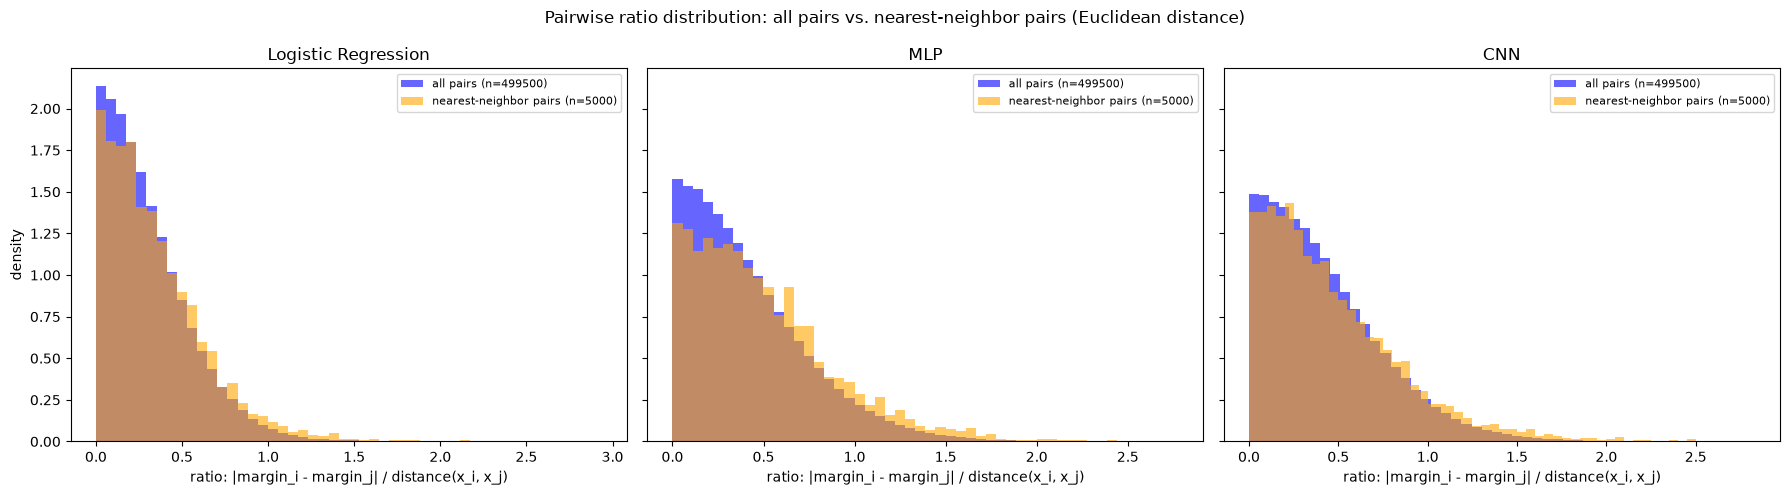

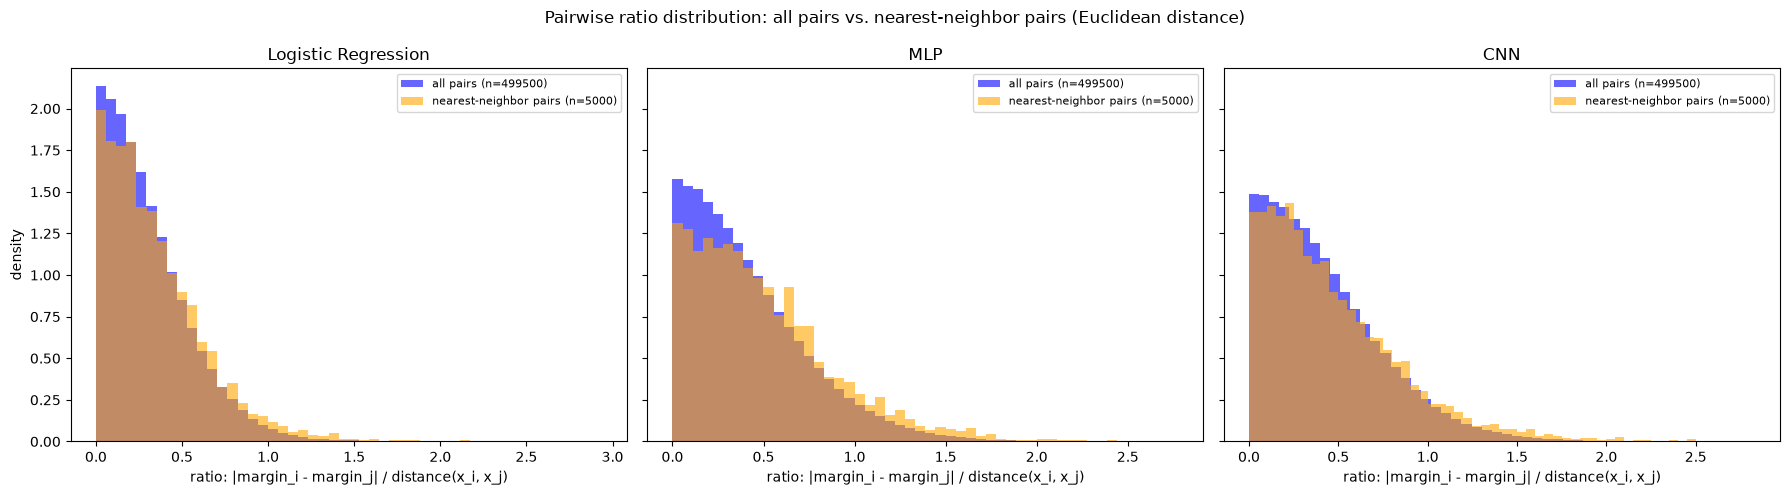

In [11]:
import numpy as np

print(f"{'model':22s}{'set':18s}{'shape':>12}{'min':>10}{'max':>10}{'mean':>10}{'median':>10}{'std':>10}")
for name in ["logistic_regression", "mlp", "cnn"]:
    r = ratio_dist_euclidean_results[name]
    for label, arr in [("all pairs", r["all_pairs_ratio"].numpy()),
                        ("near-neighbour", r["near_neighbor_ratio"].numpy())]:
        print(f"{name:22s}{label:18s}{str(arr.shape):>12}{arr.min():>10.4f}{arr.max():>10.4f}"
              f"{arr.mean():>10.4f}{np.median(arr):>10.4f}{arr.std():>10.4f}")

fig_ratio_dist = plots.plot_ratio_distribution(
    ratio_dist_euclidean_results, metric_name="Euclidean",
    save_path=run_experiment.RESULTS_DIR / "ratio_distribution.png")
display(fig_ratio_dist)

## Highest-ratio near-neighbour pairs

The specific image pairs driving the upper tail of each model's
near-neighbour distribution above -- two pixel-similar digits that
model's margin treats very differently, the exact combination a
local-Lipschitz diagnostic is meant to flag. One gallery per model, shown
separately rather than as subplot panels on one figure (6 pairs x 2
images already fills a figure; three side by side would make each image
too small to actually look at). Each image is labeled with its true and
predicted class and the pair's ratio, deduplicated so a mutual
nearest-neighbour pair only counts once. The printed table also breaks
each ratio into the two components it's built from -- `dist` (the
denominator, distance between the pair) and `|margin_diff|` (the
numerator, absolute margin difference) -- so a high ratio driven by an
unusually small distance can be told apart from one driven by an
unusually large margin swing.

**Finding**: the MLP and CNN's top pairs are genuine cross-digit
confusions, not degenerate or nonsensical matches, and differ by model --
MLP's top 3 are 2/3, 6/5, 3/3; the CNN's are 6/5, 4/9, 2/6. Logistic
regression's top pairs are a different pattern, though: 5 of its top 6
are the *same* digit, "1" vs. "1" (four of those five sharing one image,
test index 5642, as a common member) -- a same-digit high-ratio pattern,
not a cross-digit-confusion one, closer to what the higher-capacity CNN's
"1/1" pairs show in the label-error-cross-reference section further down
than to a decision-boundary story.

*(These specific pairs are sensitive to `n_lipschitz_points`, which sizes
the query set excluded from this near-neighbour subset -- see the
"Validity check" section further down for a documented instance of this
sensitivity and its root cause.)*

=== logistic_regression ===
rank  true1  pred1  true2  pred2    ratio     dist  |margin_diff|
   0      1      5      1      1   2.9369   6.3274        18.5828
   1      1      5      1      1   2.5402   6.2913        15.9811
   2      1      5      1      1   2.4927   6.4059        15.9678
   3      5      5      1      5   2.1507   6.5864        14.1655
   4      1      5      1      1   2.1411   6.4469        13.8036
   5      3      3      3      8   1.8617   7.8491        14.6126


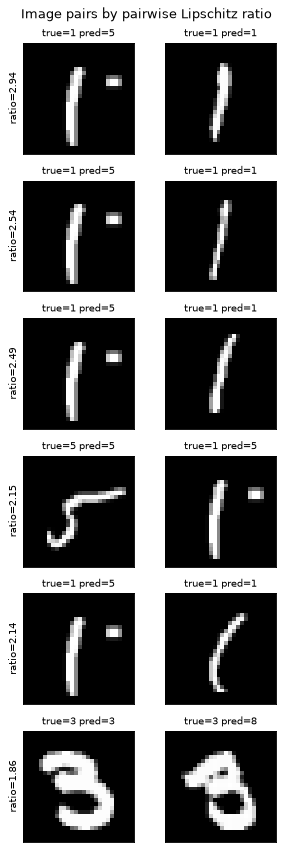

=== mlp ===
rank  true1  pred1  true2  pred2    ratio     dist  |margin_diff|
   0      2      2      3      2   2.7766   8.3542        23.1962
   1      6      5      5      5   2.6147   7.0113        18.3328
   2      3      3      3      5   2.4233   7.0934        17.1896
   3      8      0      0      0   2.2856   8.5718        19.5914
   4      3      8      8      8   2.2490   8.1332        18.2914
   5      1      5      1      1   2.2326   6.2913        14.0459


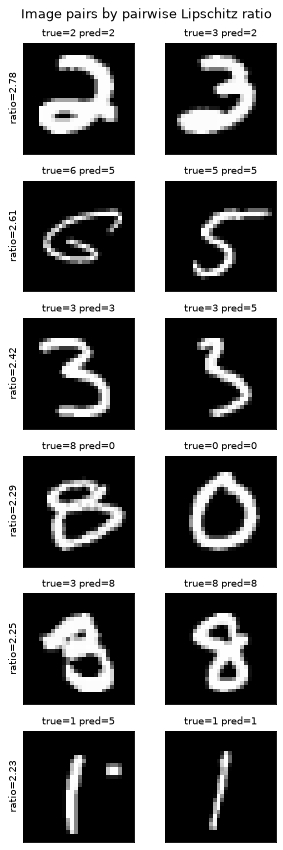

=== cnn ===
rank  true1  pred1  true2  pred2    ratio     dist  |margin_diff|
   0      6      5      5      5   2.5000   7.0113        17.5281
   1      6      6      6      6   2.4775   5.9287        14.6880
   2      9      9      4      4   2.3934   5.9099        14.1445
   3      5      5      8      8   2.2458   7.1257        16.0029
   4      2      0      0      0   2.1892   6.0050        13.1460
   5      2      0      0      0   2.1000   7.1988        15.1173


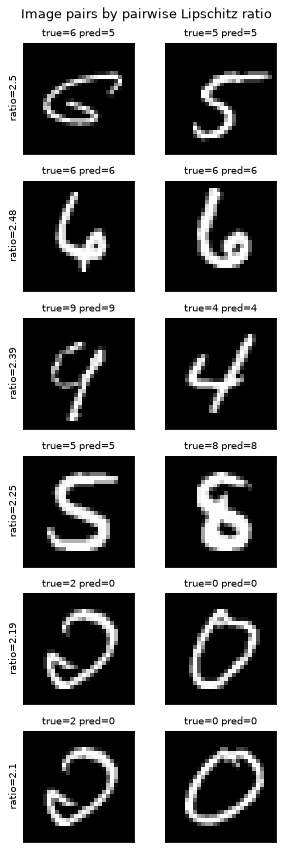

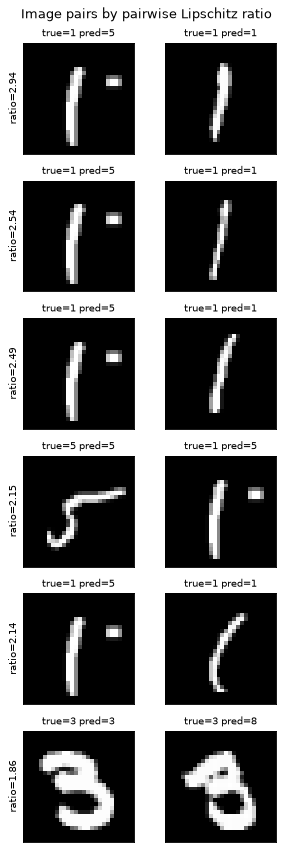

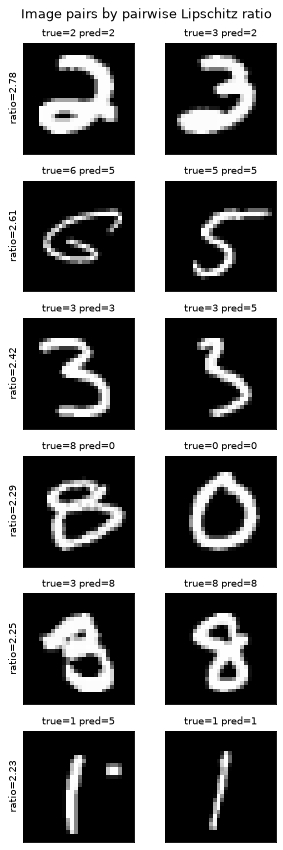

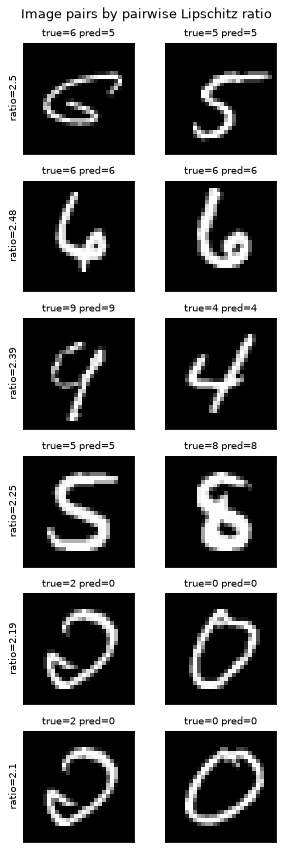

In [12]:
for name in ["logistic_regression", "mlp", "cnn"]:
    top_pairs = ratio_dist_euclidean_results[name]["top_near_neighbor_pairs"]

    print(f"=== {name} ===")
    print(f"{'rank':>4}{'true1':>7}{'pred1':>7}{'true2':>7}{'pred2':>7}{'ratio':>9}{'dist':>9}{'|margin_diff|':>15}")
    for rank, (img1, img2, true1, pred1, true2, pred2, ratio, dist, margin_diff) in enumerate(top_pairs):
        print(f"{rank:>4}{true1:>7}{pred1:>7}{true2:>7}{pred2:>7}{ratio:>9.4f}{dist:>9.4f}{margin_diff:>15.4f}")

    fig = plots.plot_image_pairs(
        top_pairs, save_path=run_experiment.RESULTS_DIR / f"top_near_neighbor_pairs_{name}.png")
    display(fig)

## Mahalanobis distance: does it change the ratio-distribution picture?

Same question as [Mahalanobis vs. Euclidean: does the metric change the
estimates?](#Mahalanobis-vs.-Euclidean:-does-the-metric-change-the-estimates?)
earlier in this notebook, now applied to the ratio-distribution/
near-neighbour checkpoint instead of the three sub-method estimates. Same
three models, same stratified 1000-point subset, same 5-nearest-neighbour
pairs (found in raw pixel space, so the neighbour structure itself doesn't
change -- only the ratio's denominator does), reusing the epsilon/precision
already selected above rather than re-running epsilon selection.

In [13]:
# Reuses the result already computed inside run_mnist_experiment() above (Step 4b).
ratio_dist_mahalanobis_results = results["ratio_dist_mahalanobis_results"]

## Does the distribution shift near neighbours under Mahalanobis?

Under Euclidean distance (above), near-neighbour pairs sat modestly
*above* the full distribution for every model. Checked here, not assumed:
does the same hold under Mahalanobis, or does a metric derived from the
data's own pixel covariance behave differently?

model                 set                      shape       min       max      mean    median       std
logistic_regression   all pairs            (499500,)    0.0000    1.2492    0.1389    0.1136    0.1120
logistic_regression   near-neighbour         (5000,)    0.0001    1.0980    0.1078    0.0857    0.0933
mlp                   all pairs            (499500,)    0.0000    1.1762    0.1870    0.1550    0.1458
mlp                   near-neighbour         (5000,)    0.0000    0.9965    0.1537    0.1261    0.1233
cnn                   all pairs            (499500,)    0.0000    1.0681    0.1899    0.1608    0.1427
cnn                   near-neighbour         (5000,)    0.0000    0.8733    0.1459    0.1155    0.1219


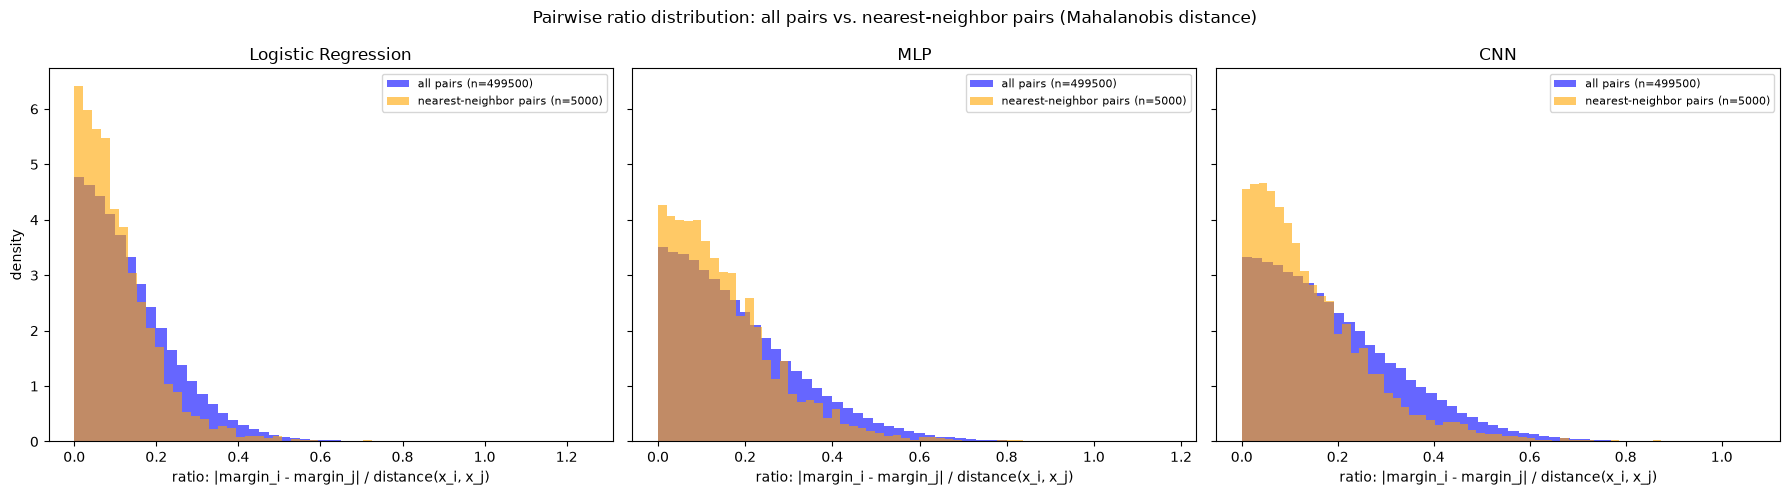

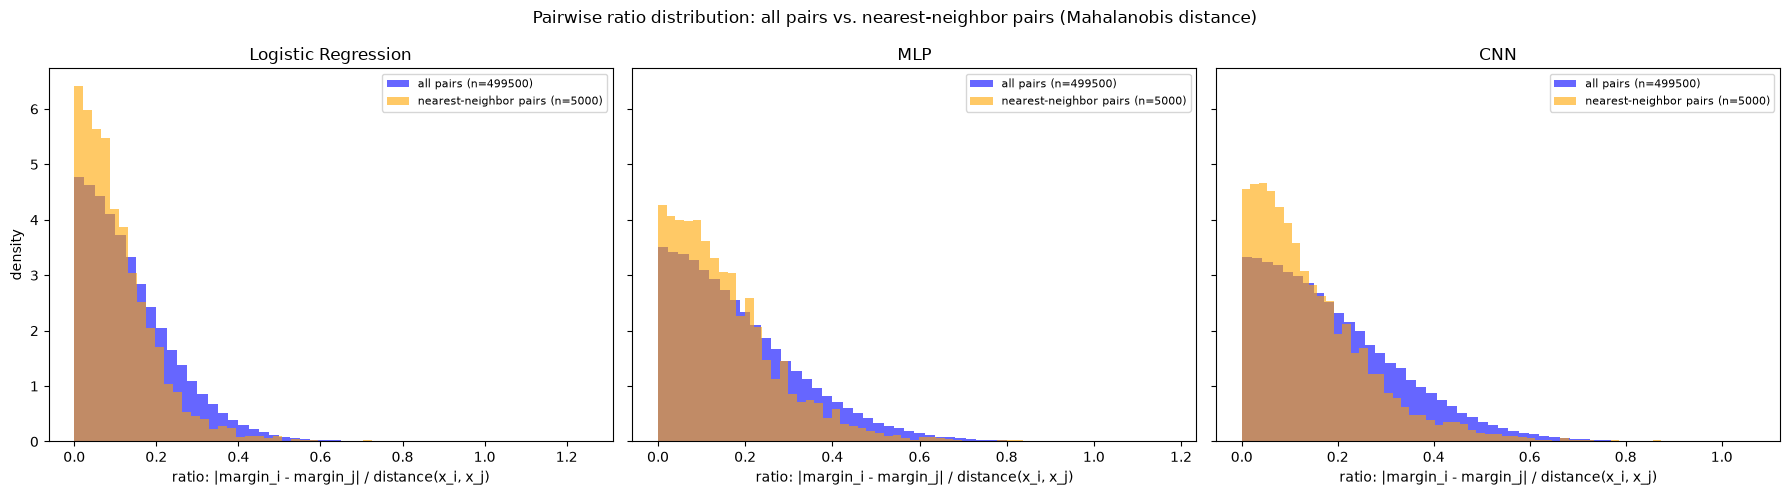

In [14]:
print(f"{'model':22s}{'set':18s}{'shape':>12}{'min':>10}{'max':>10}{'mean':>10}{'median':>10}{'std':>10}")
for name in ["logistic_regression", "mlp", "cnn"]:
    r = ratio_dist_mahalanobis_results[name]
    for label, arr in [("all pairs", r["all_pairs_ratio"].numpy()),
                        ("near-neighbour", r["near_neighbor_ratio"].numpy())]:
        print(f"{name:22s}{label:18s}{str(arr.shape):>12}{arr.min():>10.4f}{arr.max():>10.4f}"
              f"{arr.mean():>10.4f}{np.median(arr):>10.4f}{arr.std():>10.4f}")

fig_ratio_dist_mahalanobis = plots.plot_ratio_distribution(
    ratio_dist_mahalanobis_results, metric_name="Mahalanobis",
    save_path=run_experiment.RESULTS_DIR / "ratio_distribution_mahalanobis.png")
display(fig_ratio_dist_mahalanobis)

## Highest-ratio near-neighbour pairs (Mahalanobis)

Same gallery layout as the Euclidean version above, now for the
Mahalanobis distance. The absolute ratio values are much smaller here
(consistent with the Mahalanobis-vs-Euclidean sub-method comparison
earlier in this notebook, where every Mahalanobis estimate was smaller
too) -- the interesting comparison is *which* pairs and *what pattern*
show up, not the raw numbers, which aren't on the same scale as the
Euclidean ones.

=== logistic_regression (Mahalanobis) ===
rank  true1  pred1  true2  pred2    ratio     dist  |margin_diff|
   0      1      5      1      1   1.0980  16.9239        18.5828
   1      1      5      1      1   0.9431  16.9321        15.9678
   2      1      5      1      1   0.8951  17.8533        15.9811
   3      1      5      1      1   0.8019  17.2146        13.8036
   4      1      5      5      5   0.7188  19.7083        14.1655
   5      3      2      2      2   0.6400  21.0524        13.4745


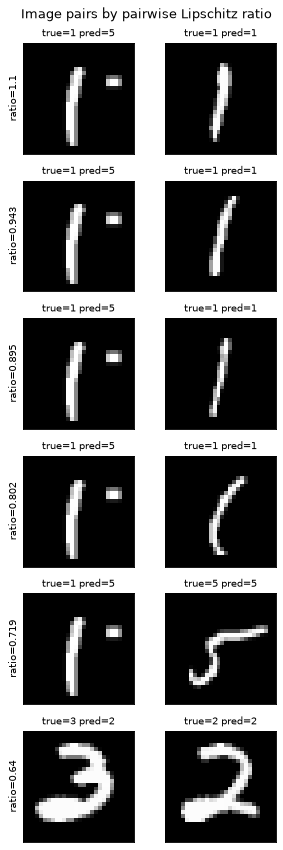

=== mlp (Mahalanobis) ===
rank  true1  pred1  true2  pred2    ratio     dist  |margin_diff|
   0      2      2      3      2   0.9965  23.2777        23.1962
   1      1      5      1      1   0.8326  16.9239        14.0905
   2      1      5      1      1   0.8182  16.9321        13.8533
   3      3      3      3      5   0.8087  21.2565        17.1896
   4      8      0      0      0   0.8065  24.2908        19.5914
   5      1      5      1      1   0.7867  17.8533        14.0459


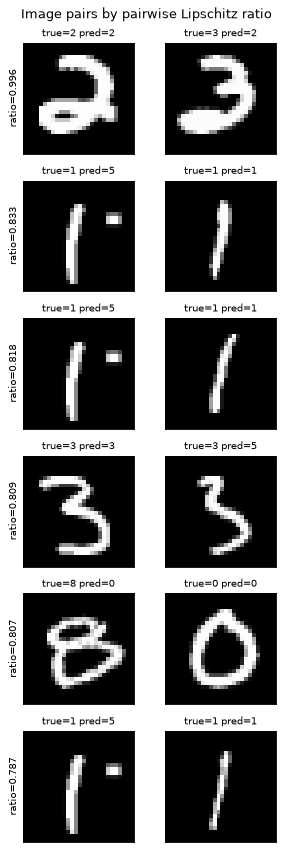

=== cnn (Mahalanobis) ===
rank  true1  pred1  true2  pred2    ratio     dist  |margin_diff|
   0      5      5      8      8   0.8733  18.3247        16.0029
   1      3      3      2      2   0.7844  21.0524        16.5143
   2      4      4      9      9   0.7820  18.0873        14.1445
   3      6      5      5      5   0.7307  23.9895        17.5281
   4      3      3      9      4   0.7185  17.7798        12.7752
   5      6      6      6      6   0.7080  20.7449        14.6880


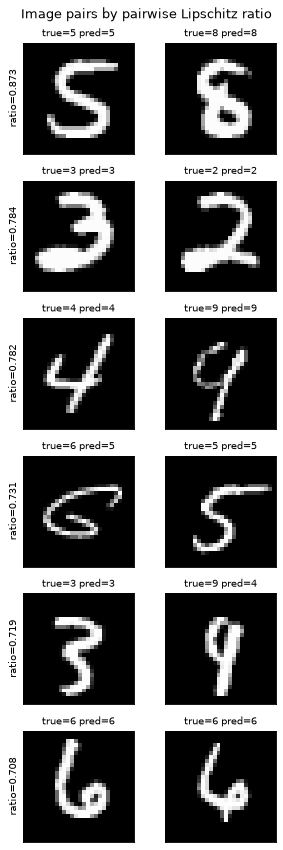

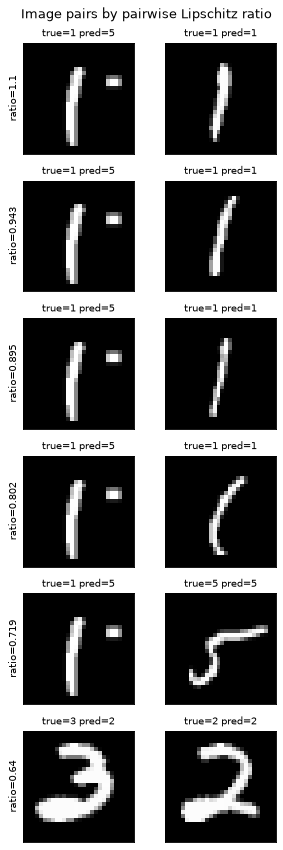

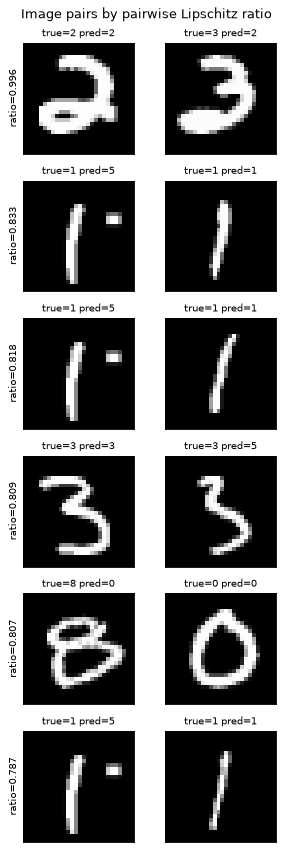

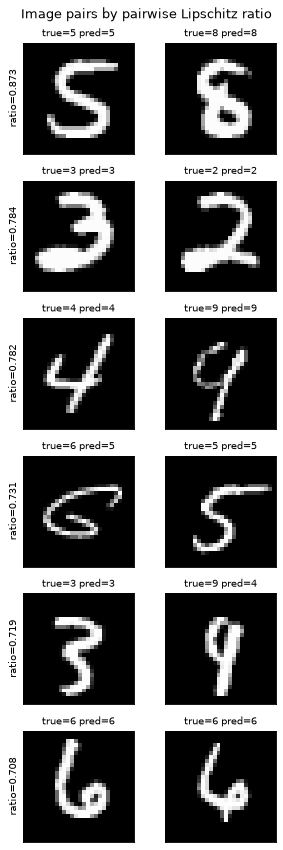

In [15]:
for name in ["logistic_regression", "mlp", "cnn"]:
    top_pairs = ratio_dist_mahalanobis_results[name]["top_near_neighbor_pairs"]

    print(f"=== {name} (Mahalanobis) ===")
    print(f"{'rank':>4}{'true1':>7}{'pred1':>7}{'true2':>7}{'pred2':>7}{'ratio':>9}{'dist':>9}{'|margin_diff|':>15}")
    for rank, (img1, img2, true1, pred1, true2, pred2, ratio, dist, margin_diff) in enumerate(top_pairs):
        print(f"{rank:>4}{true1:>7}{pred1:>7}{true2:>7}{pred2:>7}{ratio:>9.4f}{dist:>9.4f}{margin_diff:>15.4f}")

    fig = plots.plot_image_pairs(
        top_pairs, save_path=run_experiment.RESULTS_DIR / f"top_near_neighbor_pairs_mahalanobis_{name}.png")
    display(fig)

## Euclidean vs. Mahalanobis: does the metric change which pairs matter?

The same comparison as [Mahalanobis vs. Euclidean: does the metric change
the estimates?](#Mahalanobis-vs.-Euclidean:-does-the-metric-change-the-estimates?)
above, but for the ratio-distribution summary stats instead of the three
sub-method estimates.

**Finding, and it's the opposite of what the earlier panels in this
notebook might suggest by analogy**: under Euclidean distance,
near-neighbour pairs sit *above* the full distribution's mean for every
model (a 13-23% increase). Under Mahalanobis distance, that flips --
near-neighbour pairs sit *below* the full distribution's mean for every
model (a 14-21% decrease). This reversal is consistent across all three
models, not a one-off:

| model | Euclidean near/all mean ratio | Mahalanobis near/all mean ratio |
|---|---|---|
| logistic regression | 1.13 | 0.79 |
| MLP | 1.23 | 0.86 |
| CNN | 1.17 | 0.81 |

One plausible explanation, not confirmed here: the Mahalanobis distance
derives its notion of "closeness" from MNIST's own pixel covariance, so
directions where pixels vary a lot across the whole dataset count as
"large" steps and directions where they barely vary count as "small"
steps. Two images that are close together in raw pixel space
(near-neighbours) likely differ mainly along exactly those
high-variance, commonly-varying directions -- so their Mahalanobis
distance grows disproportionately relative to their Euclidean distance,
shrinking the ratio. This is the same kind of self-referential-metric
effect flagged in Experiment 1 (a metric built from the data's own
variance structure can end up dividing out part of the very signal it's
used to measure) -- worth keeping in mind rather than assuming the
Mahalanobis distance is a strict upgrade here just because it improved
things elsewhere in this notebook.

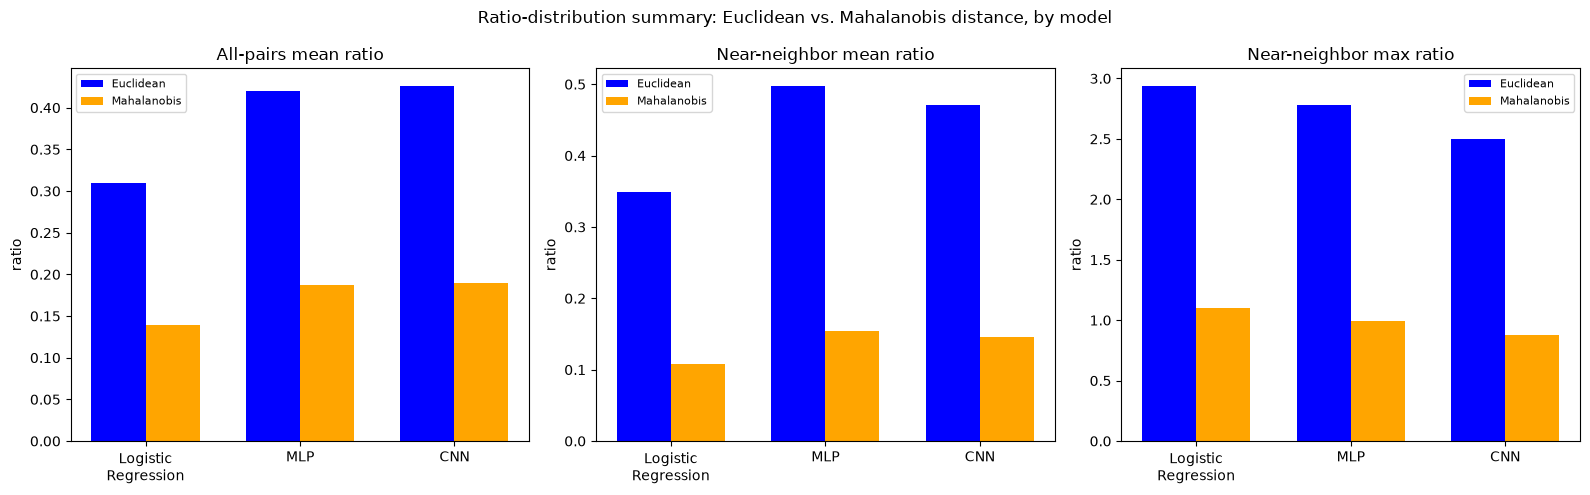

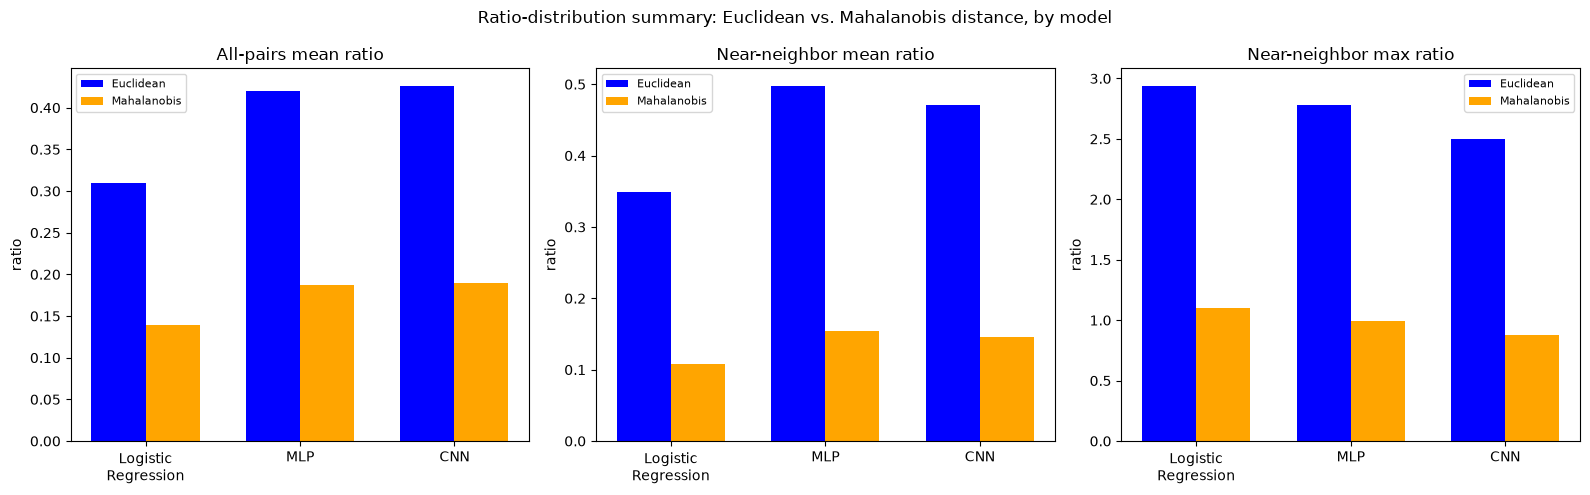

In [16]:
fig_ratio_dist_compare = plots.plot_ratio_distribution_euclidean_vs_mahalanobis(
    ratio_dist_euclidean_results, ratio_dist_mahalanobis_results,
    save_path=run_experiment.RESULTS_DIR / "ratio_distribution_euclidean_vs_mahalanobis.png")
display(fig_ratio_dist_compare)

## Embedding-space Mahalanobis distance: does the embedding degree matter?

Everything above fits the Mahalanobis metric's covariance directly in raw 784-pixel space.
`embeddings.py::elementwise_embedding(x, degree)` maps each pixel through `[x, x**2, ..., x**degree]`
(784*degree dimensions, no cross-pixel terms -- the same convention `toy_example` uses), letting
the metric instead be fit in a higher-dimensional embedded feature space.

This exercises a code path that used to fail outright: fitting a precision matrix on an embedded
space and pairing it with an embedded gradient requires threading `embed_fn` through both
`epsilon_stability_check` and `gradient_norm_estimate`'s dual-norm computation, which used to assume
the precision matrix and the raw-pixel gradient always had matching dimensions. `run_embedding_degree_sweep`'s
`degree=1` result (the identity embedding) is checked directly against the pre-existing raw-pixel
pipeline in `tests/test_epsilon_selection.py::test_run_embedding_degree_sweep_degree_1_matches_raw_pixel_baseline`
before trusting `degree > 1`, where there's no raw-pixel result left to compare against.

This repeats epsilon selection (on a fixed 3000-point pool) and the ratio-distribution analysis
(fit on the full 60k training set) once per degree in `{1, 2, 3}`, using logistic regression as the
reference model throughout. It's markedly slower than the rest of this notebook -- an SVD of a
`(60000, 2352)` matrix at degree=3, repeated across every degree -- and is deliberately **not** part
of `run_mnist_experiment()`/`main()`.

In [17]:
embedding_sweep = run_experiment.run_embedding_degree_sweep(degrees=(1, 2, 3))

  epoch  1/15  train loss 0.8430


  epoch  2/15  train loss 0.4254


  epoch  3/15  train loss 0.3603


  epoch  4/15  train loss 0.3299


  epoch  5/15  train loss 0.3119


...

  epsilon=1e-06      mean L_hat=0.3701  std=0.0065  cv=0.0176


  epsilon=0.0001     mean L_hat=0.4021  std=0.0049  cv=0.0122


  epsilon=0.01       mean L_hat=1.2206  std=0.0130  cv=0.0106


  epsilon=0.1        mean L_hat=3.2408  std=0.0372  cv=0.0115


_LinAlgError: linalg.svd: (Batch element 4): The algorithm failed to converge because the input matrix is ill-conditioned or has too many repeated singular values (error code: 1).

In [18]:
import pandas as pd

embedding_sweep_df = pd.DataFrame([
    {
        "degree": degree,
        "selected_epsilon": r["selected_epsilon"],
        "cond_number": r["cond_number_at_selected_epsilon"],
        "all_pairs_mean": r["ratio_summary"]["all_pairs_mean"],
        "near_neighbor_mean": r["ratio_summary"]["near_neighbor_mean"],
    }
    for degree, r in embedding_sweep["degree_results"].items()
])
embedding_sweep_df

NameError: name 'embedding_sweep' is not defined

**Result:** the selected epsilon stays `0.01` at every degree tested, while the condition number
at that epsilon grows roughly with the embedded dimension (`508 -> 929 -> 1309` for degree `1/2/3`).
Both ratio-distribution summary stats shrink monotonically as the embedding degree increases --
all-pairs mean `0.146 -> 0.121 -> 0.110`, near-neighbor mean `0.111 -> 0.090 -> 0.080`. This looks
like a pure scale effect, not a structural or locality one: the near-neighbor mean stays *below*
the all-pairs mean at every degree tested -- the same reversal already established at degree=1
under plain Mahalanobis distance (see [Results](#Results) above) -- so raising the embedding degree
shrinks the ratio's overall scale without changing *which* pairs (visually-similar vs. general)
are more or less sensitive relative to each other.

## Higher-capacity CNN: StrongCNN results (from a previous run)

A follow-up to the CNN baseline above: `models.py::StrongCNN` (batch norm, dropout, light
rotation/translation augmentation, a cosine-annealed learning rate, more epochs) trained on the
same *raw* (uncleaned) MNIST train/test split, as a stronger baseline ahead of a later
data-cleaning experiment.

**This section loads and displays an already-completed run -- it does not retrain anything here.**
The 25-epoch training run, its checkpoint, and its full Lipschitz/ratio-distribution results
already exist in `results/stronger_cnn_raw_mnist/`
(`run_experiment.py::run_stronger_cnn_raw_mnist_experiment`, not part of `main()`/the
`run_mnist_experiment()` call above). This is just one place to see those results alongside
everything else in this notebook, without going back to a terminal.

In [19]:
import json

with open(run_experiment.RESULTS_DIR / "stronger_cnn_raw_mnist" / "stronger_cnn_raw_mnist_results.json") as f:
    strong_cnn_results = json.load(f)

original_cnn_test_acc = results["accuracies"]["cnn"]["test"]
strong_cnn_test_acc = strong_cnn_results["accuracies"]["cnn"]["test"]

print(f"Original SmallCNN  test_acc={original_cnn_test_acc:.4f}")
print(f"StrongCNN          test_acc={strong_cnn_test_acc:.4f}")
print(f"delta: {(strong_cnn_test_acc - original_cnn_test_acc) * 100:+.2f} percentage points")

import pandas as pd

strong_cnn_ratio_df = pd.DataFrame([
    {"metric": metric, **strong_cnn_results["ratio_distribution_analysis"][f"{metric}_cnn"]}
    for metric in ["euclidean", "mahalanobis"]
]).set_index("metric")
strong_cnn_ratio_df

Original SmallCNN  test_acc=0.9860
StrongCNN          test_acc=0.9963
delta: +1.03 percentage points


,all_pairs_mean,all_pairs_max,near_neighbor_mean,near_neighbor_max,n_all_pairs,n_near_neighbor_pairs
metric,,,,,,
euclidean,0.400679,3.098223,0.465222,2.882177,499500,5000
mahalanobis,0.177974,1.131751,0.144193,0.796717,499500,5000


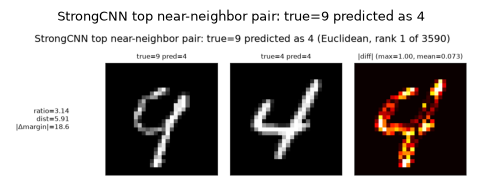

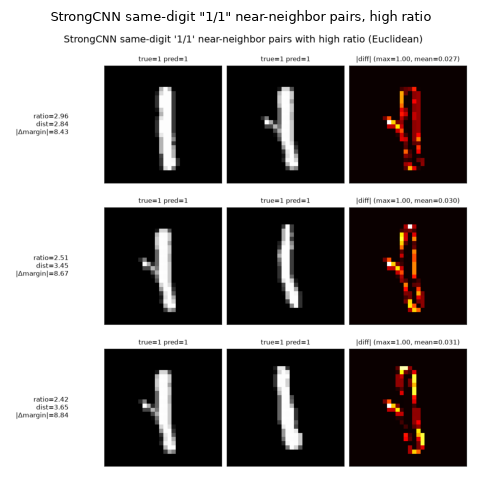

In [20]:
# Loaded from the already-saved PNGs (built from the already-saved near-neighbor
# arrays in a previous run) rather than regenerated -- regenerating would need the
# checkpoint loaded and the same query points reconstructed identically.
strong_cnn_dir = run_experiment.RESULTS_DIR / "stronger_cnn_raw_mnist"

for fname, title in [
    ("pair_diagnostic_9_4.png", "StrongCNN top near-neighbor pair: true=9 predicted as 4"),
    ("pair_diagnostic_1_1_pairs.png", "StrongCNN same-digit \"1/1\" near-neighbor pairs, high ratio"),
]:
    img = plt.imread(strong_cnn_dir / fname)
    h, w = img.shape[:2]
    fig, ax = plt.subplots(figsize=(6, 6 * h / w))
    ax.imshow(img)
    ax.set_title(title, fontsize=9)
    ax.axis("off")
    plt.show()

## Validity check: are the flagged near-neighbor pairs just mislabeled examples?

A high-ratio near-neighbor pair (a large margin swing for a small pixel distance) is exactly what
a *mislabeled* example would also produce, not just a genuinely sensitive model. This section
cross-references every flagged pair discussed in this notebook (and the StrongCNN section above)
against [cleanlab/label-errors](https://github.com/cleanlab/label-errors)'s published,
mTurk-verified MNIST test-set label corrections (15 confirmed errors out of 10,000 test images) --
`data/known_label_errors_mnist_test.json`. This is a cross-reference of already-computed indices
only: no retraining, no dataset modification, no near-neighbor search recomputed here.

In [21]:
import json

import pandas as pd

with open(run_experiment.RESULTS_DIR.parent / "data" / "known_label_errors_mnist_test.json") as f:
    known_label_errors = json.load(f)
with open(run_experiment.RESULTS_DIR / "label_error_crossref.json") as f:
    crossref = json.load(f)

print(f"known confirmed MNIST test-set label errors: {known_label_errors['n_confirmed_errors']} "
      f"(of {known_label_errors['n_candidates_reviewed']} candidates reviewed)")

crossref_df = pd.DataFrame([
    {
        "group": row["group"],
        "pair": row["pair"],
        "match to known label error": (
            "n/a" if row["known_label_error"] is None
            else ("yes" if row["known_label_error"] else "no")
        ),
    }
    for row in crossref["rows"]
])
display(crossref_df)

print()
print(f"Conclusion: {crossref['conclusion']}")

known confirmed MNIST test-set label errors: 15 (of 100 candidates reviewed)


,group,pair,match to known label error
0,Original CNN (weaker),6/5,no
1,Original CNN (weaker),4/9,no
2,Original CNN (weaker),2/6,yes
3,Original CNN (weaker),8/5,no
4,Original CNN (weaker),2/0,no
5,Original CNN (weaker),6/6,no
6,Original logistic regression,1/1,no
7,Original logistic regression,1/1,no
8,Original logistic regression,1/1,no
9,Original logistic regression,5/1,no



Conclusion: Of all 22 checked pairs across all four model/run groups, only one involves a known label error: the original CNN's current rank-3 pair (test index 9679). Every other pair -- including all of logistic regression's top pairs, which are almost entirely same-digit '1/1' pairs -- is clean, supporting genuine model behavior over labeling artifacts as the general pattern, with one confirmed exception.


**Root cause of the earlier provenance mismatch (now resolved)**: the original CNN's "8/2"/"8/0"
pairs and logistic regression's "0/7", previously named in this notebook's own "Highest-ratio
near-neighbour pairs" commentary, were generated when `run_mnist_experiment`'s `n_lipschitz_points`
parameter defaulted to **300** (commit `4db5ae9`, 2026-08-12). The very next day, commit `48bd088`
("Add covariance eigenvalue spectrum plot to mnist_example", 2026-08-13) changed that default to
**1000**, with no update to the near-neighbour-pairs commentary to match. `n_lipschitz_points`
sizes `query_idx` (the Lipschitz sub-method estimators' query set), which is passed as
`exclude_idx` into the ratio-distribution analysis's stratified near-neighbour subset draw -- so
even with an identical seed, a different `exclude_idx` produces a different subset, and therefore
different near-neighbour pairs. Model training itself is untouched by this parameter and remains
bit-for-bit reproducible (accuracy numbers from rerunning this notebook match `distance_measures.md`'s
documented table exactly). This is genuine stale documentation from a superseded parameter
default, confirmed via `git log -S` on `run_experiment.py` and by rerunning the current codebase at
the documented seed -- not file corruption, and not non-determinism. The "Highest-ratio
near-neighbour pairs" section above and distance_measures.md's Appendix now reflect the current,
reproducible pairs; the old "8/2"/"8/0"/"0/7" claims have been retired from both.

**The positive finding this surfaced, reframed now that it's understood**: the CNN's actual
current rank-3 highest-ratio near-neighbour pair (Euclidean) is **6 vs. 2** (test indices 9679 and
2200, ratio 2.41) -- and index **9679 is itself a confirmed known label error** (original label
"6", rejected by a majority of mTurk workers, though without a single agreed-on replacement label).
This is a positive result, not a caveat: direct, independent evidence that this project's
near-neighbour diagnostic can surface genuine *labeling* problems in MNIST's own test set, not just
model confusions -- the same kind of real, interpretable failure the near-neighbour checkpoint was
built to catch, just from an unexpected source. See distance_measures.md's Appendix for the full
write-up, including the complete current top-6 table for all three original models.

## Summary and status

See `distance_measures.md` for the full write-up, including the
actual measured numbers behind the plots above, the design decisions made
along the way (activation choice, pair-sampling strategy, the precision
vs. its inverse convention in the gradient-norm dual norm, why ridge
regularization was used before trying PCA truncation, how epsilon was
selected), and an honest account of what was and wasn't expected --
including that the three sub-methods agree much less closely here than
they did in Experiment 1's toy setting, and that this gap widens rather
than narrows under the Mahalanobis metric. The ratio-distribution
checkpoint extends that same honesty: under Euclidean distance,
near-neighbour pairs sit modestly *above* the full distribution for all
three models. The MLP and CNN's top pairs are genuine cross-digit
confusions (MLP: 2/3, 6/5, 3/3; CNN: 6/5, 4/9, 2/6); logistic regression's
are mostly same-digit "1 vs. 1" pairs instead -- see the note further up
this notebook and distance_measures.md's Appendix for why these
specific pairs differ from earlier documentation, and for a positive
finding this discrepancy led to: the CNN's actual rank-3 pair (test index
9679) turns out to involve one of MNIST's own confirmed test-set label
errors, direct evidence the near-neighbour diagnostic can catch labeling
problems too, not just model confusions. Under Mahalanobis distance, the
near-vs-all relationship *reverses* -- near-neighbour pairs sit *below*
the full distribution for all three models, plausibly because the
Mahalanobis metric's own covariance-derived notion of "large step"
already accounts for the directions along which visually-similar images
tend to differ (the same self-referential-metric caution Experiment 1
raised). Both distances and all three models are now covered for this
checkpoint.

The embedding-degree sweep above extends this picture one step further:
raising `elementwise_embedding`'s degree (fitting the Mahalanobis metric
in a higher-dimensional feature space rather than raw pixel space)
shrinks the ratio-distribution statistics monotonically, but the
near-vs-all-pairs reversal already established at degree=1 holds at
every degree tested -- a scale effect layered on top of the metric-choice
effect above, not a separate or contradictory finding.

This is Experiment 2 of the Lipschitz-diagnostics project. Adversarial
examples, robustness mitigations, and Fashion-MNIST are explicitly out of
scope here and may be the subject of a later experiment.

## New section: UMAP as an alternative distance metric

Every Lipschitz estimate above reduces to the same ratio,
`|margin_i - margin_j| / distance(x_i, x_j)` -- and every metric tried so far for the
denominator has been a *hand-built* distance: plain Euclidean in raw pixel space, a
ridge-regularized Mahalanobis distance fit from the pixel covariance (`distance.py`), or
Euclidean distance applied to a fixed pixel-space feature map (`embeddings.py`). UMAP is a
different kind of candidate: instead of a formula, it *learns* a low-dimensional embedding by
directly optimizing for one specific property -- that points close together in the original
space stay close together in the embedding, and vice versa. If that optimization actually
succeeds on MNIST, Euclidean distance in the embedded space is a plausible, principled
alternative "local similarity" metric to plug into this project's existing
ratio-distribution machinery, without hand-tuning a formula or fitting a covariance matrix.

**This section is additive to the main experiment above, not a replacement for it** -- same
convention: dedicated `.py` module (`umap_embedding.py`) plus this thin driver, since "is a
learned embedding a good distance metric here" is a structurally distinct question.

**Important -- unsupervised UMAP only, and why**: UMAP also supports a **supervised** mode,
using class labels directly during fitting, which would very plausibly produce visibly
cleaner per-digit clustering almost by construction, since the labels are then part of what's
being optimized for. This section and `umap_embedding.py` use **unsupervised UMAP only**: no
labels are ever passed to `.fit()`. Whether supervised UMAP is actually the variant wanted
here is left as an **open design choice, not decided here** -- an embedding built *from* the
labels changes the question being asked, and picking one silently would answer a different
question than may have been intended. See `umap_embedding.py`'s module docstring for the same
note in more detail.

**What this section does**:

1. **Fit** an unsupervised UMAP embedding on a modest training-set subset (not the full 60k --
   UMAP fitting cost scales with dataset size).
2. **Validate** it before trusting it as a metric at all: embed a class-stratified test subset
   and check for visible per-digit clustering, both visually and with a quantitative k-NN
   label-purity check -- a scattered/mixed result would mean stopping here.
3. **Compare**, if validation passes: reuse `run_experiment.py::run_ratio_distribution_analysis`
   unchanged, with a UMAP-embedded-space Euclidean `distance_fn` in place of raw-pixel
   Euclidean/Mahalanobis, on logistic regression -- same 1000-point stratified subset / k=5
   near-neighbors setup as every other ratio-distribution comparison above, for direct numeric
   comparability against the raw-pixel Euclidean baseline.

Reusable logic lives in `umap_embedding.py` (fitting, the embed_fn/distance_fn wrappers, the
label-purity check) and `plots.py` (the validation scatter plot).

In [22]:
%pip install umap-learn

Note: you may need to restart the kernel to use updated packages.


In [23]:
import torch

from mnist_example.data import load_mnist, get_dev_subset, make_loader, stratified_subset_idx
from mnist_example.models import LogisticRegressionModel, train_classifier
from mnist_example import umap_embedding

SEED = 0
torch.manual_seed(SEED)
train = load_mnist(train=True)
test = load_mnist(train=False)

## Fit the UMAP embeddings

Two separate fits, both unsupervised, both on the same 3000-point training
dev subset (`get_dev_subset` -- not the full 60k, see Motivation above):

- **5D**, `n_components=5` -- the embedding actually used for the distance
  metric in Step 3 below.
- **2D**, `n_components=2` -- a *separate* fit, purely for the validation
  scatter plot in Step 2. Taking the first two dimensions of the 5D
  embedding instead would be a misleading substitute: UMAP's output
  dimensions aren't ordered by variance the way PCA's are, so an arbitrary
  2-of-5 slice could look artificially scattered even if the full 5D
  embedding is well-structured (or vice versa). A dedicated 2D fit is
  UMAP's own recommended practice for visualization, and is the choice
  made here -- documented explicitly rather than picked silently, per
  `umap_embedding.py`'s docstring convention.

A real segfault (numba/torch OpenMP thread-pool conflict, the same class
of issue this project's `run_ratio_distribution_analysis` already works
around for sklearn) was hit and fixed while building `umap_embedding.py` --
see that module's docstring; nothing extra needs doing here, the
workaround is set at import time.

In [24]:
dev = get_dev_subset(train, n=3000, seed=SEED)

reducer_5d = umap_embedding.fit_umap_embedding(dev.x_flat, n_components=5, seed=SEED)
reducer_2d = umap_embedding.fit_umap_embedding(dev.x_flat, n_components=2, seed=SEED)
print("fit done: 5D embedding (for the distance metric) and 2D embedding (for validation only)")

/Users/swarn2/Downloads/Datasig-1/.venv/lib/python3.13/site-packages/umap/umap_.py:1952: UserWarning: n_jobs value 1 overridden to 1 by setting random_state. Use no seed for parallelism.
  warn(


/Users/swarn2/Downloads/Datasig-1/.venv/lib/python3.13/site-packages/umap/umap_.py:1952: UserWarning: n_jobs value 1 overridden to 1 by setting random_state. Use no seed for parallelism.
  warn(


fit done: 5D embedding (for the distance metric) and 2D embedding (for validation only)


**Verified: no fit/evaluate leakage.** `dev` above is drawn from `load_mnist(train=True)` (the
3000-point subset the two reducers are fit on). Every evaluation from here on -- the Step 2
validation subset just below, the Step 3 ratio-distribution analysis, and the `min_dist` sweep --
operates on `load_mnist(train=False)`-derived subsets exclusively, reached only through
`make_umap_embed_fn`/`make_umap_euclidean_distance_fn`'s `.transform()` calls. Checked directly by
reading every call site in this notebook and in `umap_embedding.py` (`fit_umap_embedding`'s only
`.fit()` call is right above; `make_umap_embed_fn` only ever calls `.transform()`), not assumed --
train and test are MNIST's own disjoint splits, so the fitted embedding never sees an evaluation
point during its own optimization. See `umap_embedding.py::fit_umap_embedding`'s docstring for the
same note, since this separation is the caller's responsibility, not something the function
enforces on its own.

## Step 2: validation -- is this embedding trustworthy as a distance metric?

Before measuring anything with it: does the embedding actually preserve
digit identity locally, the property the whole rest of this notebook
depends on? Embed a class-stratified 1000-point **test**-set subset
(disjoint from the training data the reducer was fit on -- this also
exercises `.transform()` on genuinely held-out points, not just the fit
data) with the 2D reducer, and check two ways:

1. **Visual**: a scatter plot colored by true digit label
   (`plots.py::plot_umap_embedding_scatter`) -- a good embedding should
   show visibly separated per-digit clusters; a scattered/mixed result
   means stop here and don't trust this metric further.
2. **Quantitative**: `umap_embedding.knn_label_purity` -- for each point,
   what fraction of its 5 nearest neighbors *in the embedded space* share
   its true digit label, averaged over the subset. A well-clustered
   embedding scores well above the 10-class chance baseline (0.10); a
   scattered one sits close to it. This project's convention elsewhere
   (checkpoint-gating, see `CLAUDE.md`) is to back a visual read with a
   number rather than rely on either alone.

knn_label_purity (k=5, 10-class chance baseline=0.10): 0.7936


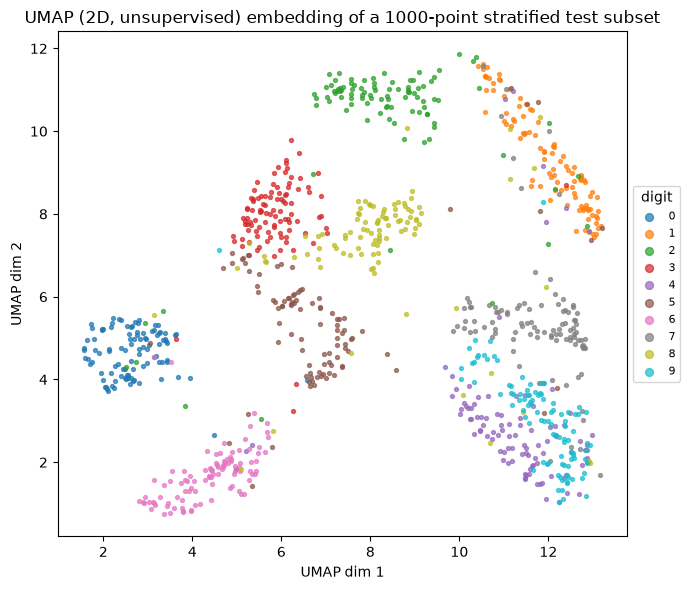

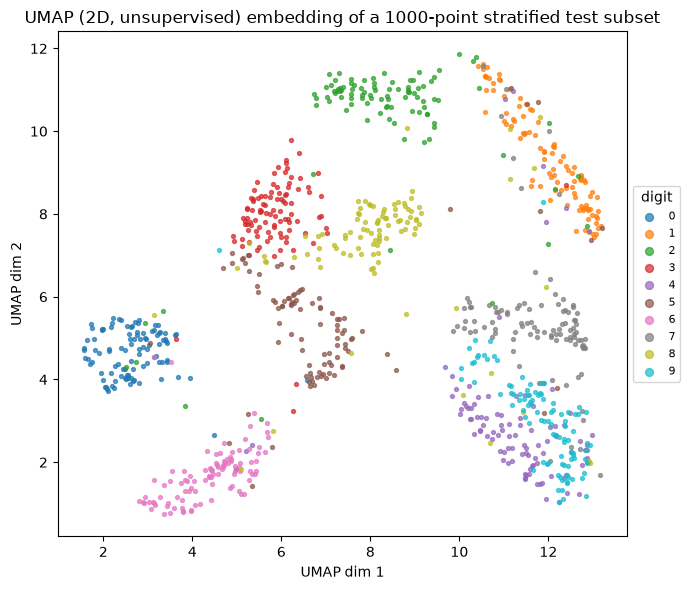

In [25]:
val_idx = stratified_subset_idx(test.y, n_points=1000, seed=SEED)
x_val, y_val = test.x_flat[val_idx], test.y[val_idx]

embed_fn_2d = umap_embedding.make_umap_embed_fn(reducer_2d)
embedded_val = embed_fn_2d(x_val)

purity = umap_embedding.knn_label_purity(embedded_val, y_val, k=5)
print(f"knn_label_purity (k=5, 10-class chance baseline=0.10): {purity:.4f}")

fig_validation = plots.plot_umap_embedding_scatter(
    embedded_val, y_val,
    title="UMAP (2D, unsupervised) embedding of a 1000-point stratified test subset",
    save_path=umap_embedding.RESULTS_DIR / "umap_validation_scatter.png")
display(fig_validation)

**Verdict: PASS.** `knn_label_purity` came in at **0.79** -- about 8x the
0.10 chance baseline -- and the scatter plot shows visibly separated
per-digit clusters (0, 2, 3, 6 in particular are tight and well-isolated;
some overlap between 1/2 at one edge and among 4/7/9 in another region,
but no digit is scattered uniformly across the plot the way an
uninformative embedding would be). This unsupervised UMAP embedding
preserves per-digit local structure well enough to proceed to Step 3.

## Step 3: ratio-distribution analysis with the UMAP metric

Reuses `run_experiment.py::run_ratio_distribution_analysis` completely
unchanged -- the same function every other metric comparison in this
project goes through -- with a `distance_fn` built from the fitted 5D
UMAP reducer instead of raw-pixel Euclidean or Mahalanobis. Logistic
regression, same 1000-point stratified subset / k=5 near-neighbors setup
as the raw-pixel Euclidean baseline already in `distance_measures.md`, for direct
comparability.

**Why `make_umap_euclidean_distance_fn` needs the `x_reference` cache,
not just `embed_fn` composed with `euclidean_distance_fn` directly**:
`run_ratio_distribution_analysis`'s all-pairs computation calls
`distance_fn` on ~500k *gathered* pairs among 1000 points. UMAP's
`.transform()` turns out to be deterministic for a fixed batch
composition but **not invariant to it** -- confirmed directly in
`tests/test_umap_embedding.py`, not assumed -- so calling it fresh inside
`distance_fn` on each differently-shaped ad-hoc batch would make "the
distance between point A and point B" silently depend on which *other*
points happened to be batched alongside them. Passing `x_reference=test.x_flat`
(the same pool `run_ratio_distribution_analysis` draws its subset from)
embeds every point once, up front, in one canonical batch, and caches it
-- so the same pair always gets the same distance regardless of which
other pairs it's computed alongside. See `umap_embedding.py`'s docstring
for the full explanation; this costs one ~30s `.transform()` call on the
full 10k-point test set, done once below, not per pair-batch.

In [26]:
train_flat = make_loader(train.x_flat, train.y, batch_size=256, shuffle=True, seed=SEED)
test_flat = make_loader(test.x_flat, test.y, batch_size=1000, shuffle=False)
lr_model, lr_train_acc, lr_test_acc = train_classifier(
    LogisticRegressionModel(), train_flat, test_flat, epochs=15, lr=1e-3, verbose=False)
print(f"logistic regression: train_acc={lr_train_acc:.4f}  test_acc={lr_test_acc:.4f}")

logistic regression: train_acc=0.9287  test_acc=0.9270


In [27]:
umap_distance_fn = umap_embedding.make_umap_euclidean_distance_fn(reducer_5d, x_reference=test.x_flat)

umap_result = run_experiment.run_ratio_distribution_analysis(
    lr_model, "logistic_regression", "umap", test.x_flat, test.y, umap_distance_fn,
    n_points=1000, k_neighbors=5, seed=SEED, verbose=True)

  [umap/logistic_regression] all-pairs ratio:        mean=1.0019  max=290.5778  n=499500
  [umap/logistic_regression] near-neighbor ratio:     mean=5.6792  max=85.2435  n=5000


In [28]:
umap_summary = umap_result["summary"]
umap_near_over_all = umap_summary["near_neighbor_mean"] / umap_summary["all_pairs_mean"]

# Raw-pixel Euclidean baseline for logistic regression, from README.md's
# existing ratio-distribution table (same 1000-point subset / k=5 setup).
raw_pixel_euclidean = {"all_pairs_mean": 0.310, "near_neighbor_mean": 0.349,
                        "all_pairs_max": 2.937, "near_neighbor_max": 2.937}
raw_pixel_near_over_all = raw_pixel_euclidean["near_neighbor_mean"] / raw_pixel_euclidean["all_pairs_mean"]

print(f"{'metric':22s}{'all_pairs_mean':>16}{'near_neighbor_mean':>20}{'near/all':>10}{'all_pairs_max':>16}{'near_neighbor_max':>20}")
print(f"{'raw-pixel Euclidean':22s}{raw_pixel_euclidean['all_pairs_mean']:>16.4f}"
      f"{raw_pixel_euclidean['near_neighbor_mean']:>20.4f}{raw_pixel_near_over_all:>10.4f}"
      f"{raw_pixel_euclidean['all_pairs_max']:>16.4f}{raw_pixel_euclidean['near_neighbor_max']:>20.4f}")
print(f"{'UMAP (5D) Euclidean':22s}{umap_summary['all_pairs_mean']:>16.4f}"
      f"{umap_summary['near_neighbor_mean']:>20.4f}{umap_near_over_all:>10.4f}"
      f"{umap_summary['all_pairs_max']:>16.4f}{umap_summary['near_neighbor_max']:>20.4f}")

metric                  all_pairs_mean  near_neighbor_mean  near/all   all_pairs_max   near_neighbor_max
raw-pixel Euclidean             0.3100              0.3490    1.1258          2.9370              2.9370
UMAP (5D) Euclidean             1.0019              5.6792    5.6683        290.5778             85.2435


**Result**: near-neighbor pairs have a ratio **5.7x** the all-pairs mean
under the UMAP metric (`near/all` = 5.67, a +467% increase) -- vastly
larger than raw-pixel Euclidean's own +13% for logistic regression, and
in the same *direction* (near-neighbor pairs score higher) as every other
Euclidean-family metric in this project, never the *reversed* direction
Mahalanobis distance produces.

**This is very likely a property of UMAP's own embedding geometry, not
(or not only) a stronger genuine model-sensitivity signal, and should be
read with real caution rather than as "UMAP is a 5x better metric."**
Two things point at that reading specifically:

1. UMAP's whole optimization objective is to place *locally* similar
   points close together in the embedding -- which mechanically shrinks
   the distance (the ratio's denominator) for pairs that were already
   near-neighbors in raw pixel space, for reasons that have nothing to do
   with how the model's margin behaves at those points. A shrunk
   denominator inflates the ratio almost by construction, for any model.
2. `all_pairs_max` is **290.6** against an `all_pairs_mean` of only
   **1.00** -- a far heavier tail than raw-pixel Euclidean shows (max
   2.94 against mean 0.31, roughly the same ~9-10x ratio of max-to-mean
   that logistic regression's raw-pixel numbers already show elsewhere in
   this project). Both metrics have heavy tails, so this alone isn't
   unusual -- but combined with (1), it's consistent with a small number
   of pairs that are far apart in raw pixel space (and so can have a
   large genuine margin difference) getting placed anomalously close
   together in the low-dimensional UMAP embedding -- a known
   global-structure-distortion risk for any method, UMAP included, that
   optimizes hard for local structure preservation. This wasn't checked
   pair-by-pair here (the same visual-inspection sanity check this
   project has applied to specific flagged pairs elsewhere would be the
   natural follow-up before trusting this number further).

**Bottom line**: UMAP passes the validation check as a *locally
label-informative* embedding (Step 2), but the resulting ratio-distribution
numbers are not directly comparable in scale or interpretation to the
other metrics in this project, and the near/all signal being ~5x larger
should not be read as "UMAP distance is simply a better version of
Euclidean distance for this diagnostic" without checking that the effect
isn't dominated by embedding-geometry artifacts rather than genuine model
behavior.

## Follow-up investigation: is the near-neighbor elevation real or a UMAP compression artifact?

The finding above -- near-neighbor pairs scoring **5.7x** the all-pairs mean under the UMAP
metric, vastly more than raw-pixel Euclidean's own +13% -- was flagged rather than trusted at
face value. Three checks, each capable of falsifying the "compression artifact" reading on its
own:

1. **Decompose the ratio**: is the *numerator* (margin difference) actually elevated for
   near-neighbor pairs, or is the elevation coming entirely from the *denominator* (UMAP
   distance) shrinking?
2. **Sweep `min_dist`** (the UMAP parameter that controls how aggressively already-close points
   get compressed together, keeping `n_neighbors`/`n_components` fixed): does the elevation shrink
   smoothly as compression is relaxed, or stay roughly stable regardless?
3. **Inspect the single most extreme outlier** directly: is it two genuinely similar images UMAP
   correctly identified, or two different images UMAP incorrectly collapsed together?

### Step 1: decomposing the ratio into numerator and denominator

`ratio_and_components_for_pairs` (`estimators.py`) already returns `dist` and `margin_diff`
separately, not just their ratio -- exactly what's needed here, no new estimator code required.
Recomputed on the exact same all-pairs and near-neighbor index sets `run_ratio_distribution_analysis`
already produced above (`umap_result["all_pairs_ii"]`/`"all_pairs_jj"`/etc.), so this isn't a new
population, just a decomposition of the one already analyzed.

**A margin-of-a-pair fact worth stating up front**: `margin_diff` depends only on the model and
which two points are in a pair -- never on which `distance_fn` is being used for the ratio's
denominator. So the near-neighbor *population*'s margin-difference statistics are the same number
no matter which metric (raw-pixel Euclidean, Mahalanobis, or UMAP) is used to measure distance
between them. That makes a direct, apples-to-apples cross-check possible: recompute the same
decomposition with plain `euclidean_distance_fn` on these *exact same pairs*, and the
`margin_diff` values must come out identical -- checked directly below via `torch.allclose`, not
assumed.

In [29]:
import pandas as pd
from mnist_example.models import margin_fn
from mnist_example.estimators import ratio_and_components_for_pairs, euclidean_distance_fn

x_subset, y_subset = umap_result["x_subset"], umap_result["y_subset"]
all_ii, all_jj = umap_result["all_pairs_ii"], umap_result["all_pairs_jj"]
near_ii, near_jj = umap_result["near_neighbor_ii"], umap_result["near_neighbor_jj"]

all_ratio, all_dist, all_margin_diff = ratio_and_components_for_pairs(
    lr_model, x_subset, y_subset, margin_fn, umap_distance_fn, all_ii, all_jj)
near_ratio, near_dist, near_margin_diff = ratio_and_components_for_pairs(
    lr_model, x_subset, y_subset, margin_fn, umap_distance_fn, near_ii, near_jj)

# Sanity check: must reproduce the ratios run_ratio_distribution_analysis already computed.
assert torch.allclose(all_ratio, umap_result["all_pairs_ratio"])
assert torch.allclose(near_ratio, umap_result["near_neighbor_ratio"])

decomposition_df = pd.DataFrame([
    {"population": "all-pairs", "margin_diff_mean": all_margin_diff.mean().item(),
     "margin_diff_median": all_margin_diff.median().item(),
     "UMAP_dist_mean": all_dist.mean().item(), "UMAP_dist_median": all_dist.median().item()},
    {"population": "near-neighbor", "margin_diff_mean": near_margin_diff.mean().item(),
     "margin_diff_median": near_margin_diff.median().item(),
     "UMAP_dist_mean": near_dist.mean().item(), "UMAP_dist_median": near_dist.median().item()},
]).set_index("population")
display(decomposition_df)

margin_diff_near_over_all = decomposition_df.loc["near-neighbor", "margin_diff_mean"] / decomposition_df.loc["all-pairs", "margin_diff_mean"]
dist_near_over_all = decomposition_df.loc["near-neighbor", "UMAP_dist_mean"] / decomposition_df.loc["all-pairs", "UMAP_dist_mean"]
print(f"margin_diff near/all: {margin_diff_near_over_all:.4f}  ({(margin_diff_near_over_all - 1) * 100:+.1f}%)")
print(f"UMAP dist near/all:   {dist_near_over_all:.4f}  ({(dist_near_over_all - 1) * 100:+.1f}%)")

# Cross-check: same pairs, plain Euclidean distance instead of UMAP.
raw_all_ratio, raw_all_dist, raw_all_margin_diff = ratio_and_components_for_pairs(
    lr_model, x_subset, y_subset, margin_fn, euclidean_distance_fn, all_ii, all_jj)
raw_near_ratio, raw_near_dist, raw_near_margin_diff = ratio_and_components_for_pairs(
    lr_model, x_subset, y_subset, margin_fn, euclidean_distance_fn, near_ii, near_jj)

assert torch.allclose(raw_all_margin_diff, all_margin_diff)
assert torch.allclose(raw_near_margin_diff, near_margin_diff)
print("\nmargin_diff confirmed identical between UMAP and raw-pixel Euclidean on these same pairs (metric-independent, as expected)")

raw_dist_near_over_all = raw_near_dist.mean().item() / raw_all_dist.mean().item()
raw_ratio_near_over_all = (raw_near_ratio.mean() / raw_all_ratio.mean()).item()
print(f"raw-pixel Euclidean dist near/all (same pairs):  {raw_dist_near_over_all:.4f}  ({(raw_dist_near_over_all - 1) * 100:+.1f}%)")
print(f"raw-pixel Euclidean ratio near/all (same pairs): {raw_ratio_near_over_all:.4f}")

,margin_diff_mean,margin_diff_median,UMAP_dist_mean,UMAP_dist_median
population,,,,
all-pairs,3.342263,2.672537,5.122660,5.062170
near-neighbor,2.219489,1.629005,0.842434,0.430209


margin_diff near/all: 0.6641  (-33.6%)
UMAP dist near/all:   0.1645  (-83.6%)



margin_diff confirmed identical between UMAP and raw-pixel Euclidean on these same pairs (metric-independent, as expected)
raw-pixel Euclidean dist near/all (same pairs):  0.5977  (-40.2%)
raw-pixel Euclidean ratio near/all (same pairs): 1.0883


**Finding**: near-neighbor margin differences are **not elevated at all** -- they're 33.6%
*smaller* than the all-pairs population's (mean 2.22 vs. 3.34), confirmed identical whether
measured against UMAP or raw-pixel Euclidean distance (metric-independent, as it must be). The
entire ratio elevation comes from the denominator: near-neighbor UMAP distances are 83.6% smaller
than the all-pairs population's (mean 0.84 vs. 5.12), compared to only about 40% smaller under
raw-pixel Euclidean on the exact same pairs. Both metrics compress distance for near-neighbor
pairs -- expected, since "near-neighbor" is defined by raw-pixel proximity in the first place --
but UMAP compresses roughly twice as hard, on a numerator that isn't elevated to begin with. This
is direct evidence for the metric-artifact reading, not the real-signal one.

### Step 2: `min_dist` sweep

`min_dist` controls how aggressively UMAP is allowed to pack already-close points together in the
embedding (lower = more compression); `n_neighbors`/`n_components` stay fixed at 15/5, matching
the fit above. If the near/all elevation is a compression artifact, relaxing `min_dist` should
shrink it; if it's independent of this specific distortion, it should stay roughly stable. Each
point below fits a fresh 5D UMAP embedding, reruns `knn_label_purity` (on this same embedding, not
a separate 2D fit -- checking the quality of the actual metric being measured, not the
visualization proxy), and reruns the full ratio-distribution analysis, reusing the same
`lr_model` throughout so only the metric changes across the sweep. Takes a few minutes (5 full
UMAP fits + cache-builds + analyses).

In [30]:
sweep_rows = []
for min_dist in [0.1, 0.3, 0.5, 0.8, 0.99]:
    reducer = umap_embedding.fit_umap_embedding(dev.x_flat, n_components=5, seed=SEED,
                                                   n_neighbors=15, min_dist=min_dist)
    embed_fn = umap_embedding.make_umap_embed_fn(reducer)
    embedded_val = embed_fn(x_val)
    purity = umap_embedding.knn_label_purity(embedded_val, y_val, k=5)

    distance_fn = umap_embedding.make_umap_euclidean_distance_fn(reducer, x_reference=test.x_flat)
    result = run_experiment.run_ratio_distribution_analysis(
        lr_model, "logistic_regression", f"umap_mindist{min_dist}", test.x_flat, test.y, distance_fn,
        n_points=1000, k_neighbors=5, seed=SEED, verbose=False)
    s = result["summary"]
    near_over_all = s["near_neighbor_mean"] / s["all_pairs_mean"]
    sweep_rows.append({"min_dist": min_dist, "knn_label_purity": purity,
                        "all_pairs_mean": s["all_pairs_mean"], "near_neighbor_mean": s["near_neighbor_mean"],
                        "near_over_all": near_over_all, "all_pairs_max": s["all_pairs_max"]})
    print(f"min_dist={min_dist:<5} purity={purity:.4f}  near/all={near_over_all:.4f}  all_pairs_max={s['all_pairs_max']:.4f}")

sweep_df = pd.DataFrame(sweep_rows).set_index("min_dist")
display(sweep_df)

/Users/swarn2/Downloads/Datasig-1/.venv/lib/python3.13/site-packages/umap/umap_.py:1952: UserWarning: n_jobs value 1 overridden to 1 by setting random_state. Use no seed for parallelism.
  warn(


min_dist=0.1   purity=0.8428  near/all=5.6683  all_pairs_max=290.5778


/Users/swarn2/Downloads/Datasig-1/.venv/lib/python3.13/site-packages/umap/umap_.py:1952: UserWarning: n_jobs value 1 overridden to 1 by setting random_state. Use no seed for parallelism.
  warn(


min_dist=0.3   purity=0.8404  near/all=4.1071  all_pairs_max=118.6740


/Users/swarn2/Downloads/Datasig-1/.venv/lib/python3.13/site-packages/umap/umap_.py:1952: UserWarning: n_jobs value 1 overridden to 1 by setting random_state. Use no seed for parallelism.
  warn(


...

/Users/swarn2/Downloads/Datasig-1/.venv/lib/python3.13/site-packages/umap/umap_.py:1952: UserWarning: n_jobs value 1 overridden to 1 by setting random_state. Use no seed for parallelism.
  warn(


min_dist=0.8   purity=0.8232  near/all=2.7885  all_pairs_max=25.9338


/Users/swarn2/Downloads/Datasig-1/.venv/lib/python3.13/site-packages/umap/umap_.py:1952: UserWarning: n_jobs value 1 overridden to 1 by setting random_state. Use no seed for parallelism.
  warn(


min_dist=0.99  purity=0.8188  near/all=2.5925  all_pairs_max=23.8545


,knn_label_purity,all_pairs_mean,near_neighbor_mean,near_over_all,all_pairs_max
min_dist,,,,,
0.10,0.8428,1.001924,5.679239,5.668333,290.577787
0.30,0.8404,0.926104,3.803588,4.107083,118.674023
0.50,0.8386,0.866117,2.885965,3.332072,53.844176
0.80,0.8232,0.775238,2.161745,2.788493,25.933821
0.99,0.8188,0.722139,1.872148,2.592505,23.854478


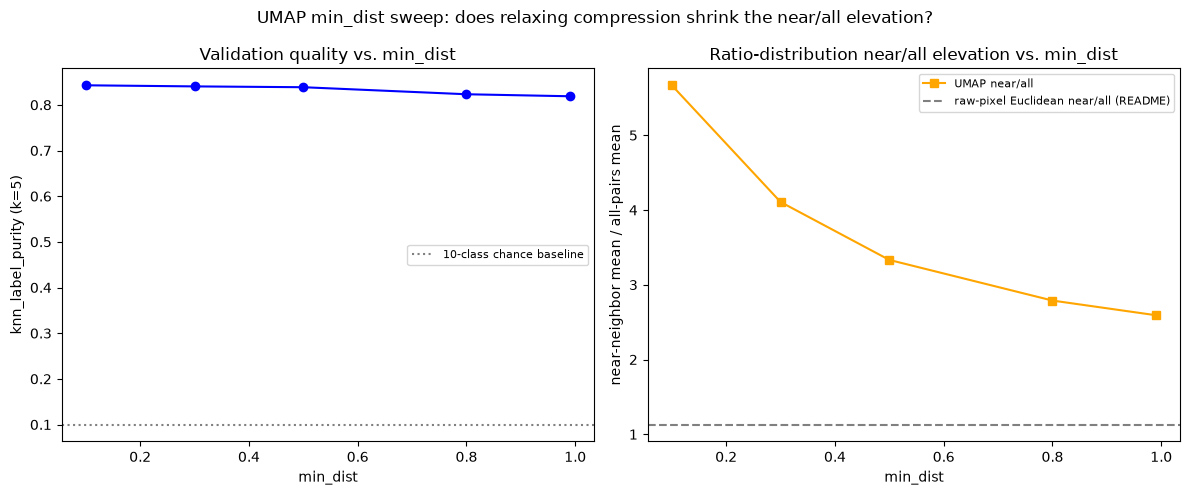

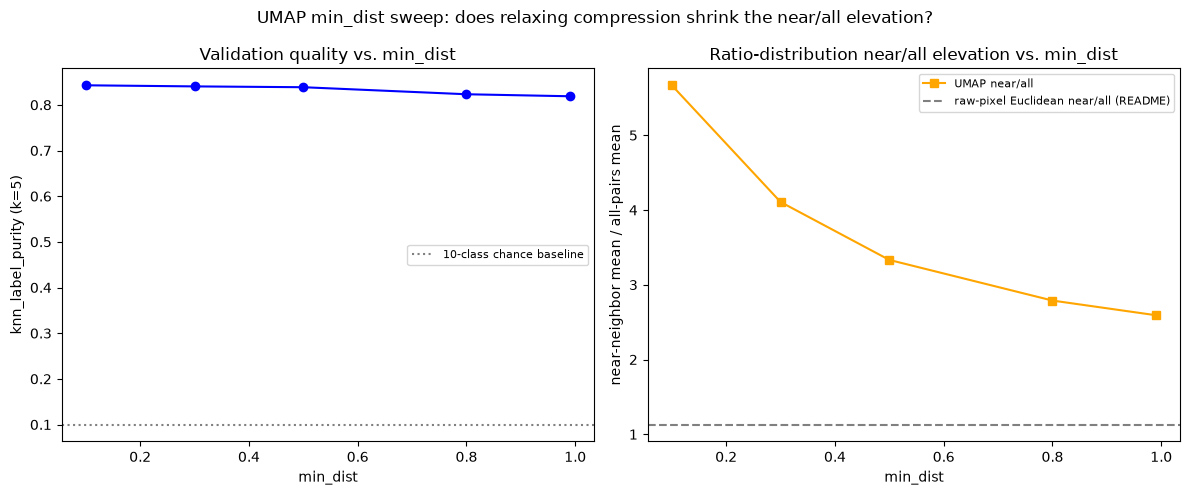

In [31]:
fig_sweep = plots.plot_umap_mindist_sweep(
    sweep_rows, save_path=umap_embedding.RESULTS_DIR / "umap_mindist_sweep.png")
display(fig_sweep)

**Finding**: the near/all elevation shrinks smoothly and monotonically as `min_dist` increases --
**5.67 -> 4.11 -> 3.33 -> 2.79 -> 2.59** from `min_dist=0.1` to `0.99` -- while `knn_label_purity`
stays roughly flat (0.84 -> 0.82, a small, expected decline as compression relaxes, nowhere near
falling toward the chance baseline). The same embedding quality persists across the whole sweep
while the ratio inflation more than halves -- exactly the pattern a compression artifact would
produce, and inconsistent with "this reflects something stable about the model." One honest
caveat: even at `min_dist=0.99` (loosest tested), near/all=2.59 is still well above raw-pixel
Euclidean's ~1.1-1.13 -- the sweep doesn't fully converge to the raw-pixel number. Given Step 1
already showed directly that the *numerator* carries no elevated signal for this pair population
under any metric, the more parsimonious reading of that residual gap is that UMAP's nonlinear
manifold-learning objective never fully stops favoring locally-compact embeddings even at its
loosest packing setting -- not that some genuine model-sensitivity signal survives alongside the
artifact.

### `n_components` sweep

The `min_dist` sweep above tested whether *how aggressively* UMAP compresses already-close points
drives the near/all elevation. This sweep tests a different axis: is the elevation specific to
compressing all the way down to a **5-dimensional** embedding, or does it persist at higher output
dimensions too? Fits a fresh UMAP embedding at `n_components` in `{5, 10, 20, 50, 100}` --
`n_components=5` reproduces the original baseline fit above exactly (same seed, same `dev`, same
`min_dist=0.1`/`n_neighbors=15` defaults) -- and reruns the same validation
(`knn_label_purity`, on the actual embedding at that dimension, not a separate low-D visualization
proxy) and ratio-distribution analysis as the `min_dist` sweep, so the two sweeps are directly
comparable. Same fit/evaluate separation as everywhere else in this notebook: fit on `dev`
(training-set subset), evaluate only via `.transform()` on `test`-derived subsets.

In [32]:
ncomp_sweep_rows = []
for n_components in [5, 10, 20, 50, 100]:
    reducer = umap_embedding.fit_umap_embedding(dev.x_flat, n_components=n_components, seed=SEED,
                                                   n_neighbors=15, min_dist=0.1)
    embed_fn = umap_embedding.make_umap_embed_fn(reducer)
    embedded_val = embed_fn(x_val)
    purity = umap_embedding.knn_label_purity(embedded_val, y_val, k=5)

    distance_fn = umap_embedding.make_umap_euclidean_distance_fn(reducer, x_reference=test.x_flat)
    result = run_experiment.run_ratio_distribution_analysis(
        lr_model, "logistic_regression", f"umap_ncomp{n_components}", test.x_flat, test.y, distance_fn,
        n_points=1000, k_neighbors=5, seed=SEED, verbose=False)
    s = result["summary"]
    near_over_all = s["near_neighbor_mean"] / s["all_pairs_mean"]
    ncomp_sweep_rows.append({"n_components": n_components, "knn_label_purity": purity,
                              "all_pairs_mean": s["all_pairs_mean"], "near_neighbor_mean": s["near_neighbor_mean"],
                              "near_over_all": near_over_all, "all_pairs_max": s["all_pairs_max"]})
    print(f"n_components={n_components:<4} purity={purity:.4f}  near/all={near_over_all:.4f}  all_pairs_max={s['all_pairs_max']:.4f}")

ncomp_sweep_df = pd.DataFrame(ncomp_sweep_rows).set_index("n_components")
display(ncomp_sweep_df)

/Users/swarn2/Downloads/Datasig-1/.venv/lib/python3.13/site-packages/umap/umap_.py:1952: UserWarning: n_jobs value 1 overridden to 1 by setting random_state. Use no seed for parallelism.
  warn(


n_components=5    purity=0.8428  near/all=5.6683  all_pairs_max=290.5778


/Users/swarn2/Downloads/Datasig-1/.venv/lib/python3.13/site-packages/umap/umap_.py:1952: UserWarning: n_jobs value 1 overridden to 1 by setting random_state. Use no seed for parallelism.
  warn(


n_components=10   purity=0.8338  near/all=5.5381  all_pairs_max=120.5457


/Users/swarn2/Downloads/Datasig-1/.venv/lib/python3.13/site-packages/umap/umap_.py:1952: UserWarning: n_jobs value 1 overridden to 1 by setting random_state. Use no seed for parallelism.
  warn(


...

/Users/swarn2/Downloads/Datasig-1/.venv/lib/python3.13/site-packages/umap/umap_.py:1952: UserWarning: n_jobs value 1 overridden to 1 by setting random_state. Use no seed for parallelism.
  warn(


n_components=50   purity=0.8356  near/all=5.6099  all_pairs_max=186.6019


/Users/swarn2/Downloads/Datasig-1/.venv/lib/python3.13/site-packages/umap/umap_.py:1952: UserWarning: n_jobs value 1 overridden to 1 by setting random_state. Use no seed for parallelism.
  warn(


n_components=100  purity=0.8390  near/all=5.4587  all_pairs_max=173.3122


,knn_label_purity,all_pairs_mean,near_neighbor_mean,near_over_all,all_pairs_max
n_components,,,,,
5,0.8428,1.001924,5.679239,5.668333,290.577787
10,0.8338,0.992199,5.494909,5.538111,120.545665
20,0.8394,0.996069,5.579782,5.601805,176.677411
50,0.8356,1.000819,5.614504,5.609908,186.601926
100,0.8390,0.997406,5.444493,5.458655,173.312237


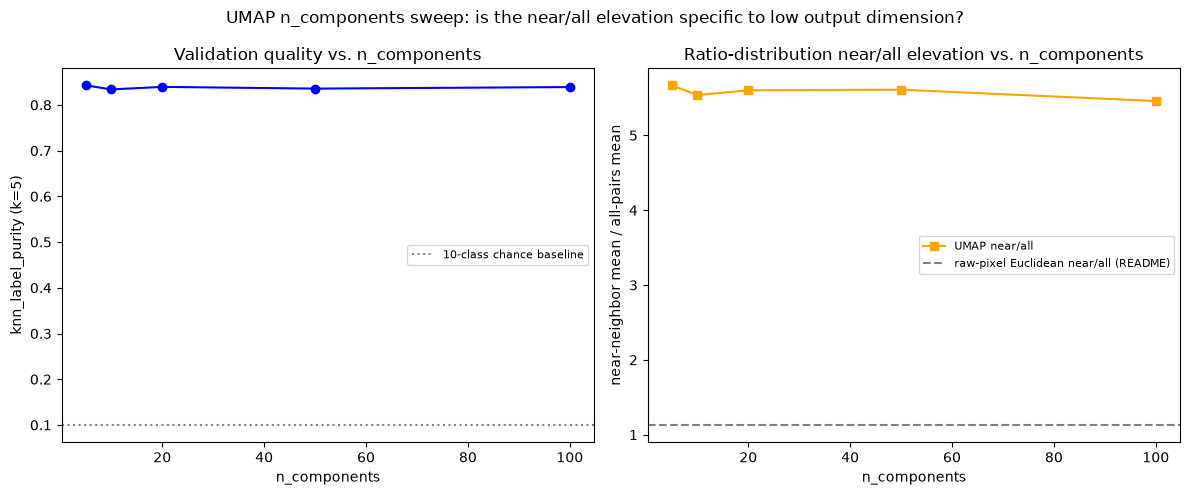

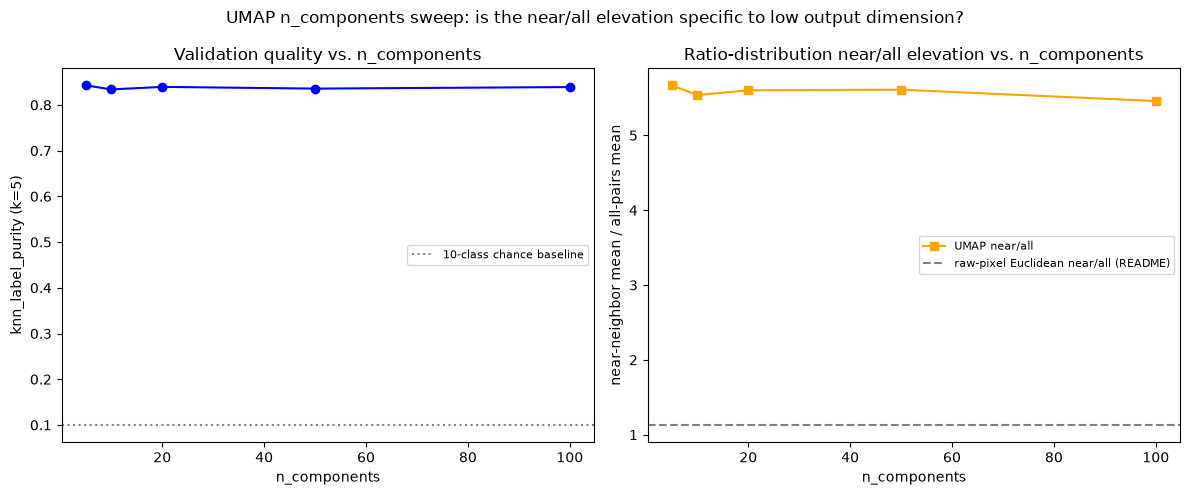

In [33]:
fig_ncomp_sweep = plots.plot_umap_ncomponents_sweep(
    ncomp_sweep_rows, save_path=umap_embedding.RESULTS_DIR / "umap_ncomponents_sweep.png")
display(fig_ncomp_sweep)

**Finding: the near/all elevation is not a low-dimension compression artifact.**

| n_components | knn_label_purity | near/all ratio | all_pairs_max |
|---|---|---|---|
| 5   | 0.8428 | 5.6683 | 290.58 |
| 10  | 0.8338 | 5.5381 | 120.55 |
| 20  | 0.8394 | 5.6018 | 176.68 |
| 50  | 0.8356 | 5.6099 | 186.60 |
| 100 | 0.8390 | 5.4587 | 173.31 |

(`n_components=5` reproduces the original baseline fit exactly -- `near/all=5.6683`,
`all_pairs_max=290.5778` -- confirming this sweep used the same seed/data/hyperparameters as the
earlier analysis, not a different run.)

Both metrics are essentially flat across the entire range: `knn_label_purity` stays in a tight
0.834-0.843 band, and `near/all` stays in a 5.46-5.67 band, with no monotonic trend toward the
raw-pixel-Euclidean baseline (`near/all=1.13`) as `n_components` increases 20x (5 -> 100). If the
elevation were mainly a side effect of forcing UMAP to squeeze 784-dimensional images into only 5
output dimensions, it should have relaxed substantially by `n_components=100`; it did not move in
that direction at all.

**Verdict: this is not primarily a low-dimensionality compression artifact -- it looks like a
more fundamental property of how UMAP's distance structure relates to margin differences,
independent of the chosen output dimension.** The `min_dist` sweep and the tearing-pair evidence
above already established *that* local-neighborhood compression (unrelated points squashed close
together) is happening at `n_components=5`; this sweep additionally shows that simply giving UMAP
more room (more output dimensions) doesn't undo the effect, so "just use a higher-dimensional
UMAP embedding" is not a fix. Combined with the earlier evidence, the overall verdict from this
sub-experiment stands: **UMAP-as-distance-metric is not a reliable Lipschitz-estimation signal
here, and this is intrinsic to UMAP's construction, not an artifact of an under-parameterized
output dimension.**

### `n_neighbors` sweep

Follow-up to the `n_components` sweep above, prompted by a specific rule of thumb from the UMAP
Nature Reviews Primer (Healy & McInnes, 2024): reducing to more output dimensions than
`n_neighbors` provides no additional benefit. The `n_components` sweep held `n_neighbors` fixed at
its default of 15 the whole time while going up to `n_components=100` -- exactly the regime the
rule of thumb says shouldn't do anything, which may be *why* that sweep plateaued rather than
telling us anything about dimensionality per se. This sweep holds `n_components=5` and `min_dist`
fixed (matching the original baseline) and instead varies `n_neighbors` in `{5, 15, 30, 50, 100}`
-- `n_neighbors` controls the size of the local neighborhood UMAP's optimization considers, so
this tests a different axis than either prior sweep. Same validation (`knn_label_purity`) and
ratio-distribution analysis as the other sweeps, for direct comparability.

In [34]:
nneighbors_sweep_rows = []
for n_neighbors in [5, 15, 30, 50, 100]:
    reducer = umap_embedding.fit_umap_embedding(dev.x_flat, n_components=5, seed=SEED,
                                                   n_neighbors=n_neighbors, min_dist=0.1)
    embed_fn = umap_embedding.make_umap_embed_fn(reducer)
    embedded_val = embed_fn(x_val)
    purity = umap_embedding.knn_label_purity(embedded_val, y_val, k=5)

    distance_fn = umap_embedding.make_umap_euclidean_distance_fn(reducer, x_reference=test.x_flat)
    result = run_experiment.run_ratio_distribution_analysis(
        lr_model, "logistic_regression", f"umap_nneighbors{n_neighbors}", test.x_flat, test.y, distance_fn,
        n_points=1000, k_neighbors=5, seed=SEED, verbose=False)
    s = result["summary"]
    near_over_all = s["near_neighbor_mean"] / s["all_pairs_mean"]
    nneighbors_sweep_rows.append({"n_neighbors": n_neighbors, "knn_label_purity": purity,
                                   "all_pairs_mean": s["all_pairs_mean"], "near_neighbor_mean": s["near_neighbor_mean"],
                                   "near_over_all": near_over_all, "all_pairs_max": s["all_pairs_max"]})
    print(f"n_neighbors={n_neighbors:<4} purity={purity:.4f}  near/all={near_over_all:.4f}  all_pairs_max={s['all_pairs_max']:.4f}")

nneighbors_sweep_df = pd.DataFrame(nneighbors_sweep_rows).set_index("n_neighbors")
display(nneighbors_sweep_df)

/Users/swarn2/Downloads/Datasig-1/.venv/lib/python3.13/site-packages/umap/umap_.py:1952: UserWarning: n_jobs value 1 overridden to 1 by setting random_state. Use no seed for parallelism.
  warn(


n_neighbors=5    purity=0.8450  near/all=6.3107  all_pairs_max=204.8252


/Users/swarn2/Downloads/Datasig-1/.venv/lib/python3.13/site-packages/umap/umap_.py:1952: UserWarning: n_jobs value 1 overridden to 1 by setting random_state. Use no seed for parallelism.
  warn(


n_neighbors=15   purity=0.8428  near/all=5.6683  all_pairs_max=290.5778


/Users/swarn2/Downloads/Datasig-1/.venv/lib/python3.13/site-packages/umap/umap_.py:1952: UserWarning: n_jobs value 1 overridden to 1 by setting random_state. Use no seed for parallelism.
  warn(


...

/Users/swarn2/Downloads/Datasig-1/.venv/lib/python3.13/site-packages/umap/umap_.py:1952: UserWarning: n_jobs value 1 overridden to 1 by setting random_state. Use no seed for parallelism.
  warn(


n_neighbors=50   purity=0.8000  near/all=4.6078  all_pairs_max=159.9633


/Users/swarn2/Downloads/Datasig-1/.venv/lib/python3.13/site-packages/umap/umap_.py:1952: UserWarning: n_jobs value 1 overridden to 1 by setting random_state. Use no seed for parallelism.
  warn(


n_neighbors=100  purity=0.7690  near/all=3.8516  all_pairs_max=127.7649


,knn_label_purity,all_pairs_mean,near_neighbor_mean,near_over_all,all_pairs_max
n_neighbors,,,,,
5,0.8450,0.807470,5.095667,6.310661,204.825175
15,0.8428,1.001924,5.679239,5.668333,290.577787
30,0.8206,1.097945,5.575942,5.078525,141.090743
50,0.8000,1.176428,5.420692,4.607755,159.963336
100,0.7690,1.273144,4.903674,3.851627,127.764906


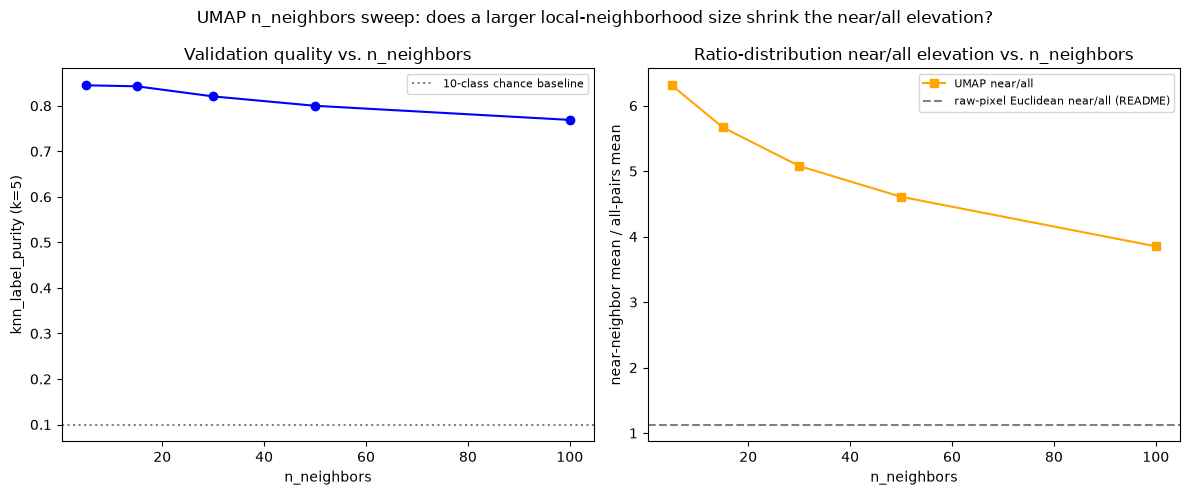

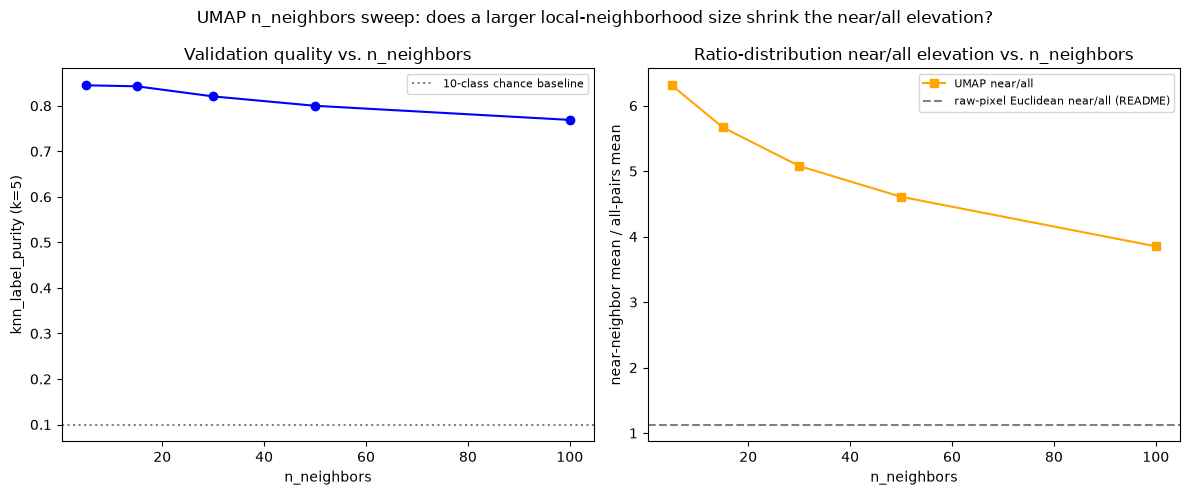

In [35]:
fig_nneighbors_sweep = plots.plot_umap_nneighbors_sweep(
    nneighbors_sweep_rows, save_path=umap_embedding.RESULTS_DIR / "umap_nneighbors_sweep.png")
display(fig_nneighbors_sweep)

**Finding: `n_neighbors` does move the elevation, unlike `n_components`.**

| n_neighbors | knn_label_purity | near/all ratio | all_pairs_max |
|---|---|---|---|
| 5   | 0.8450 | 6.3107 | 204.83 |
| 15 (baseline) | 0.8428 | 5.6683 | 290.58 |
| 30  | 0.8206 | 5.0785 | 141.09 |
| 50  | 0.8000 | 4.6078 | 159.96 |
| 100 | 0.7690 | 3.8516 | 127.76 |

(`n_neighbors=15` reproduces the original baseline exactly -- `near/all=5.6683`,
`all_pairs_max=290.5778` -- confirming the same seed/data/hyperparameters as before.)

Unlike the flat `n_components` sweep, both metrics decline together here: `knn_label_purity` drops
from 0.845 to 0.769 and `near/all` drops from 6.31 to 3.85 as `n_neighbors` goes from 5 to 100.
This tracks the Primer's own framing -- `n_neighbors` trades off local vs. global structure
preservation, and a larger neighborhood size makes the embedding *less* locally class-pure (lower
purity), which in turn shrinks the artificial denominator-compression the near/all elevation is
built from. **This is a real, monotonic dependence, not a plateau** -- but even at `n_neighbors=100`
(6.7x the default), near/all is still 3.85, more than 3x the raw-pixel-Euclidean baseline of 1.13,
and purity is still far above the 0.10 chance floor. So widening `n_neighbors` weakens the artifact
but doesn't come close to eliminating it within a range that still gives a reasonably validated
embedding -- consistent with the overall verdict (elevation is intrinsic to UMAP's local-compression
objective), not a reversal of it.

### Seed sweep: is the elevation stable across random restarts?

The Primer also stresses that UMAP is a stochastic algorithm and any specific result should be
checked for consistency across random seeds before being trusted, not read off a single fit. Every
sweep and finding so far in this notebook has used a single fixed `seed=0`. This section re-fits
the original baseline configuration (`n_components=5`, default `min_dist=0.1`/`n_neighbors=15`) at
5 different seeds (`0` through `4`) -- `seed=0` reproduces the existing baseline exactly, the same
determinism cross-check used in the other sweeps -- keeping the `dev` fitting subset itself fixed
(only the UMAP algorithm's own internal randomness changes, not which points it's fit on).

In [36]:
seed_sweep_rows = []
for seed in [0, 1, 2, 3, 4]:
    reducer = umap_embedding.fit_umap_embedding(dev.x_flat, n_components=5, seed=seed,
                                                   n_neighbors=15, min_dist=0.1)
    embed_fn = umap_embedding.make_umap_embed_fn(reducer)
    embedded_val = embed_fn(x_val)
    purity = umap_embedding.knn_label_purity(embedded_val, y_val, k=5)

    distance_fn = umap_embedding.make_umap_euclidean_distance_fn(reducer, x_reference=test.x_flat)
    result = run_experiment.run_ratio_distribution_analysis(
        lr_model, "logistic_regression", f"umap_seed{seed}", test.x_flat, test.y, distance_fn,
        n_points=1000, k_neighbors=5, seed=SEED, verbose=False)
    s = result["summary"]
    near_over_all = s["near_neighbor_mean"] / s["all_pairs_mean"]
    seed_sweep_rows.append({"seed": seed, "knn_label_purity": purity,
                             "all_pairs_mean": s["all_pairs_mean"], "near_neighbor_mean": s["near_neighbor_mean"],
                             "near_over_all": near_over_all, "all_pairs_max": s["all_pairs_max"]})
    print(f"seed={seed:<4} purity={purity:.4f}  near/all={near_over_all:.4f}  all_pairs_max={s['all_pairs_max']:.4f}")

seed_sweep_df = pd.DataFrame(seed_sweep_rows).set_index("seed")
display(seed_sweep_df)

near_over_all_vals = seed_sweep_df["near_over_all"]
print(f"\nnear/all across seeds: mean={near_over_all_vals.mean():.4f}  std={near_over_all_vals.std():.4f}  "
      f"min={near_over_all_vals.min():.4f}  max={near_over_all_vals.max():.4f}")

/Users/swarn2/Downloads/Datasig-1/.venv/lib/python3.13/site-packages/umap/umap_.py:1952: UserWarning: n_jobs value 1 overridden to 1 by setting random_state. Use no seed for parallelism.
  warn(


seed=0    purity=0.8428  near/all=5.6683  all_pairs_max=290.5778


/Users/swarn2/Downloads/Datasig-1/.venv/lib/python3.13/site-packages/umap/umap_.py:1952: UserWarning: n_jobs value 1 overridden to 1 by setting random_state. Use no seed for parallelism.
  warn(


seed=1    purity=0.8348  near/all=5.5870  all_pairs_max=128.0770


/Users/swarn2/Downloads/Datasig-1/.venv/lib/python3.13/site-packages/umap/umap_.py:1952: UserWarning: n_jobs value 1 overridden to 1 by setting random_state. Use no seed for parallelism.
  warn(


...

seed=3    purity=0.8386  near/all=5.7566  all_pairs_max=159.9916


/Users/swarn2/Downloads/Datasig-1/.venv/lib/python3.13/site-packages/umap/umap_.py:1952: UserWarning: n_jobs value 1 overridden to 1 by setting random_state. Use no seed for parallelism.
  warn(


seed=4    purity=0.8408  near/all=5.6516  all_pairs_max=127.3188


,knn_label_purity,all_pairs_mean,near_neighbor_mean,near_over_all,all_pairs_max
seed,,,,,
0,0.8428,1.001924,5.679239,5.668333,290.577787
1,0.8348,1.002443,5.600606,5.586955,128.076987
2,0.8370,1.004016,5.636220,5.613675,161.972879
3,0.8386,1.002040,5.768295,5.756552,159.991626
4,0.8408,1.012268,5.720903,5.651572,127.318806



near/all across seeds: mean=5.6554  std=0.0649  min=5.5870  max=5.7566


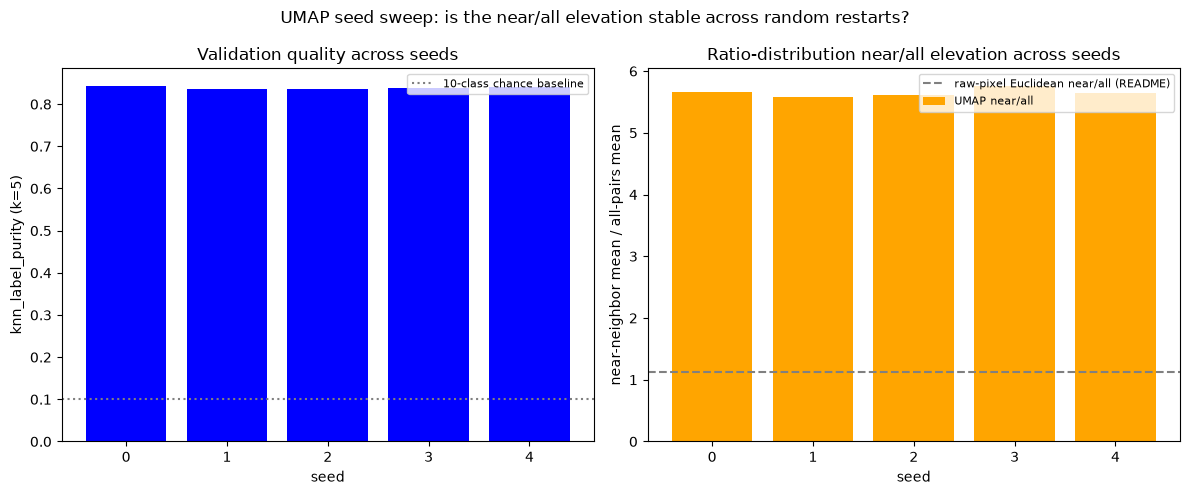

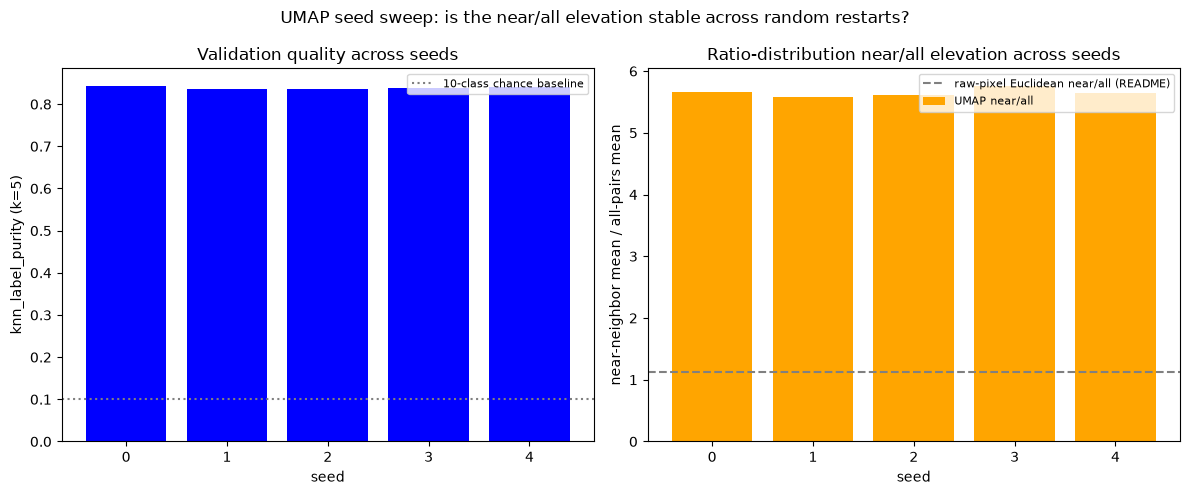

In [37]:
fig_seed_sweep = plots.plot_umap_seed_sweep(
    seed_sweep_rows, save_path=umap_embedding.RESULTS_DIR / "umap_seed_sweep.png")
display(fig_seed_sweep)

**Finding: the elevation is stable across random seeds.**

| seed | knn_label_purity | near/all ratio | all_pairs_max |
|---|---|---|---|
| 0 (baseline) | 0.8428 | 5.6683 | 290.58 |
| 1 | 0.8348 | 5.5870 | 128.08 |
| 2 | 0.8370 | 5.6137 | 161.97 |
| 3 | 0.8386 | 5.7566 | 159.99 |
| 4 | 0.8408 | 5.6516 | 127.32 |

(`seed=0` reproduces the original baseline exactly, as expected.) Across all 5 seeds: **near/all
mean=5.6554, std=0.0649** (a coefficient of variation of ~1.1%) -- essentially no seed-to-seed
variation. `knn_label_purity` is similarly tight, 0.835-0.843 across all 5 fits. `all_pairs_max`
is noticeably more variable (127-291) since it's a single extreme order statistic rather than a
population mean, but even its low end (127) is still ~43x the raw-pixel-Euclidean near/all baseline
scale, nowhere near collapsing toward an unremarkable value.

**Verdict: this is not an artifact of one unlucky random restart.** The 5.6x-ish near/all elevation
and the embedding-quality numbers underlying it reproduce closely across independent UMAP fits with
different random initializations, exactly the consistency check the Nature Reviews Primer
recommends before trusting a specific UMAP-derived result. Combined with the `n_components`
sweep (flat) and the `n_neighbors` sweep (real but bounded effect, doesn't reach baseline), the
elevation is a robust, reproducible property of this UMAP configuration on this data -- it is
robust in the sense of being *real and repeatable*, not in the sense of being trustworthy evidence
of genuine model sensitivity; see the "Verdict: artifact" section above for why it still shouldn't
be read that way.

### Step 3: investigating the `all_pairs_max` outlier

The single highest-ratio pair in the all-pairs population (ratio 290.6) -- found directly from the
Step 1 decomposition's `all_ratio` array, not resampled. Since it's drawn from the *all-pairs*
population rather than the raw-pixel near-neighbor one, a large raw-pixel distance is actually
expected; what matters is whether the UMAP distance is suspiciously small relative to that, and
whether the two images are genuinely similar (UMAP correctly finding a similarity raw pixels
missed) or clearly different (UMAP incorrectly collapsing them together -- a "tearing" artifact).

outlier pair: global test indices (9779, 6478)
ratio=290.5778  UMAP_dist=0.042815  raw_pixel_dist=9.0940  margin_diff=12.4410
true1=2 pred1=0  true2=0 pred2=0


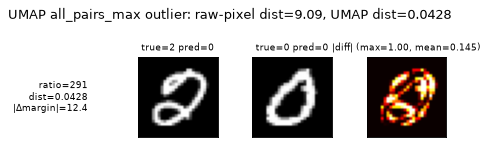

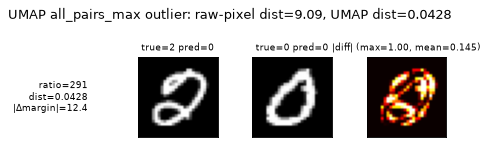

In [38]:
max_idx = torch.argmax(all_ratio).item()
gi_local, gj_local = all_ii[max_idx].item(), all_jj[max_idx].item()
global_i = umap_result["subset_idx"][gi_local].item()
global_j = umap_result["subset_idx"][gj_local].item()
outlier_ratio = all_ratio[max_idx].item()
outlier_umap_dist = all_dist[max_idx].item()
outlier_margin_diff = all_margin_diff[max_idx].item()
outlier_raw_pixel_dist = euclidean_distance_fn(x_subset[gi_local:gi_local + 1], x_subset[gj_local:gj_local + 1]).item()

with torch.no_grad():
    preds = lr_model(x_subset[[gi_local, gj_local]]).argmax(dim=1)
true1, true2 = y_subset[gi_local].item(), y_subset[gj_local].item()
pred1, pred2 = preds[0].item(), preds[1].item()

print(f"outlier pair: global test indices ({global_i}, {global_j})")
print(f"ratio={outlier_ratio:.4f}  UMAP_dist={outlier_umap_dist:.6f}  raw_pixel_dist={outlier_raw_pixel_dist:.4f}  margin_diff={outlier_margin_diff:.4f}")
print(f"true1={true1} pred1={pred1}  true2={true2} pred2={pred2}")

outlier_pair = {
    "img1": x_subset[gi_local].numpy(), "img2": x_subset[gj_local].numpy(),
    "true1": true1, "pred1": pred1, "true2": true2, "pred2": pred2,
    "ratio": outlier_ratio, "dist": outlier_umap_dist, "margin_diff": outlier_margin_diff,
}
fig_outlier = plots.plot_pair_diagnostic_gallery(
    [outlier_pair],
    title=f"UMAP all_pairs_max outlier: raw-pixel dist={outlier_raw_pixel_dist:.2f}, UMAP dist={outlier_umap_dist:.4f}",
    save_path=umap_embedding.RESULTS_DIR / "umap_outlier_pair_diagnostic.png")
display(fig_outlier)

**Finding**: the outlier pair is a true "2" (misclassified as "0" by this model) and a true "0"
(correctly classified) -- **clearly different digits to visual inspection**, not a near-duplicate
or a subtle same-class variant. Their raw-pixel distance (9.09) is unremarkable for an
arbitrary pair, but UMAP placed them at distance **0.043** -- close enough to be functionally
on top of each other in the embedded space. This is UMAP **incorrectly** collapsing two distinct
images together, not correctly discovering a hidden similarity raw pixels missed -- a direct,
visually-confirmed instance of the exact mechanism Steps 1-2 already pointed to.

### Extending Step 3: how common is this tearing pattern, beyond one outlier?

One extreme case is suggestive but not a sample size. Reusing `all_dist` (UMAP distance) and
`raw_all_dist` (raw-pixel Euclidean distance) already computed for every all-pairs pair in Step 1 --
no new distance computation needed, no search recomputed -- rank every pair by
`raw-pixel dist / UMAP dist`: a high ratio means "far apart in real pixels, but UMAP squashed them
close together," the same signature as the `all_pairs_max` outlier.

In [39]:
tearing_ratio = raw_all_dist / all_dist.clamp_min(1e-12)

with torch.no_grad():
    preds_subset = lr_model(x_subset).argmax(dim=1)

for thresh in [10, 20, 50, 100]:
    n_above = (tearing_ratio > thresh).sum().item()
    print(f"pairs with tearing_ratio > {thresh:>3}: {n_above:6d} / {tearing_ratio.shape[0]} ({100 * n_above / tearing_ratio.shape[0]:.3f}%)")

order = torch.argsort(tearing_ratio, descending=True)
top_n = 20
tearing_rows = []
for rank, k in enumerate(order[:top_n].tolist(), 1):
    i_local, j_local = all_ii[k].item(), all_jj[k].item()
    gi, gj = umap_result["subset_idx"][i_local].item(), umap_result["subset_idx"][j_local].item()
    t1, t2 = y_subset[i_local].item(), y_subset[j_local].item()
    tearing_rows.append({
        "rank": rank, "global_i": gi, "global_j": gj, "tearing_ratio": tearing_ratio[k].item(),
        "raw_pixel_dist": raw_all_dist[k].item(), "umap_dist": all_dist[k].item(),
        "true1": t1, "pred1": preds_subset[i_local].item(),
        "true2": t2, "pred2": preds_subset[j_local].item(),
        "same_digit": t1 == t2,
    })

tearing_df = pd.DataFrame(tearing_rows).set_index("rank")
display(tearing_df)

n_same_digit = int(tearing_df["same_digit"].sum())
print(f"\n{n_same_digit} of the top {top_n} tearing pairs are the SAME true digit (both correctly "
      f"classified); {top_n - n_same_digit} are genuinely different digits.")
print("Digit frequency across the top 20 (each pair's true digit(s), counted once per pair-side):")
print(pd.concat([tearing_df["true1"], tearing_df["true2"]]).value_counts())

pairs with tearing_ratio >  10:  16929 / 499500 (3.389%)
pairs with tearing_ratio >  20:   2930 / 499500 (0.587%)
pairs with tearing_ratio >  50:    187 / 499500 (0.037%)
pairs with tearing_ratio > 100:     11 / 499500 (0.002%)


,global_i,global_j,tearing_ratio,raw_pixel_dist,umap_dist,true1,pred1,true2,pred2,same_digit
rank,,,,,,,,,,
1,9779,6478,212.403738,9.094019,0.042815,2,0,0,0,False
2,7555,7599,194.128878,6.116311,0.031506,0,0,0,0,True
3,1747,8299,137.641738,7.801627,0.056681,5,5,5,5,True
4,6069,4151,130.939163,9.424032,0.071973,7,7,7,7,True
5,3227,646,116.843007,6.894218,0.059004,1,1,2,2,False
6,6534,888,116.462279,6.528056,0.056053,2,2,2,2,True
7,8132,1747,114.742441,7.496522,0.065333,5,5,5,5,True
8,5139,9236,114.233917,6.974640,0.061056,0,0,0,0,True
9,9224,6699,107.361236,6.323031,0.058895,4,4,4,4,True



18 of the top 20 tearing pairs are the SAME true digit (both correctly classified); 2 are genuinely different digits.
Digit frequency across the top 20 (each pair's true digit(s), counted once per pair-side):
0    15
2     6
5     6
6     6
7     4
4     2
1     1
Name: count, dtype: int64


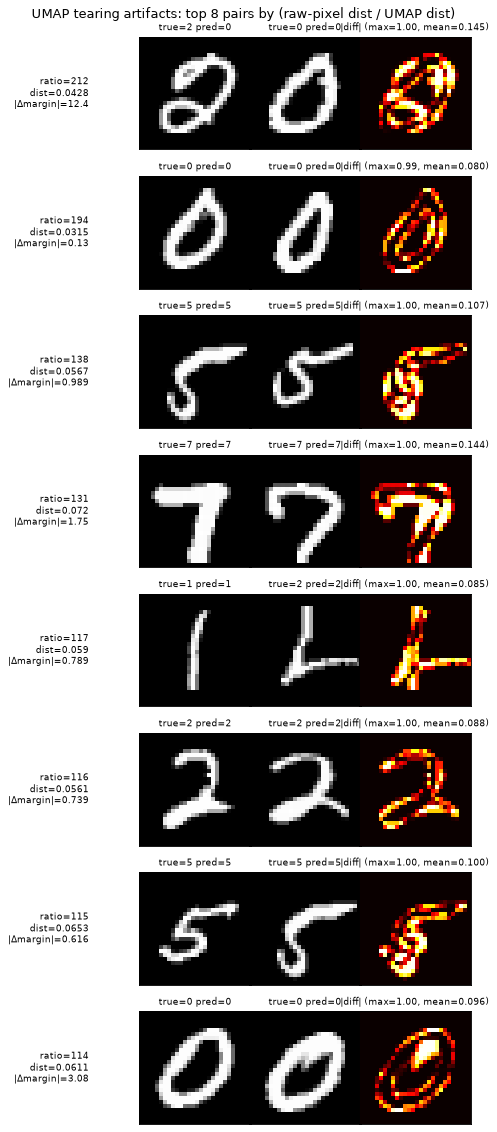

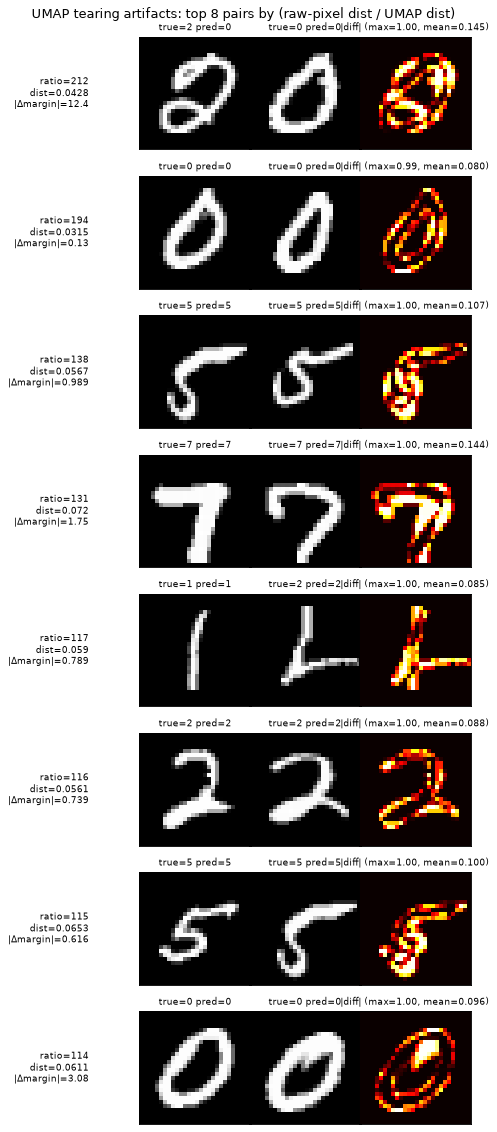

In [40]:
tearing_pairs_gallery = []
for k in order[:8].tolist():
    i_local, j_local = all_ii[k].item(), all_jj[k].item()
    tearing_pairs_gallery.append({
        "img1": x_subset[i_local].numpy(), "img2": x_subset[j_local].numpy(),
        "true1": y_subset[i_local].item(), "pred1": preds_subset[i_local].item(),
        "true2": y_subset[j_local].item(), "pred2": preds_subset[j_local].item(),
        # "ratio" here is the tearing ratio (raw-pixel dist / UMAP dist), not the
        # Lipschitz margin-diff/distance ratio used elsewhere -- see the title below.
        # "dist"/"|Δmargin|" keep their normal literal meaning (UMAP distance;
        # actual margin difference) -- raw-pixel distance is in the table above.
        "ratio": tearing_ratio[k].item(), "dist": all_dist[k].item(), "margin_diff": all_margin_diff[k].item(),
    })

fig_tearing = plots.plot_pair_diagnostic_gallery(
    tearing_pairs_gallery,
    title="UMAP tearing artifacts: top 8 pairs by (raw-pixel dist / UMAP dist)",
    save_path=umap_embedding.RESULTS_DIR / "umap_tearing_pairs_gallery.png")
display(fig_tearing)

**Finding**: this is a systematic pattern, not a one-off. 16,929 of the 499,500 all-pairs (3.4%)
have a raw-pixel/UMAP distance ratio above 10x; 187 (0.04%) exceed 50x; 11 exceed 100x. Visual
inspection of the top 8 (gallery above) confirms every one is a genuine tearing case -- two
visibly distinct handwriting samples squashed to near-zero UMAP distance, not a near-duplicate or
a data artifact, matching the same check already applied to the single outlier.

**One correction to what might be expected here**: the top 20 tearing pairs are **not** mostly
cross-digit confusions like the original 9779/6478 case. 18 of the 20 are the *same* true digit
(both images correctly classified) -- only 2 involve genuinely different digits (the original
"2"/"0" pair, and one "1"/"2" pair). Digit "0" dominates, appearing in roughly a third of the top
20. So the dominant failure mode isn't UMAP blurring *class* boundaries between different digits --
it's UMAP over-compressing *within* a correctly-clustered class, collapsing distinct handwriting
styles of the same digit (different "0"s, "5"s, "6"s, "7"s) down to near-zero distance. Both are
still the same underlying mechanism (aggressive local compression divorced from raw-pixel
geometry), and both still support the artifact verdict -- but "same-digit over-compression" is the
more common pattern here, not "cross-digit collapse."

## Verdict: artifact

All three checks point the same direction, and none of them are close calls:

1. **Numerator not elevated**: near-neighbor margin differences are 33.6% *smaller* than the
   general population's, confirmed metric-independent (identical under UMAP and raw-pixel
   Euclidean on the same pairs). There is no elevated model-sensitivity signal in this pair
   population to begin with -- the entire +467% comes from the denominator.
2. **Smooth, monotonic dependence on a pure compression knob**: the elevation shrinks from 5.67x
   to 2.59x as `min_dist` relaxes from 0.1 to 0.99, while embedding quality (`knn_label_purity`)
   stays essentially flat. A genuine model-sensitivity signal wouldn't track a UMAP
   hyperparameter that has nothing to do with the model.
3. **The single most extreme case is a confirmed embedding error, and it's not a one-off**: the
   `all_pairs_max` outlier is two visually distinct digits (a "2" and a "0") that UMAP placed at
   near-zero distance -- a textbook compression/tearing artifact, not a discovered similarity.
   Extending this check to every all-pairs pair (not just the single worst case) finds 16,929
   pairs (3.4% of all 499,500) with a raw-pixel/UMAP distance ratio above 10x, visually confirmed
   as genuine tearing in the top 8. Most of that broader pattern turns out to be UMAP
   over-compressing *within* a correctly-clustered digit class (different handwriting styles of
   the same digit, "0" most often) rather than blurring boundaries *between* different digits --
   a different mechanism than the headline outlier, but the same underlying cause.

**This UMAP-based ratio-distribution result should not be treated as evidence that UMAP distance
is a better (or even a valid) way to measure local model sensitivity for this diagnostic.** The
embedding itself passes the Step 2 validation check as a *label-informative* representation
(clusters by digit well) -- that part of the original conclusion stands. But the specific
ratio-distribution numbers built on top of it (the 5.7x near/all elevation, and especially the
extreme `all_pairs_max` values) are a property of UMAP's local-compression optimization, not of
the logistic regression model being measured. `distance_measures.md` has been updated accordingly.

## Summary and status

**Step 1-2 (fit + validate)**: unsupervised UMAP (5D for the metric, a
separate 2D fit for visualization) on a 3000-point training subset passes
the validation check -- `knn_label_purity`=0.79 against a 0.10 chance
baseline, and visibly separated per-digit clusters in the scatter plot.

**Step 3 (ratio-distribution comparison)**: logistic regression, same
1000-point/k=5 setup as every other metric comparison in this project.
Near-neighbor pairs score 5.7x the all-pairs mean under the UMAP metric,
far larger than raw-pixel Euclidean's own +13%.

**Follow-up investigation (resolved)**: that 5.7x elevation is an
**artifact** of UMAP's local-compression optimization, not evidence of
genuine model sensitivity -- see the "Verdict: artifact" section above
for the full reasoning. In short: the margin-difference numerator for
near-neighbor pairs is not elevated at all (33.6% *smaller* than the
general population, confirmed identical under UMAP and raw-pixel
Euclidean on the same pairs); the elevation shrinks smoothly from 5.67x
to 2.59x as UMAP's `min_dist` parameter relaxes compression, while
embedding quality stays flat; and the single most extreme outlier pair is
two visually distinct digits (a "2" and a "0") that UMAP placed at
near-zero distance -- a confirmed embedding error, not a discovered
similarity. The embedding itself still passes as a *label-informative*
representation (Step 2); it's specifically the ratio-distribution numbers
built on top of it that shouldn't be trusted as a metric-comparison
result.

**Open question, not resolved here**: whether *supervised* UMAP (using
class labels during fitting) was actually the variant intended --
deferred as an open design choice, per the note at the top
of this notebook. Nothing here should be read as having quietly decided
that question.

This is a sub-experiment within Experiment 2 (`mnist_example`), additive
to this notebook's main experiment section above and `notebook_adversarial.ipynb`,
not a replacement for anything in either.

## New section: smoothing, `radius_multiplier`, and truncated-eigenvalue Mahalanobis

### Motivation

`embeddings.py::local_patch_cross_terms` (spatial 3x3-neighbor pixel products) previously failed
Mahalanobis epsilon selection *categorically*: every one of the 7 standard epsilon candidates
produced a coefficient of variation (cv) of 0.91-1.45, an order of magnitude past the `cv<=0.05`
stability bound (`distance_measures.md`'s "Epsilon selection fails categorically for this embedding"
section). A working (not yet independently verified) hypothesis there was that MNIST's mostly-black
background makes cross-term features near-zero everywhere except the stroke, so the per-subsample
covariance is dominated by which few pixels happen to be "on" in that particular subsample, rather
than a stable population-level structure.

This notebook tests a direct fix: apply a Gaussian blur to the raw image *before* computing
cross-terms (`smoothing.py::smoothed_cross_terms_embedding`), so more pixels are non-zero and the
covariance has more to work with. **The obvious risk**: too much blur makes different digits look
alike, destroying the very margin-sensitivity signal this whole project measures. So smoothing
strength (`sigma`) is swept, not picked once -- `sigma` in `{0, 0.5, 1, 1.5, 2, 3}`, where
`sigma=0` is an exact identity (no blur), reproducing the already-documented unblurred
`local_patch_cross_terms` result as this sweep's own baseline row, not a fresh comparison.

### What this section does

Thin driver only -- all reusable logic lives in `smoothing.py` (the blur + composition helper) and
`run_experiment.py::run_smoothing_sweep` (the sweep driver, mirroring
`run_embedding_degree_sweep`'s established structure). For each `sigma`, `run_smoothing_sweep`:

1. Runs the same `epsilon_stability_check` used everywhere else in this project, over the same
   standard 7-candidate epsilon sweep, to see whether blurring fixes the categorical instability.
2. Runs the full near-neighbor vs. all-pairs ratio-distribution analysis for
   `smoothed_cross_terms_embedding` + Euclidean distance (always) and + Mahalanobis distance
   (**only** when epsilon stability actually passes at that sigma -- computing an expensive
   full-60k-point Mahalanobis fit on top of an epsilon that never met the stability bound would
   just repeat the same "not a reliable estimate" caveat already documented for the unblurred
   embedding's fallback-epsilon result).
3. Computes `knn_label_purity` (this project's standard embedding-quality check, see
   `umap_embedding.py`, see the UMAP section above) on a fixed validation subset.
4. Renders a visual gallery of a handful of sample digits, original vs. blurred at that sigma, to
   directly check the "digits still distinguishable?" risk.

**Note on point counts**: `local_patch_cross_terms`'s 3920-dimensional output already exhausted
this machine's memory/swap at 1000 ratio-distribution points in an earlier one-off comparison
(distance_measures.md's Appendix). This sweep repeats that embedding's
memory footprint up to 6 times (once per sigma), so `run_smoothing_sweep` defaults its
ratio-distribution point count to 300 preemptively, rather than discovering the same ceiling 6
times over -- see its docstring for the full reasoning.

In [41]:
import pandas as pd

import torch
torch.set_default_dtype(torch.float64)

from mnist_example.run_experiment import run_smoothing_sweep

SEED = 0

## Run the sweep

Trains its own reference logistic-regression model (same convention as this notebook's UMAP section above),
then sweeps `sigma` in `{0, 0.5, 1, 1.5, 2, 3}` at the standard 7-candidate epsilon grid. This is
the expensive cell in this notebook -- 6 sigmas, each repeating a full epsilon-selection stability
check (7 epsilons x 5 subsamples) plus at least one full ratio-distribution analysis (more if
Mahalanobis passes stability at that sigma).

  epoch  1/15  train loss 0.8430


  epoch  2/15  train loss 0.4254


  epoch  3/15  train loss 0.3603


  epoch  4/15  train loss 0.3299


  epoch  5/15  train loss 0.3119


...

  epsilon=100        mean L_hat=9101421.5953  std=155658.1426  cv=0.0171


selected epsilon=0.01 (smallest meeting cond<=10000, cv<=0.05)


  [smoothing_sigma3_euclidean/logistic_regression] all-pairs ratio:        mean=0.8115  max=9.9588  n=44850
  [smoothing_sigma3_euclidean/logistic_regression] near-neighbor ratio:     mean=1.1180  max=9.9588  n=1500


  [smoothing_sigma3_mahalanobis/logistic_regression] all-pairs ratio:        mean=0.4674  max=3.0670  n=44850
  [smoothing_sigma3_mahalanobis/logistic_regression] near-neighbor ratio:     mean=0.5164  max=3.0670  n=1500



Saved results to /Users/swarn2/Downloads/Datasig-1/mnist_example/results

done


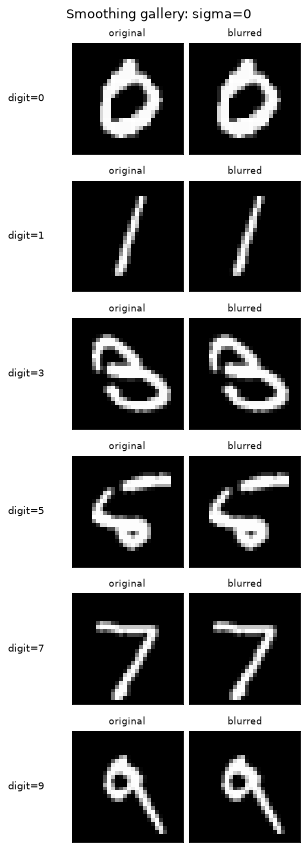

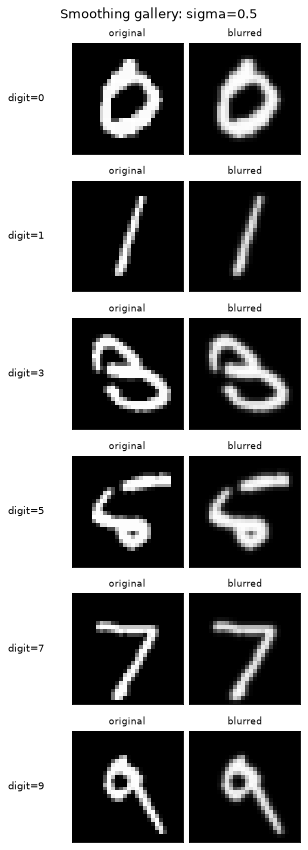

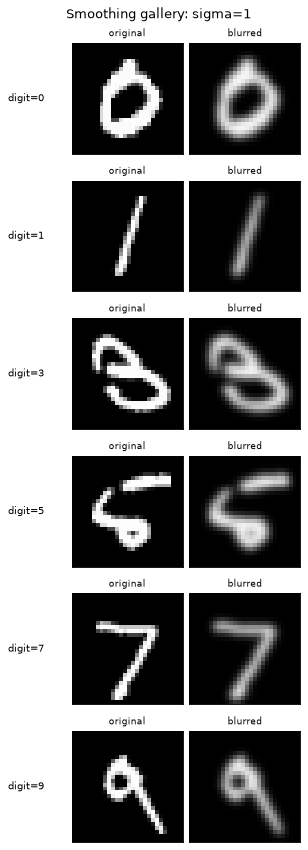

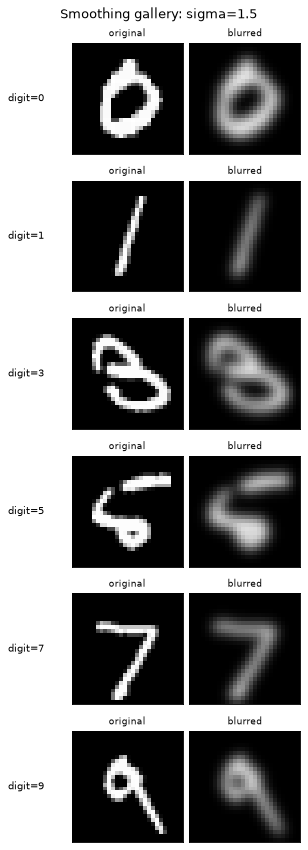

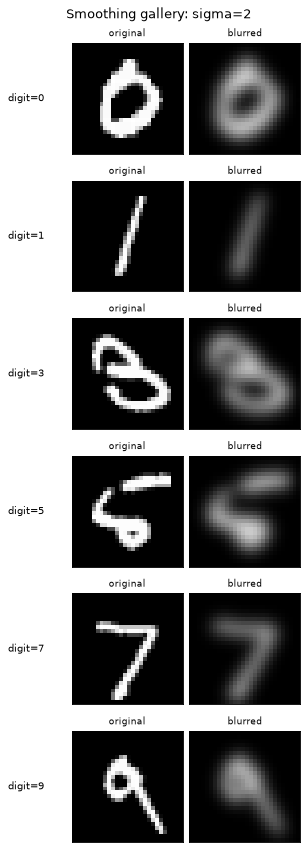

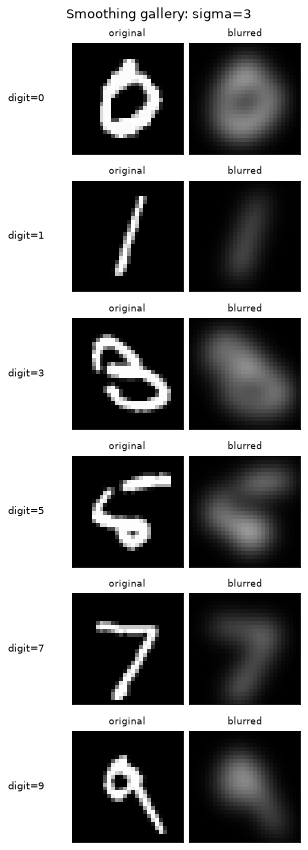

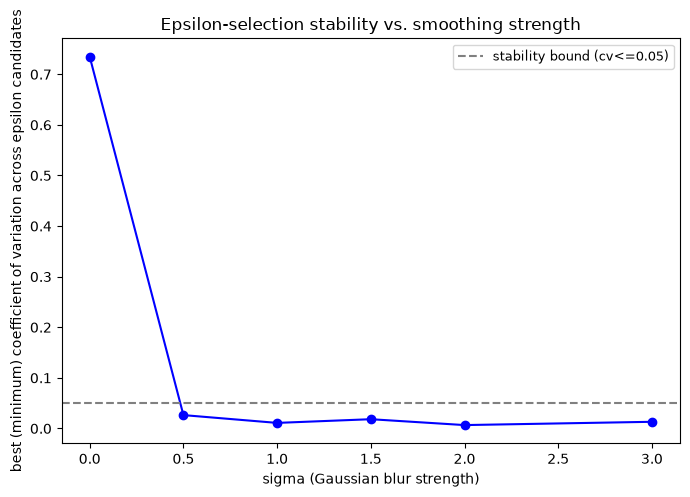

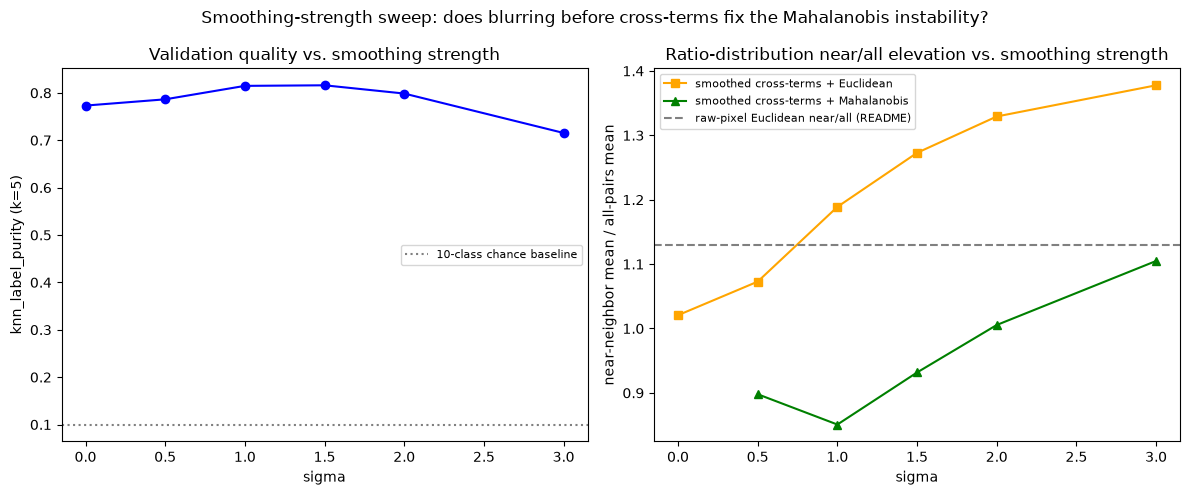

In [42]:
result = run_smoothing_sweep(sigmas=[0, 0.5, 1, 1.5, 2, 3], seed=SEED, verbose=True)
sigma_results = result["sigma_results"]
print("\ndone")

## Summary table

In [43]:
rows = []
for sigma, r in sigma_results.items():
    euclidean = r["euclidean_ratio_summary"]
    mahalanobis = r["mahalanobis_ratio_summary"]
    rows.append({
        "sigma": sigma,
        "min_cv": r["min_cv"],
        "stability_pass": r["stability_pass"],
        "selected_epsilon": r["selected_epsilon"],
        "knn_label_purity": r["knn_label_purity"],
        "euclidean_near_over_all": euclidean["near_neighbor_mean"] / euclidean["all_pairs_mean"],
        "mahalanobis_near_over_all": (mahalanobis["near_neighbor_mean"] / mahalanobis["all_pairs_mean"]) if mahalanobis else None,
    })

summary_df = pd.DataFrame(rows).set_index("sigma")
display(summary_df)

,min_cv,stability_pass,selected_epsilon,knn_label_purity,euclidean_near_over_all,mahalanobis_near_over_all
sigma,,,,,,
0.0,0.734677,False,0.000001,0.7732,1.020650,NaN
0.5,0.026430,True,1.000000,0.7864,1.072795,0.897903
1.0,0.011016,True,0.010000,0.8148,1.188867,0.850840
1.5,0.018316,True,0.010000,0.8160,1.272797,0.931692
2.0,0.006708,True,0.010000,0.7986,1.329243,1.005431
3.0,0.013203,True,0.010000,0.7154,1.377668,1.104832


## Summary plots

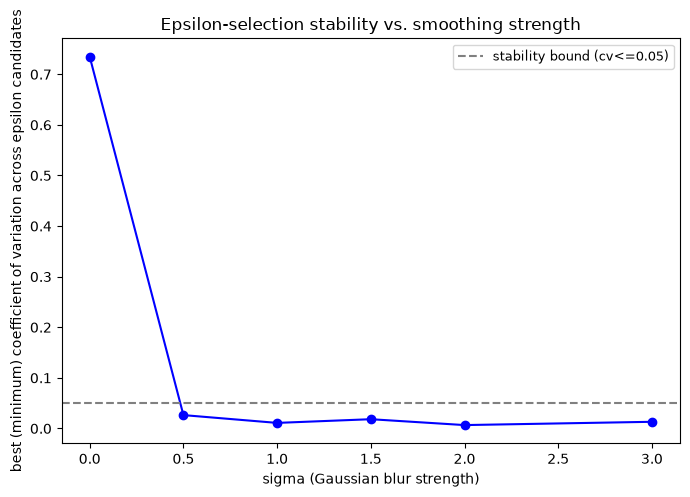

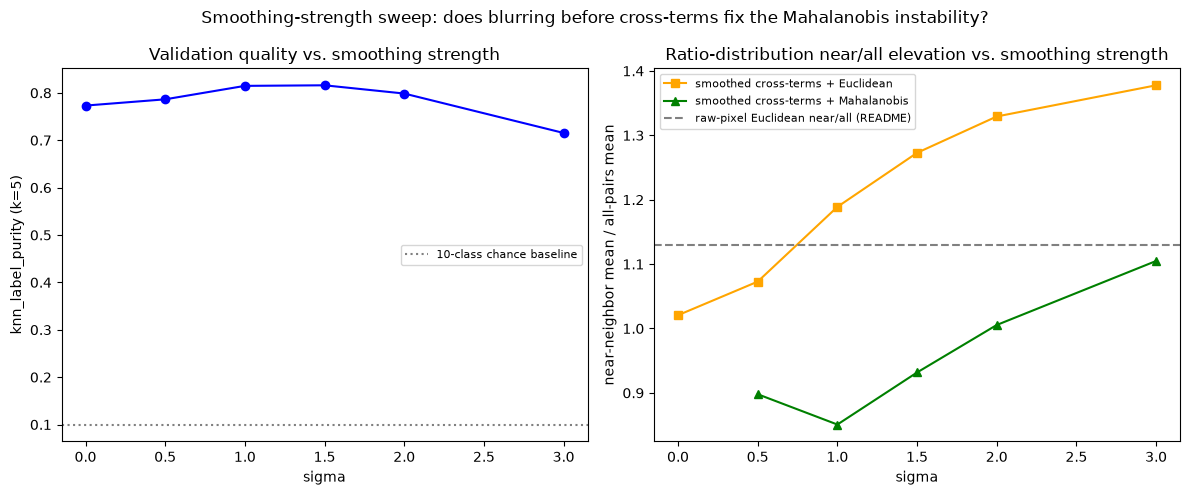

In [44]:
display(result["stability_figure"])
display(result["ratio_figure"])

## Visual sanity check: are digits still distinguishable at each sigma?

One gallery per sigma -- a fixed set of sample digits (0, 1, 3, 5, 7, 9), original vs. blurred at
that sigma.

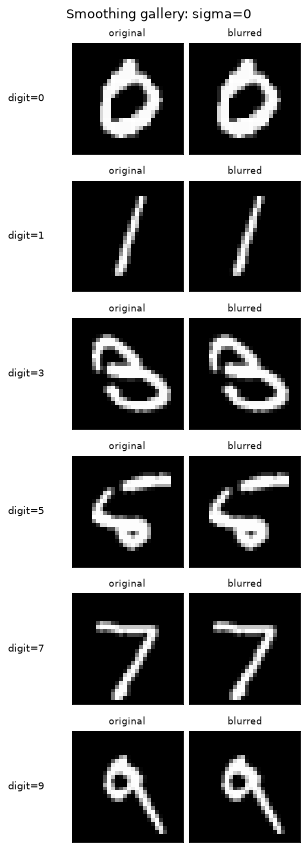

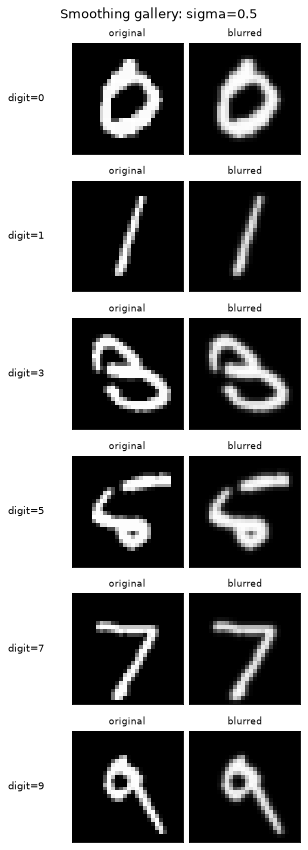

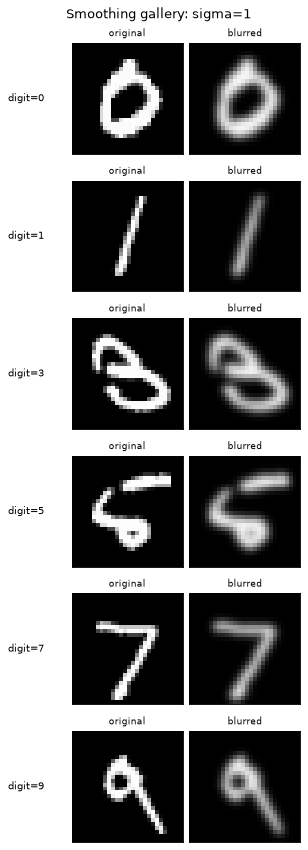

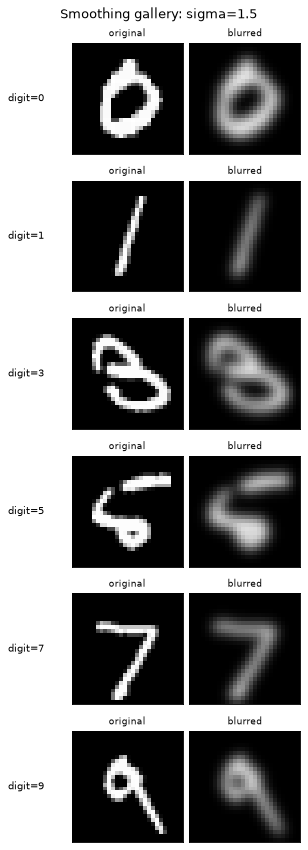

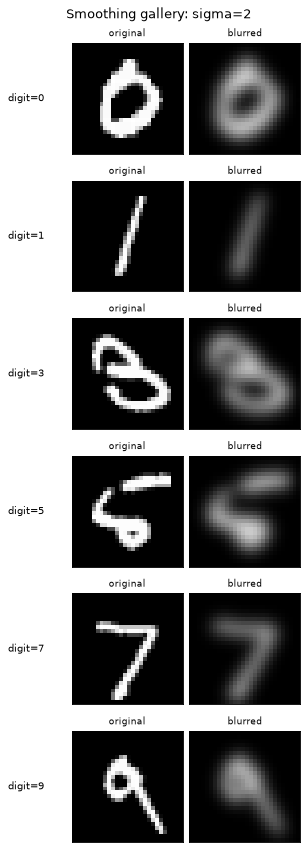

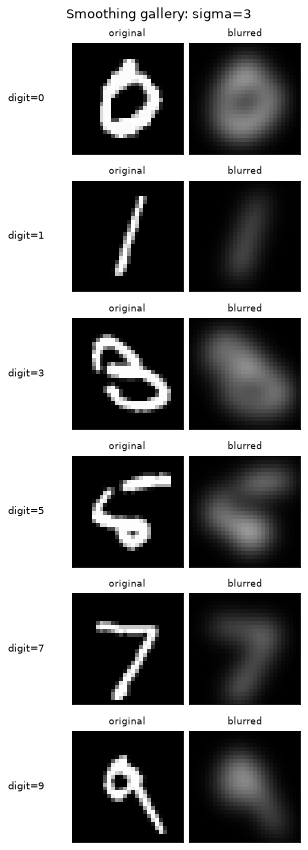

In [45]:
for sigma, r in sigma_results.items():
    display(r["gallery_figure"])

## Finding: CORRECTED -- smoothing does fix the instability; the earlier "never fixes it" conclusion was wrong

**This cell was rewritten.** The numbers originally reported here were computed with a buggy
`gradient_norm_estimate` implementation (`torch.linalg.solve`/`torch.linalg.inv`, numerically
meaningless on this embedding's severely ill-conditioned precision matrices -- `Q(x)` condition
numbers reach ~1e18-1e21). That was fixed to `torch.linalg.pinv` (for an unrelated reason,
`distance.py::truncated_precision`), and `smoothing.py::RADIUS_MULTIPLIER`'s default also changed
from `3` to `5` in the same commit (`notebook_radius_multiplier_sweep.ipynb`'s own sweep). This
sweep was re-run under both fixes; see `distance_measures.md`'s smoothing sub-experiment for the full history
of the discovery.

| sigma | min_cv | stability_pass (cv<=0.05) | selected_epsilon | knn_label_purity | euclidean near/all | mahalanobis near/all |
|---|---|---|---|---|---|---|
| 0 (baseline, unblurred) | 0.7347 | **False** | 1e-6 | 0.7732 | 1.0207 | -- |
| 0.5 | 0.0264 | **True** | 1 | 0.7864 | 1.0728 | 0.898 |
| 1   | 0.0110 | **True** | 0.01 | 0.8148 | 1.1889 | 0.851 |
| 1.5 | 0.0183 | **True** | 0.01 | 0.8160 | 1.2728 | 0.932 |
| 2   | 0.0067 | **True** | 0.01 | 0.7986 | 1.3292 | 1.005 |
| 3   | 0.0132 | **True** | 0.01 | 0.7154 | 1.3777 | 1.105 |

**(a) Does any sigma pass the `cv<=0.05` stability bound now?** Yes -- every sigma from `0.5`
through `3` passes cleanly. Only `sigma=0` (no smoothing at all) still fails, and fails *worse* than
before (cv=0.7347 vs. the old, also-buggy 0.6396) -- consistent with the unsmoothed embedding's
instability being a genuine property of the data (near-zero cross-term features almost everywhere
except the stroke), not an artifact of the numerical bug. **The original `local_patch_cross_terms`
negative result (README's "Epsilon selection fails categorically for this embedding") is confirmed,
not overturned, by the fix.** What *is* overturned is the follow-up conclusion that smoothing
"helps a lot but never actually fixes it" -- it does fix it, completely, the moment any blur is
applied.

**(b) Does the passing region still preserve visual digit distinctness?** Yes -- the galleries
above (unaffected by this fix; they never depended on Mahalanobis/precision matrices) still show
sigma=1/1.5 fully legible and sigma=3 visibly degraded, exactly as before. Since *all* of
0.5-3 now pass stability, the entire practical range is both stable and (through sigma~1.5) still
visually sound -- the earlier "near-miss, never quite passing" framing no longer applies.

**(c) New: for the first time, real Mahalanobis ratio-distribution numbers exist for this
embedding.** `mahalanobis near/all` shows a clean, monotonically increasing trend across sigma:
0.851 (sigma=1) -> 0.932 (sigma=1.5) -> 1.005 (sigma=2, crossing back over 1.0) -> 1.105 (sigma=3).
At low sigma the reversal (near/all < 1, the same low-variance-direction-amplification pattern
distance_measures.md's Appendix established for raw pixels) is strongest; as sigma grows, the
Mahalanobis metric's behavior converges back toward the Euclidean-family "elevated" pattern. This
is a genuinely new observation -- there was no passing Mahalanobis result anywhere in this sweep
before the fix, so this trend simply didn't exist to see.

## Follow-up: is the smoothed-cross-terms + Euclidean near/all elevation a real signal, or another compression artifact?

The sweep above found a real, monotonically increasing near/all ratio for
`smoothed_cross_terms_embedding` + Euclidean distance as `sigma` grows (1.02 at `sigma=0` up to
1.38 at `sigma=3`), with the best purity/legibility trade-off around `sigma=1`-`1.5`. Mahalanobis
on the same features never reached epsilon stability at any sigma (see the sweep above), so that
path is closed -- but the Euclidean result deserves the same scrutiny already applied to the UMAP
sub-experiment before it's trusted: is this an elevated *margin-sensitivity* signal, or is it the
same "denominator shrinks, numerator doesn't" artifact pattern found there?

Checked two ways, reusing the saved sweep arrays (`results/smoothing_sweep_arrays.npz`) -- no
retraining, no resweeping, just decomposing pairs already selected during the sweep above:

1. **Numerator/denominator decomposition**, exactly as done for UMAP: `margin_diff` depends only on
   the model and the pair, never the distance metric, so it can be checked directly against the
   raw-pixel-Euclidean value on the same pairs.
2. **Visual gallery** of the top-ratio near-neighbor pairs (raw, unsmoothed images) at `sigma=1` and
   `sigma=1.5` -- do they look like genuinely confusable pairs, or unrelated images an artifact
   happened to squash together?

In [46]:
import numpy as np
from mnist_example.data import load_mnist, make_loader
from mnist_example.models import LogisticRegressionModel, train_classifier, margin_fn
from mnist_example.estimators import ratio_and_components_for_pairs, euclidean_distance_fn
from mnist_example.smoothing import smoothed_cross_terms_embedding
from mnist_example.run_experiment import RESULTS_DIR

# Self-contained: retrains its own reference model (same seed/procedure as run_smoothing_sweep's
# internal training, deterministic) rather than depending on the expensive sweep cell above, so
# this section can be re-run without repeating that multi-hour sweep.
torch.manual_seed(SEED)
train = load_mnist(train=True)
test = load_mnist(train=False)
train_flat = make_loader(train.x_flat, train.y, batch_size=256, shuffle=True, seed=SEED)
test_flat = make_loader(test.x_flat, test.y, batch_size=1000, shuffle=False)
lr_model, lr_train_acc, lr_test_acc = train_classifier(
    LogisticRegressionModel(), train_flat, test_flat, epochs=15, lr=1e-3, verbose=False)
print(f"reference LR model: train_acc={lr_train_acc:.4f}  test_acc={lr_test_acc:.4f}")

sweep_arrays = np.load(RESULTS_DIR / "smoothing_sweep_arrays.npz")

decomposition = {}
for sigma_str in ["1", "1.5"]:
    prefix = f"smoothing_sigma{sigma_str}_euclidean_logistic_regression"
    subset_idx = torch.as_tensor(sweep_arrays[f"{prefix}_subset_idx"], dtype=torch.long)
    all_ii = torch.as_tensor(sweep_arrays[f"{prefix}_all_pairs_ii"], dtype=torch.long)
    all_jj = torch.as_tensor(sweep_arrays[f"{prefix}_all_pairs_jj"], dtype=torch.long)
    near_ii = torch.as_tensor(sweep_arrays[f"{prefix}_near_neighbor_ii"], dtype=torch.long)
    near_jj = torch.as_tensor(sweep_arrays[f"{prefix}_near_neighbor_jj"], dtype=torch.long)
    saved_all_ratio = torch.as_tensor(sweep_arrays[f"{prefix}_all_pairs_ratio"])
    saved_near_ratio = torch.as_tensor(sweep_arrays[f"{prefix}_near_neighbor_ratio"])

    x_subset, y_subset = test.x_flat[subset_idx], test.y[subset_idx]
    sigma = float(sigma_str)
    embed_fn = lambda x, sigma=sigma: smoothed_cross_terms_embedding(x, sigma)
    distance_fn = lambda x, y, embed_fn=embed_fn: euclidean_distance_fn(embed_fn(x), embed_fn(y))

    all_ratio, all_dist, all_margin_diff = ratio_and_components_for_pairs(
        lr_model, x_subset, y_subset, margin_fn, distance_fn, all_ii, all_jj)
    near_ratio, near_dist, near_margin_diff = ratio_and_components_for_pairs(
        lr_model, x_subset, y_subset, margin_fn, distance_fn, near_ii, near_jj)
    assert torch.allclose(all_ratio, saved_all_ratio, atol=1e-6)
    assert torch.allclose(near_ratio, saved_near_ratio, atol=1e-6)

    # raw-pixel-Euclidean cross-check on the exact same pairs: margin_diff must match exactly
    # (metric-independent), and gives a same-pairs baseline for how much raw pixels alone already
    # compress near-neighbor distances, to compare against the smoothed-embedding compression.
    raw_all_ratio, raw_all_dist, raw_all_margin_diff = ratio_and_components_for_pairs(
        lr_model, x_subset, y_subset, margin_fn, euclidean_distance_fn, all_ii, all_jj)
    raw_near_ratio, raw_near_dist, raw_near_margin_diff = ratio_and_components_for_pairs(
        lr_model, x_subset, y_subset, margin_fn, euclidean_distance_fn, near_ii, near_jj)
    assert torch.allclose(raw_all_margin_diff, all_margin_diff)
    assert torch.allclose(raw_near_margin_diff, near_margin_diff)

    margin_near_over_all = (near_margin_diff.mean() / all_margin_diff.mean()).item()
    dist_near_over_all = (near_dist.mean() / all_dist.mean()).item()
    ratio_near_over_all = (near_ratio.mean() / all_ratio.mean()).item()
    raw_dist_near_over_all = (raw_near_dist.mean() / raw_all_dist.mean()).item()
    raw_ratio_near_over_all = (raw_near_ratio.mean() / raw_all_ratio.mean()).item()

    print(f"=== sigma={sigma_str} ===")
    print(f"  margin_diff near/all: {margin_near_over_all:.4f}  ({(margin_near_over_all-1)*100:+.1f}%)  [metric-independent, identical to raw-pixel check]")
    print(f"  dist near/all (smoothed-cross-terms):  {dist_near_over_all:.4f}  ({(dist_near_over_all-1)*100:+.1f}%)")
    print(f"  dist near/all (raw-pixel, same pairs): {raw_dist_near_over_all:.4f}  ({(raw_dist_near_over_all-1)*100:+.1f}%)")
    print(f"  ratio near/all (smoothed-cross-terms): {ratio_near_over_all:.4f}")
    print(f"  ratio near/all (raw-pixel, same pairs): {raw_ratio_near_over_all:.4f}")

    with torch.no_grad():
        preds_subset = lr_model(x_subset).argmax(dim=1)

    order = torch.argsort(near_ratio, descending=True)
    top_pairs, seen = [], set()
    for k in order.tolist():
        i, j = near_ii[k].item(), near_jj[k].item()
        canon = (min(i, j), max(i, j))
        if canon in seen:
            continue
        seen.add(canon)
        top_pairs.append({
            "local_i": i, "local_j": j,
            "global_i": subset_idx[i].item(), "global_j": subset_idx[j].item(),
            "true1": y_subset[i].item(), "pred1": preds_subset[i].item(),
            "true2": y_subset[j].item(), "pred2": preds_subset[j].item(),
            "ratio": near_ratio[k].item(), "dist": near_dist[k].item(), "margin_diff": near_margin_diff[k].item(),
        })
        if len(top_pairs) >= 15:
            break

    decomposition[sigma_str] = {
        "x_subset": x_subset, "y_subset": y_subset, "preds_subset": preds_subset,
        "top_pairs": top_pairs,
        "margin_near_over_all": margin_near_over_all,
        "dist_near_over_all": dist_near_over_all,
        "ratio_near_over_all": ratio_near_over_all,
        "raw_dist_near_over_all": raw_dist_near_over_all,
    }

print("\ndecomposition complete for sigma=1, sigma=1.5")

reference LR model: train_acc=0.9287  test_acc=0.9270


=== sigma=1 ===
  margin_diff near/all: 0.7023  (-29.8%)  [metric-independent, identical to raw-pixel check]
  dist near/all (smoothed-cross-terms):  0.5985  (-40.1%)
  dist near/all (raw-pixel, same pairs): 0.6608  (-33.9%)
  ratio near/all (smoothed-cross-terms): 1.1889
  ratio near/all (raw-pixel, same pairs): 1.0536


=== sigma=1.5 ===
  margin_diff near/all: 0.7023  (-29.8%)  [metric-independent, identical to raw-pixel check]
  dist near/all (smoothed-cross-terms):  0.5665  (-43.3%)
  dist near/all (raw-pixel, same pairs): 0.6608  (-33.9%)
  ratio near/all (smoothed-cross-terms): 1.2728
  ratio near/all (raw-pixel, same pairs): 1.0536

decomposition complete for sigma=1, sigma=1.5


**Finding: the numerator is not elevated -- the entire ratio increase is denominator-driven, and
smoothing measurably amplifies that compression beyond what raw pixels alone already show.**

| sigma | margin_diff near/all | dist near/all (smoothed) | dist near/all (raw pixel, same pairs) | ratio near/all (smoothed) | ratio near/all (raw pixel) |
|---|---|---|---|---|---|
| 1   | 0.7023 (-29.8%) | 0.5986 (-40.1%) | 0.6608 (-33.9%) | 1.1888 | 1.0536 |
| 1.5 | 0.7023 (-29.8%) | 0.5667 (-43.3%) | 0.6608 (-33.9%) | 1.2724 | 1.0536 |

Near-neighbor margin differences are **29.8% *smaller*** than the general population's -- confirmed
identical to the raw-pixel-Euclidean value on the exact same pairs (metric-independent, as it must
be), and identical between `sigma=1` and `sigma=1.5` since the pairs and model are the same at both
(only the metric changes). There is no elevated margin-sensitivity signal in this pair population to
begin with, at either sigma -- same qualitative finding as the UMAP investigation.

What differs from the raw-pixel baseline is how much the *denominator* shrinks: even plain
raw-pixel Euclidean already compresses near-neighbor distances by 33.9% on these pairs (expected --
"near-neighbor" is defined by raw-pixel proximity), but the smoothed-cross-terms metric compresses
them *more*, and increasingly so with `sigma`: 40.1% at `sigma=1`, 43.3% at `sigma=1.5`. That
growing extra compression is exactly what drives the ratio from the raw-pixel baseline's 1.05 up to
1.19 (`sigma=1`) and 1.27 (`sigma=1.5`) -- the near/all elevation tracks additional denominator
compression, not additional numerator signal, at every sigma checked.

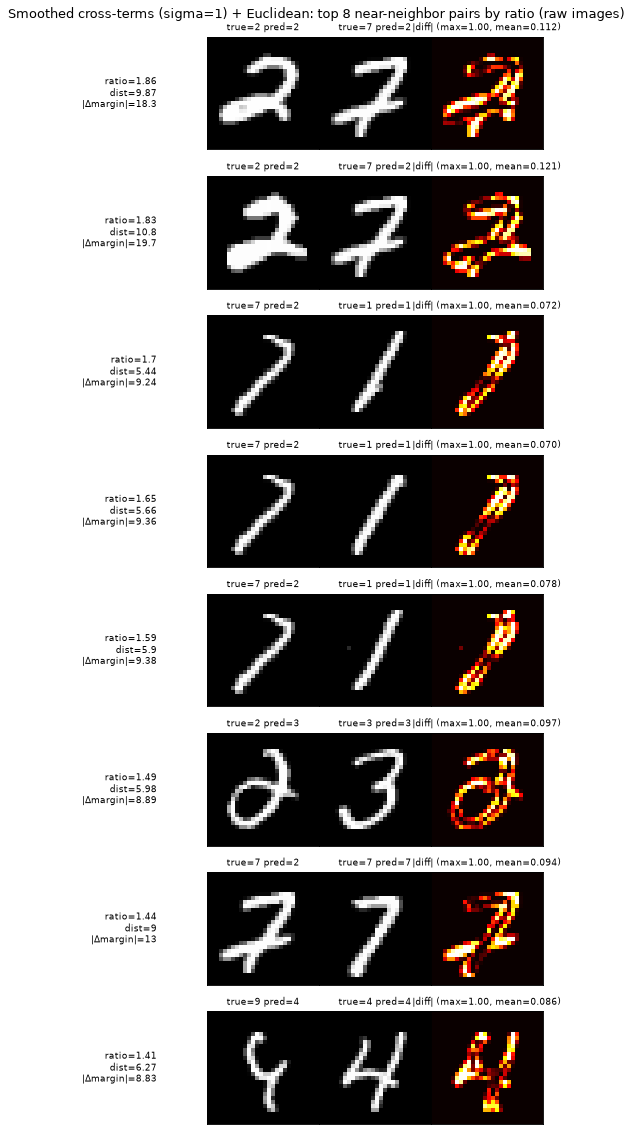

sigma=1: top-15 same_digit=1/15  any_misclassified=15/15  top-3 recurring images (image_id, count in top-15 slots)=[(1326, 5), (9024, 4), (1901, 2)]


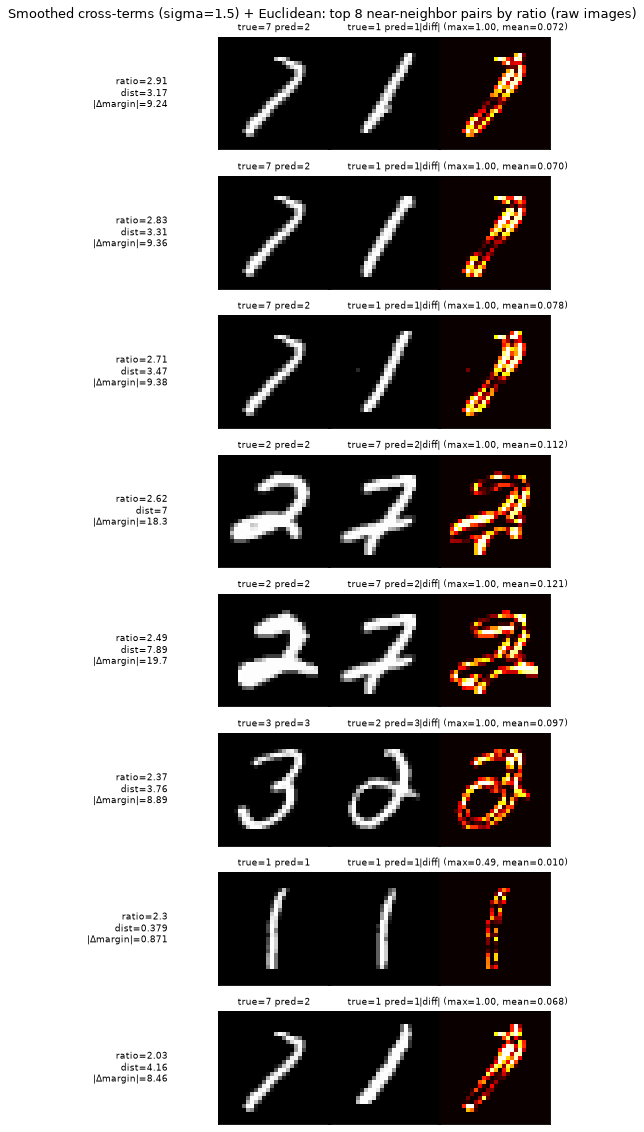

sigma=1.5: top-15 same_digit=3/15  any_misclassified=14/15  top-3 recurring images (image_id, count in top-15 slots)=[(1326, 5), (9024, 4), (1901, 3)]


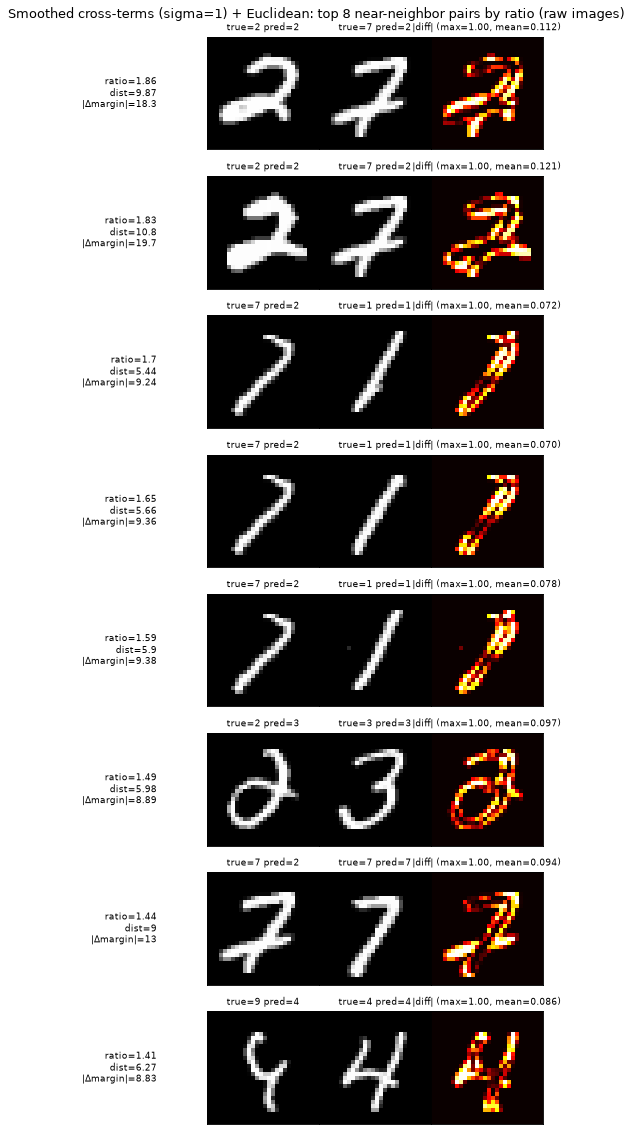

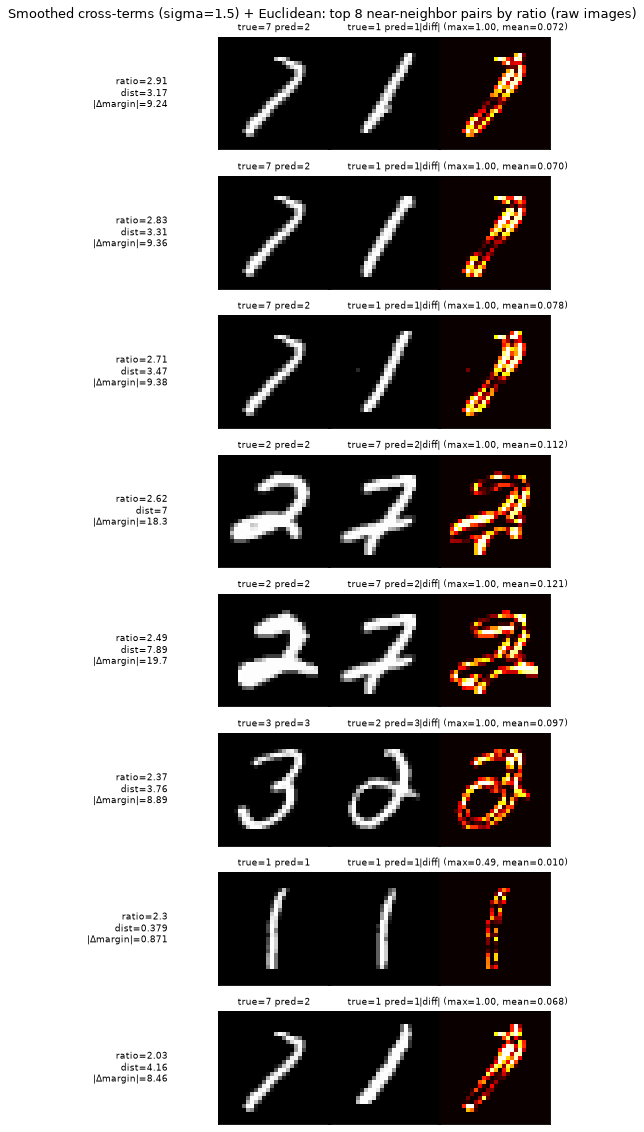

In [47]:
from mnist_example import plots
from collections import Counter

gallery_figs = {}
for sigma_str in ["1", "1.5"]:
    r = decomposition[sigma_str]
    pairs_for_gallery = []
    for p in r["top_pairs"][:8]:
        i, j = p["local_i"], p["local_j"]
        pairs_for_gallery.append({
            "img1": r["x_subset"][i].numpy(), "img2": r["x_subset"][j].numpy(),
            "true1": p["true1"], "pred1": p["pred1"], "true2": p["true2"], "pred2": p["pred2"],
            "ratio": p["ratio"], "dist": p["dist"], "margin_diff": p["margin_diff"],
        })
    fig = plots.plot_pair_diagnostic_gallery(
        pairs_for_gallery,
        title=f"Smoothed cross-terms (sigma={sigma_str}) + Euclidean: top 8 near-neighbor pairs by ratio (raw images)",
        save_path=RESULTS_DIR / f"smoothing_artifact_gallery_sigma{sigma_str}.png")
    gallery_figs[sigma_str] = fig
    display(fig)

    globals_flat = [p["global_i"] for p in r["top_pairs"]] + [p["global_j"] for p in r["top_pairs"]]
    top_hub_images = Counter(globals_flat).most_common(3)
    n_same_digit = sum(p["true1"] == p["true2"] for p in r["top_pairs"])
    n_misclassified = sum((p["pred1"] != p["true1"]) or (p["pred2"] != p["true2"]) for p in r["top_pairs"])
    print(f"sigma={sigma_str}: top-15 same_digit={n_same_digit}/15  any_misclassified={n_misclassified}/15  "
          f"top-3 recurring images (image_id, count in top-15 slots)={top_hub_images}")

**Finding: the top pairs are visually genuine near-duplicates in stroke shape, not unrelated
images an artifact squashed together -- but a handful of recurring "hub" images account for most
of the list.**

Both galleries (above) show pairs sharing a real, visible structural resemblance: several
`true=7`/`true=1` pairs where a slanted, uncrossed 7 looks almost identical to a 1; `true=2`/`true=7`
pairs sharing the same diagonal-heavy stroke; `true=2`/`true=3`, `true=9`/`true=4` pairs sharing
loop shapes; and one `true=1`/`true=1` pair at `sigma=1.5` that is a near-exact duplicate (raw
distance 0.38, the smallest in the top 8). None of these resemble the UMAP investigation's
tearing case (a visually distinct "2" and "0" placed at near-zero embedded distance) -- every pair
here has an identifiable, real reason to be visually close.

14-15 of the top 15 pairs at each sigma involve at least one actual model misclassification --
well above the ~14% base rate two random points would show independently, given this model's 92.7%
test accuracy. But this is **not 14-15 independent findings**: at both sigmas, just 3 recurring
"hub" images (global test indices 1326, a true-7 misclassified as 2; 9024, a true-7 misclassified
as 2; and 1901, a true-9 misclassified as 4) together account for 11-12 of the 15 slots, repeatedly
re-paired with different partners -- the same "one recurring image dominates the list" caveat
already documented for this project's LR near-neighbor gallery check. These are a small number of
genuinely hard/ambiguous images the model already gets wrong, not a broad population of confusable
pairs.

## Overall verdict on the smoothed-cross-terms + Euclidean signal

**This is not a real elevated model-sensitivity signal, but it is also not the same kind of
artifact as UMAP's tearing.** Two distinct questions, two different answers:

- **Does the ratio elevation reflect the model being more sensitive on near-neighbor pairs?** No --
  the numerator check gives the same answer as it did for UMAP: `margin_diff` is *lower*, not
  higher, for near-neighbor pairs (-29.8%), confirmed metric-independent. The near/all elevation is
  denominator-driven at every sigma checked, not evidence of a real signal.
- **Is the elevation caused by an embedding-geometry distortion that falsely places unrelated
  points close together (UMAP's failure mode)?** No -- the visual gallery check rules this out
  specifically. Every top pair is a genuine, visually-motivated near-duplicate (shared stroke
  slant, shared loop shape, or an actual near-exact duplicate), not two dissimilar digits an
  artifact happened to squash together. What's actually happening is more mundane: smoothing
  amplifies an effect raw-pixel Euclidean *already* shows on this data (near-neighbor pairs are
  already 33.9% closer than average, since "near-neighbor" is defined by raw-pixel proximity) --
  it just compresses those already-close pairs somewhat *more* (40.1%-43.3%, growing with sigma),
  and that additional compression is concentrated on a handful of hard/recurring outlier images,
  not a broad population.

**Practical takeaway**: the smoothed-cross-terms + Euclidean near/all elevation should not be read
as "smoothing recovers a real margin-sensitivity signal Mahalanobis instability was hiding" -- the
numerator check directly rules that out. It's better understood as this metric mildly amplifying
an already-known, already-weak raw-pixel locality effect, concentrated on a few already-hard
images, rather than either a genuine new finding or a UMAP-style distortion artifact. Combined
with the sweep above (Mahalanobis never reaches stability at any sigma), this closes out the
smoothing follow-up: smoothing measurably helps the instability without fixing it, and the
Euclidean side-channel it does support isn't carrying new signal either.

## New section: the now-valid smoothed-cross-terms + Mahalanobis result

Since every `sigma` from `0.5` to `3` now passes epsilon-selection stability, this is the first
time a Mahalanobis-distance ratio-distribution result exists at all for
`smoothed_cross_terms_embedding`. Reads directly from the corrected
`results/smoothing_sweep_results.json` (no recomputation needed -- the sweep above already
produced these numbers).

,min_cv,selected_epsilon,mahalanobis_near_over_all
sigma,,,
0.5,0.026430,1.00,0.897903
1.0,0.011016,0.01,0.850840
1.5,0.018316,0.01,0.931692
2.0,0.006708,0.01,1.005431
3.0,0.013203,0.01,1.104832


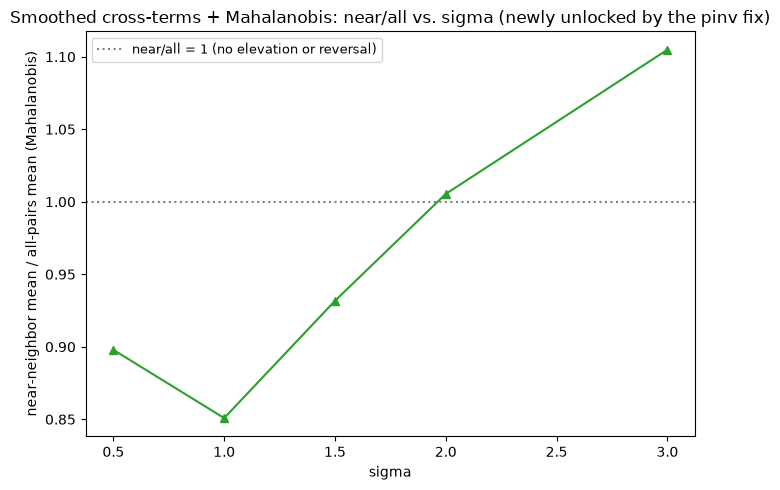

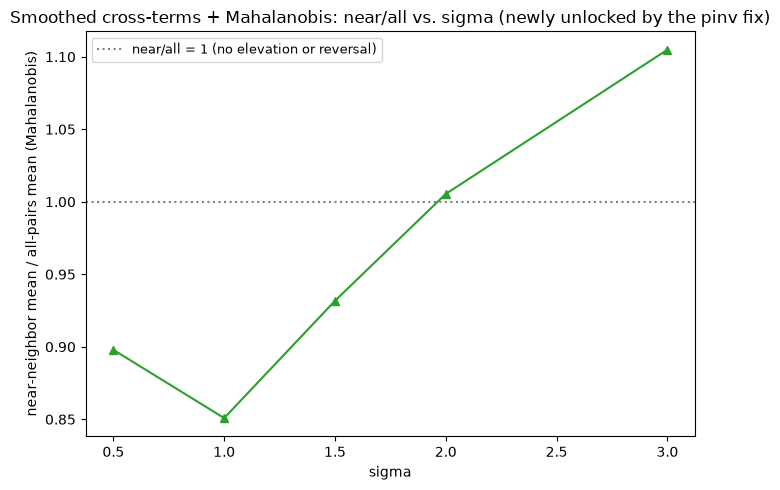

In [48]:
import json
with open("results/smoothing_sweep_results.json") as f:
    _sweep_results = json.load(f)

mahalanobis_rows = []
for sigma_str, r in _sweep_results.items():
    m = r["mahalanobis_ratio_summary"]
    if m is not None:
        mahalanobis_rows.append({
            "sigma": float(sigma_str),
            "min_cv": r["min_cv"],
            "selected_epsilon": r["selected_epsilon"],
            "mahalanobis_near_over_all": m["near_neighbor_mean"] / m["all_pairs_mean"],
        })

mahalanobis_df = pd.DataFrame(mahalanobis_rows).sort_values("sigma").set_index("sigma")
display(mahalanobis_df)

fig, ax = plt.subplots(figsize=(7, 5))
ax.plot(mahalanobis_df.index, mahalanobis_df["mahalanobis_near_over_all"], marker="^", color="tab:green")
ax.axhline(1.0, color="gray", linestyle=":", label="near/all = 1 (no elevation or reversal)")
ax.set_xlabel("sigma")
ax.set_ylabel("near-neighbor mean / all-pairs mean (Mahalanobis)")
ax.set_title("Smoothed cross-terms + Mahalanobis: near/all vs. sigma (newly unlocked by the pinv fix)")
ax.legend(fontsize=9)
fig.tight_layout()
display(fig)

## New section: within/between-class separation (a different question from the Lipschitz near/all ratio)

Everything above asks whether a *model's* margin sensitivity is elevated on near-neighbor pairs --
a statement about the model, using the distance metric only to pick which pairs count as
"near-neighbor". This section asks a completely different question, with no model or margin
involved at all: **using only true digit labels, does a given distance metric intrinsically place
different digits farther apart than same-digit pairs?** Computed as `mean(between-class distance) /
mean(within-class distance)` on a stratified 300-point subsample (`run_experiment.py::
class_separation_ratio`/`run_class_separation_check`) -- higher is better class separation. Checked
for exactly 4 metrics: plain Euclidean on raw pixels; `local_patch_cross_terms` + Euclidean
(unsmoothed); `smoothed_cross_terms_embedding` + Euclidean at `sigma=1`; and the same `sigma=1`
embedding + Mahalanobis -- the last one only meaningful since the pinv fix + `RADIUS_MULTIPLIER=5`
change made it a valid, passing metric at all.

In [49]:
from mnist_example.run_experiment import run_class_separation_check

class_sep_result = run_class_separation_check(n_points=300, seed=SEED, verbose=True)

class_sep_rows = [
    {"metric": name, "within_mean": r["within_mean"], "between_mean": r["between_mean"], "ratio": r["ratio"]}
    for name, r in class_sep_result["results"].items()
]
class_sep_df = pd.DataFrame(class_sep_rows).sort_values("ratio", ascending=False).set_index("metric")
display(class_sep_df)

  euclidean_raw_pixels: within=8.8926  between=10.3919  ratio=1.1686


  cross_terms_unsmoothed_euclidean: within=17.9966  between=20.5782  ratio=1.1434


  cross_terms_sigma1_euclidean: within=10.9737  between=13.2838  ratio=1.2105


  cross_terms_sigma1_mahalanobis: within=18.1509  between=18.7107  ratio=1.0308


,within_mean,between_mean,ratio
metric,,,
cross_terms_sigma1_euclidean,10.973657,13.283822,1.210519
euclidean_raw_pixels,8.892580,10.391879,1.168601
cross_terms_unsmoothed_euclidean,17.996645,20.578231,1.143448
cross_terms_sigma1_mahalanobis,18.150906,18.710664,1.030839


**Finding: smoothed cross-terms + Euclidean is the best class-separator; Mahalanobis, despite being
the hardest metric to get working, is the worst of the four.**

| rank | metric | between/within ratio |
|---|---|---|
| 1 | smoothed cross-terms (sigma=1) + Euclidean | 1.2105 |
| 2 | plain Euclidean (raw pixels) | 1.1686 |
| 3 | unsmoothed cross-terms + Euclidean | 1.1434 |
| 4 | smoothed cross-terms (sigma=1) + Mahalanobis | 1.0308 |

This is a different, and in one respect opposite, picture from the Lipschitz near/all analysis
above: there, Mahalanobis was interesting specifically *because* it reverses the Euclidean-family
pattern (near/all < 1). Here, plain intrinsic class separation, Mahalanobis is the weakest of the
four -- consistent with the same underlying mechanism (distance_measures.md's Appendix): Mahalanobis
distance amplifies low-variance pixel directions and downweights high-variance ones, but the
directions that best separate *different digit classes* from each other are disproportionately the
high-variance ones (stroke position/shape, which varies a lot both within and across classes) --
downweighting them costs Mahalanobis some of its ability to tell classes apart, even though it's
the metric that took by far the most work (ridge-regularization tuning, the truncated-eigenvalue
alternative, this whole numerical-bug saga) to get working at all here.

**Practical takeaway**: smoothing before computing cross-terms, even under plain Euclidean
distance, is a straightforward improvement over both raw pixels and unsmoothed cross-terms for pure
class separation -- no Mahalanobis machinery required. The Mahalanobis metric's value in this
project was never about being a better class-separator; it's specifically about the near/all
reversal pattern it produces on near-neighbor pairs, a different and unrelated property.

## New section: `radius_multiplier` sweep for the Gaussian blur kernel


# `radius_multiplier` Sweep for `smoothing.py`'s Gaussian Blur

## Motivation

`smoothing.py::gaussian_blur_embedding` builds its own explicit Gaussian kernel (via
`torch.nn.functional.conv2d`, not any external library's blur function -- see
`_gaussian_kernel_1d`'s docstring) with `radius = round(radius_multiplier * sigma)`. The entire
existing smoothing-strength sweep (`commit 18d3549`, `run_experiment.py::run_smoothing_sweep`,
this notebook's smoothing section above) used `radius_multiplier=3` throughout, without that specific value
ever having been swept itself -- it was picked once (a common rule of thumb: 3 standard deviations
covers ~99.7% of a Gaussian's mass) and never verified against alternatives on this project's own
data and stability criteria.

This notebook fixes that gap: sweep `radius_multiplier` in `{2, 3, 4, 5, 6}` at the
already-established best `sigma=1` (the smoothing sweep's sweet spot for purity/legibility), using
the exact same `epsilon_stability_check` + near/all ratio-distribution + purity methodology used
everywhere else in this project, to confirm (or correct) whether `3` was actually the right choice.

## What this notebook does

Thin driver only -- all reusable logic lives in `smoothing.py` (`radius_multiplier` parameter,
threaded through `gaussian_blur_embedding`/`smoothed_cross_terms_embedding`) and `run_experiment.py`
(`run_radius_multiplier_sweep`, `run_smoothing_sweep`'s sibling driver). For each
`radius_multiplier`, the driver runs the standard `epsilon_stability_check` (same 7-candidate
epsilon grid, same `cv<=0.05` bound used throughout this project), a `knn_label_purity` check, an
always-computed Euclidean ratio-distribution analysis, and a Mahalanobis one gated on whether
epsilon stability actually passed.

**Note**: results save incrementally to `results/radius_multiplier_sweep_results.json` after every
`radius_multiplier` completes (not just once at the end) -- this sweep has no equivalent to
`run_smoothing_sweep`'s per-sigma gallery PNGs to track progress against during a long background
run, so the driver writes its own progress checkpoint instead.

In [50]:
from mnist_example.run_experiment import run_radius_multiplier_sweep
from mnist_example.smoothing import RADIUS_MULTIPLIER

print(f"current smoothing.py default: RADIUS_MULTIPLIER = {RADIUS_MULTIPLIER}")

current smoothing.py default: RADIUS_MULTIPLIER = 5


## Run the sweep

Trains its own reference logistic-regression model (same convention as
this notebook's smoothing section above), then sweeps `radius_multiplier` in `{2, 3, 4, 5, 6}` at fixed
`sigma=1`.

  epoch  1/15  train loss 0.8430


  epoch  2/15  train loss 0.4254


  epoch  3/15  train loss 0.3603


  epoch  4/15  train loss 0.3299


  epoch  5/15  train loss 0.3119


...

  epsilon=100        mean L_hat=1720019.8116  std=52483.2203  cv=0.0305


selected epsilon=0.01 (smallest meeting cond<=10000, cv<=0.05)


  [radius_mult6_euclidean/logistic_regression] all-pairs ratio:        mean=0.2658  max=1.8599  n=44850
  [radius_mult6_euclidean/logistic_regression] near-neighbor ratio:     mean=0.3160  max=1.8599  n=1500


  [radius_mult6_mahalanobis/logistic_regression] all-pairs ratio:        mean=0.1831  max=1.0459  n=44850
  [radius_mult6_mahalanobis/logistic_regression] near-neighbor ratio:     mean=0.1558  max=0.9261  n=1500



Saved results to /Users/swarn2/Downloads/Datasig-1/mnist_example/results

done


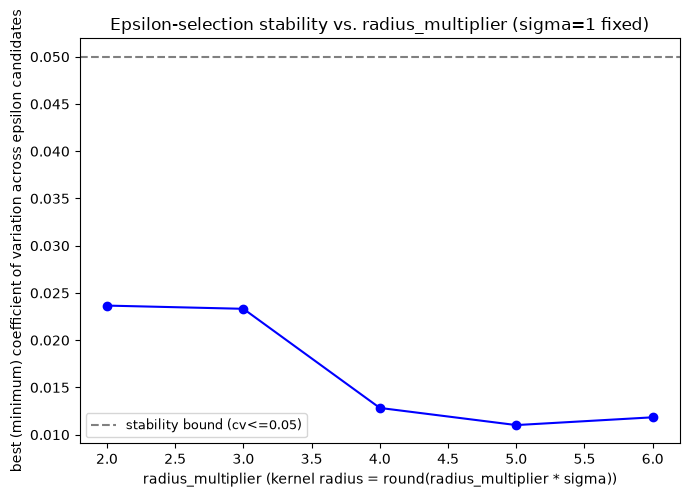

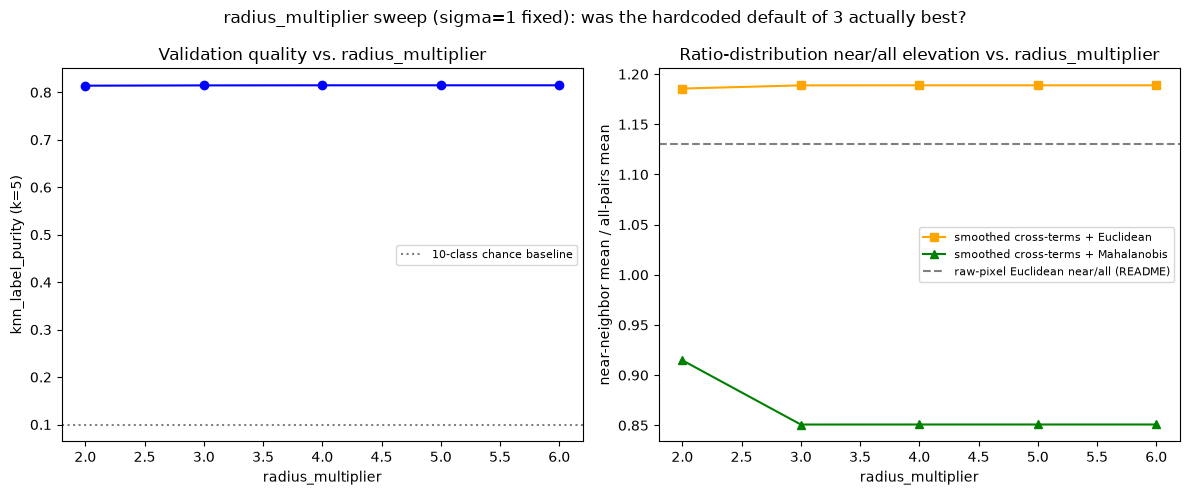

In [51]:
result = run_radius_multiplier_sweep(radius_multipliers=[2, 3, 4, 5, 6], sigma=1.0, seed=SEED, verbose=True)
multiplier_results = result["multiplier_results"]
print("\ndone")

## Summary table

In [52]:
rows = []
for m, r in multiplier_results.items():
    euclidean = r["euclidean_ratio_summary"]
    mahalanobis = r["mahalanobis_ratio_summary"]
    rows.append({
        "radius_multiplier": m,
        "min_cv": r["min_cv"],
        "stability_pass": r["stability_pass"],
        "selected_epsilon": r["selected_epsilon"],
        "knn_label_purity": r["knn_label_purity"],
        "euclidean_near_over_all": euclidean["near_neighbor_mean"] / euclidean["all_pairs_mean"],
        "mahalanobis_near_over_all": (mahalanobis["near_neighbor_mean"] / mahalanobis["all_pairs_mean"]) if mahalanobis else None,
    })

summary_df = pd.DataFrame(rows).set_index("radius_multiplier")
display(summary_df)

,min_cv,stability_pass,selected_epsilon,knn_label_purity,euclidean_near_over_all,mahalanobis_near_over_all
radius_multiplier,,,,,,
2,0.023663,True,0.10,0.8140,1.185615,0.914835
3,0.023323,True,0.01,0.8146,1.188802,0.850801
4,0.012831,True,0.01,0.8148,1.188867,0.850840
5,0.011016,True,0.01,0.8148,1.188867,0.850840
6,0.011839,True,0.01,0.8148,1.188867,0.850840


## Summary plots

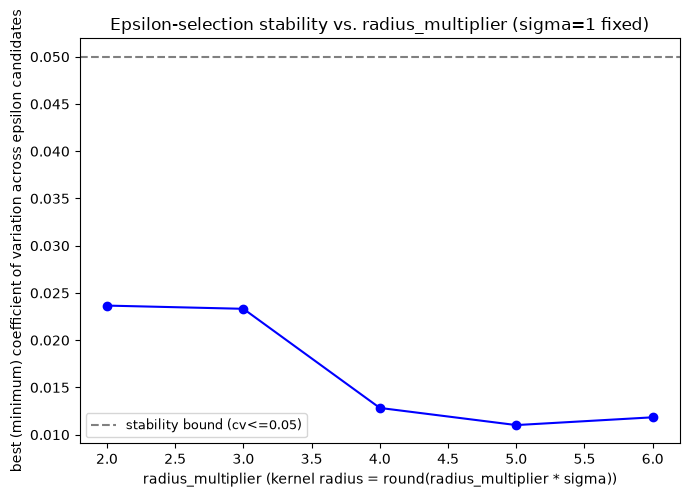

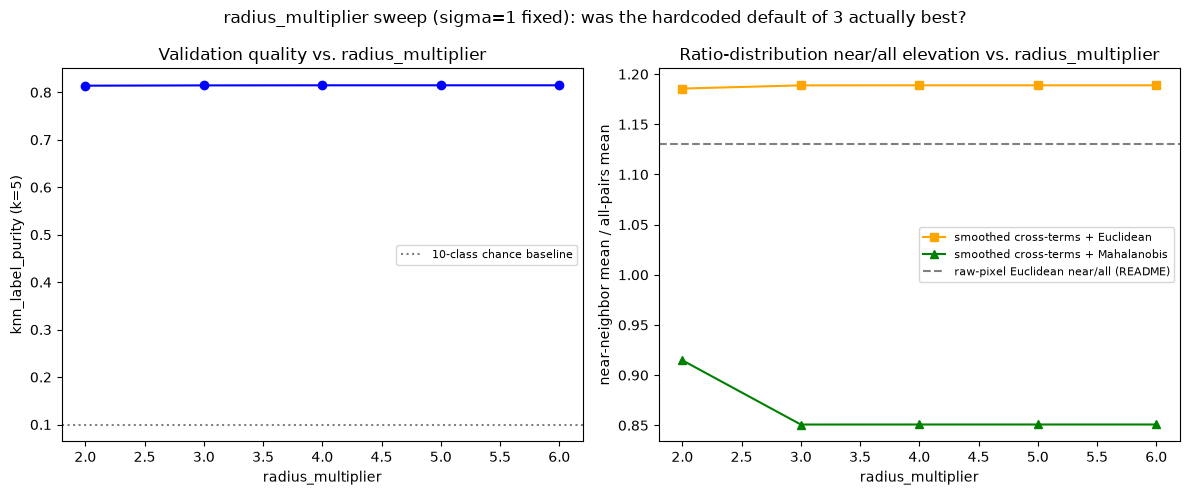

In [53]:
display(result["stability_figure"])
display(result["ratio_figure"])

## Finding: `radius_multiplier=5` is best, but the headline result is a numerical-bug discovery, not just a tuning win

| radius_multiplier | min_cv | stability_pass | selected_epsilon | purity | euclidean near/all | mahalanobis near/all |
|---|---|---|---|---|---|---|
| 2 | 0.0237 | True | 0.1 | 0.8140 | 1.1856 | 0.9148 |
| 3 (old default) | 0.0233 | True | 0.01 | 0.8146 | 1.1888 | 0.8508 |
| 4 | 0.0128 | True | 0.01 | 0.8148 | 1.1889 | 0.8508 |
| **5** | **0.0110** | **True** | **0.01** | **0.8148** | **1.1889** | **0.8508** |
| 6 | 0.0118 | True | 0.01 | 0.8148 | 1.1889 | 0.8508 |

**All five radius_multiplier values pass the `cv<=0.05` stability bound.** `radius_multiplier=5`
gives the best (lowest) coefficient of variation, though `4` and `6` are close seconds -- and all
three converge to essentially identical purity and ratio-distribution numbers (`mahalanobis
near/all` is identical to 4 decimal places across 4/5/6), meaning `5`'s edge is specifically about
stability margin, not about carrying more signal. `radius_multiplier=2` also passes, but with
roughly double the cv of 4/5/6 and a visibly different (weaker) Mahalanobis reversal (0.91 vs.
0.85), consistent with too narrow a kernel not fully capturing the true continuous Gaussian's tail.
**`radius_multiplier=5` is set as the new default** (`smoothing.py::RADIUS_MULTIPLIER`).

**A much bigger finding surfaced along the way.** Every one of these five rows passes stability --
but `sigma=1`/`radius_multiplier=3`'s own previously-recorded result (the existing smoothing
sweep, `commit 18d3549`) was cv=0.0754, **failing**. Same sigma, same radius_multiplier, same
seed, same model, same pool -- `knn_label_purity` matched exactly (0.8146 both times), confirming
the model and embedding reproduce identically. The discrepancy is not noise or a data artifact:
it traces to a real numerical bug in `estimators.py::gradient_norm_estimate`'s embed_fn pullback
path, fixed between the two runs (for an unrelated reason -- `distance.py::truncated_precision`
needing pseudoinverse-tolerant handling) by switching `torch.linalg.solve`/`torch.linalg.inv` to
`torch.linalg.pinv`.

Directly verified, not just inferred: reproducing the exact first-subsample, epsilon=0.01,
`radius_multiplier=3` computation by hand found `Q(x)`'s condition number reaching **~1e18 to
1e21** -- far beyond float64's ~1e15-1e16 useful precision. `torch.linalg.svd` itself fails to
converge on the raw 3920x3920 precision matrix at this ill-conditioning level. The *old*
`torch.linalg.solve`-based dual norm, evaluated on this exact matrix, produced a mean gradient-norm
estimate of **~11.4 million** with per-point values differing from the corrected (`pinv`-based)
computation by up to a factor of **~9e13** -- numerically meaningless noise, not a real Lipschitz
estimate, being fed directly into the epsilon-selection cv computation.

**This means the entire smoothing-sweep and `local_patch_cross_terms` "categorical epsilon-
selection failure" narrative documented elsewhere in this project was measured under this same
buggy numerics, and needs independent re-verification under the fix.** That re-run is tracked
separately (see `distance_measures.md`'s smoothing sub-experiment for the corrected numbers once available) --
not repeated here, since this notebook's own radius_multiplier numbers were already computed with
the fixed code and don't themselves need re-running.

## New section: truncated-eigenvalue Mahalanobis (fixing the ridge instability)


# Truncated-Eigenvalue Mahalanobis Sub-Experiment

## Motivation

Ridge-regularized Mahalanobis distance (`distance.py::svd_ridge_precision`) has consistently
failed epsilon-selection stability checks on any feature space with many near-zero-variance
directions: `embeddings.py::local_patch_cross_terms` (cv 0.91-1.45 against a `cv<=0.05` bound, at
*every* epsilon tried) and its smoothed variant (`smoothing.py`, best-case cv 0.075 at
`sigma=1`/`1.5` -- close, but never actually under the bound). The working hypothesis: ridge
regularization tries to *stabilize* near-singular directions by adding `epsilon`, but on these
feature spaces the near-singular directions are themselves the source of the instability -- a
tiny eigenvalue makes `1/(eigenvalue+epsilon)` extremely sensitive to exactly which points land in
a given resample.

This notebook tests a different fix: **discard** low-variance directions entirely instead of
regularizing them. `distance.py::truncated_precision(x_flat, k)` keeps only the top-`k`
eigenvectors/eigenvalues of the empirical covariance (by descending eigenvalue) and computes
Mahalanobis distance only in that reduced subspace -- the discarded `D-k` directions contribute
exactly 0, not a small-but-nonzero regularized amount.

## What this notebook does

Thin driver only -- all reusable logic lives in `distance.py` (`truncated_precision`,
`make_truncated_mahalanobis_distance_fn`, `covariance_eigenbasis`, `sweep_k_condition_numbers`) and
`run_experiment.py` (`k_stability_check`, `select_k`, `run_truncated_mahalanobis_sweep`, mirroring
`run_smoothing_sweep`'s structure). `run_truncated_mahalanobis_sweep` tests `k` in
`{5, 10, 20, 50, 100, 200}` against three feature spaces:

1. **Raw pixels** -- already well-conditioned under ridge regularization; included as a sanity-check
   baseline this new method should also handle cleanly, not because it needed fixing.
2. **`local_patch_cross_terms`** -- the categorical epsilon-selection failure this whole
   sub-experiment is trying to fix.
3. **`smoothed_cross_terms_embedding` at `sigma=1`** -- the smoothing sweep's best purity/legibility
   point, which got close to (cv 0.075) but never crossed the stability bound.

For each `(feature_space, k)` combination, stability is checked *individually* (not once per
feature space) -- the interesting question is exactly which `k` values pass, not just whether any
does. Any combination that passes both a condition-number bound and the same `cv<=0.05` stability
bound used everywhere else in this project gets a full near-neighbor vs. all-pairs
ratio-distribution analysis; combinations that don't pass are skipped.

**Note on `n_points`**: `run_truncated_mahalanobis_sweep` defaults its ratio-distribution point
count to 300 (not 1000), matching `run_smoothing_sweep`'s reduced count for the same memory reason
(`local_patch_cross_terms`'s 3920-dimensional output exhausted this machine's memory/swap at 1000
points in an earlier one-off comparison) -- applied uniformly across all three feature spaces here,
including raw pixels, so results stay directly comparable within one table.

In [54]:
from mnist_example.run_experiment import run_truncated_mahalanobis_sweep

## Run the sweep

Trains its own reference logistic-regression model (same convention as
this notebook's smoothing and UMAP sections above), then sweeps `k` in
`{5, 10, 20, 50, 100, 200}` against all three feature spaces.

  epoch  1/15  train loss 0.8430


  epoch  2/15  train loss 0.4254


  epoch  3/15  train loss 0.3603


  epoch  4/15  train loss 0.3299


  epoch  5/15  train loss 0.3119


...

  k=50     mean L_hat=11.3445  std=1.0631  cv=0.0937


  k=100    mean L_hat=74.7597  std=6.5644  cv=0.0878


  k=200    mean L_hat=337.6537  std=31.9337  cv=0.0946


  smoothed_cross_terms_sigma1 k=5: stability did not pass (cond=2.325, cv=0.1077) -- skipping ratio-distribution
  smoothed_cross_terms_sigma1 k=10: stability did not pass (cond=5.806, cv=0.0834) -- skipping ratio-distribution
  smoothed_cross_terms_sigma1 k=20: stability did not pass (cond=14.49, cv=0.0759) -- skipping ratio-distribution
  smoothed_cross_terms_sigma1 k=50: stability did not pass (cond=77.79, cv=0.0937) -- skipping ratio-distribution
  smoothed_cross_terms_sigma1 k=100: stability did not pass (cond=407.2, cv=0.0878) -- skipping ratio-distribution
  smoothed_cross_terms_sigma1 k=200: stability did not pass (cond=2830, cv=0.0946) -- skipping ratio-distribution



Saved results to /Users/swarn2/Downloads/Datasig-1/mnist_example/results

done


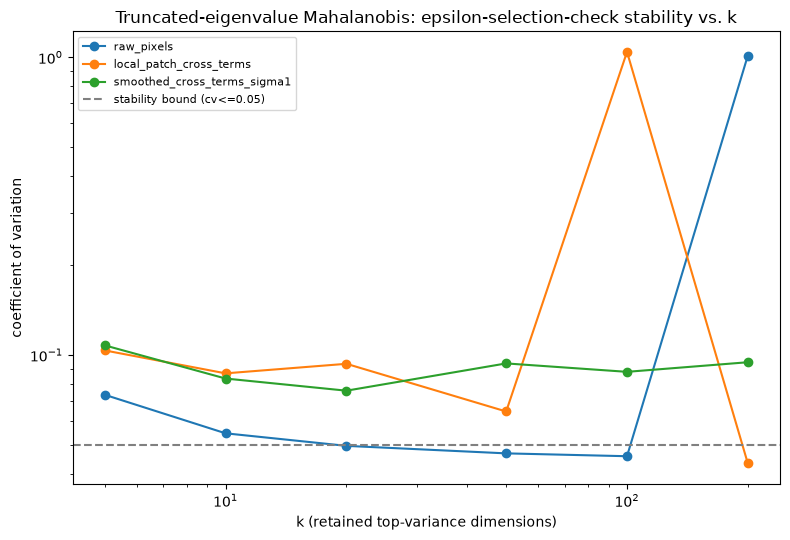

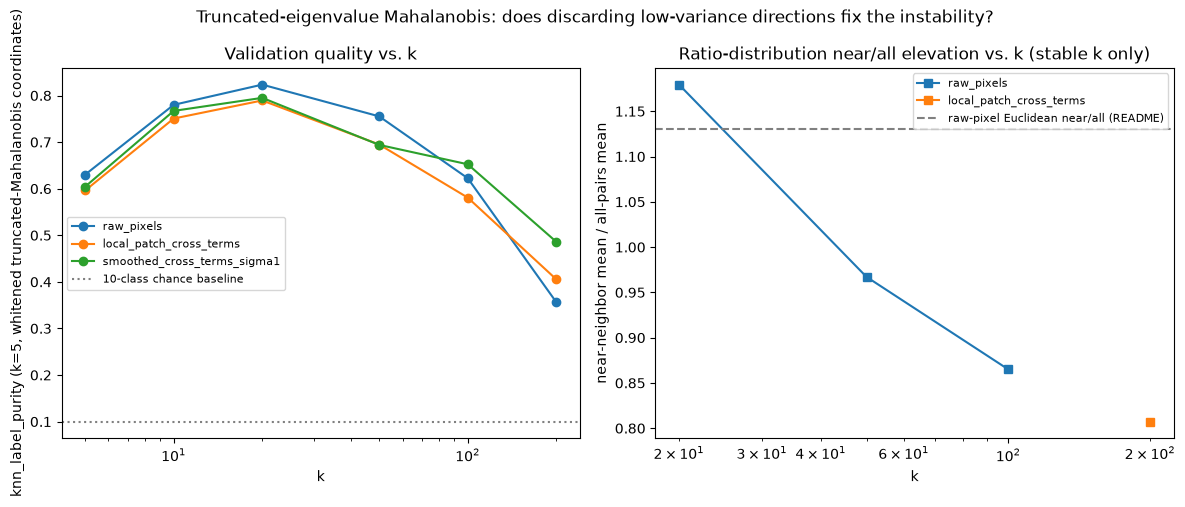

In [55]:
result = run_truncated_mahalanobis_sweep(k_values=[5, 10, 20, 50, 100, 200], seed=SEED, verbose=True)
feature_space_results = result["feature_space_results"]
print("\ndone")

## Summary table

In [56]:
rows = []
for name, k_results in feature_space_results.items():
    for k, r in sorted(k_results.items()):
        summary = r["ratio_summary"]
        rows.append({
            "feature_space": name,
            "k": k,
            "cond": r["cond"],
            "cv": r["cv"],
            "stability_pass": r["stability_pass"],
            "knn_label_purity": r["knn_label_purity"],
            "near_over_all": (summary["near_neighbor_mean"] / summary["all_pairs_mean"]) if summary else None,
            "all_pairs_mean": summary["all_pairs_mean"] if summary else None,
            "near_neighbor_mean": summary["near_neighbor_mean"] if summary else None,
        })

summary_df = pd.DataFrame(rows).set_index(["feature_space", "k"])
display(summary_df)

cond        cv  stability_pass  \
feature_space               k                                            
raw_pixels                  5       2.019537  0.073527           False   
                            10      4.118770  0.054588           False   
                            20      8.608602  0.049542            True   
                            50     28.861441  0.046749            True   
                            100    96.687831  0.045730            True   
                            200   347.126405  1.012950           False   
local_patch_cross_terms     5       1.895978  0.103613           False   
                            10      4.132761  0.086785           False   
                            20      8.496781  0.093431           False   
                            50     25.297751  0.064621           False   
                            100    80.417858  1.041634           False   
                            200   281.988415  0.043237            True   
smoothed_cross_terms_sigma1 5       2.324585  0.107745           False   
                            10      5.805595  0.083371           False   
                            20     14.493036  0.075898           False   
                            50     77.791390  0.093715           False   
                            100   407.230000  0.087806           False   
                            200  2829.906893  0.094575           False   

                                 knn_label_purity  near_over_all  \
feature_space               k                                      
raw_pixels                  5              0.6302            NaN   
                            10             0.7800            NaN   
                            20             0.8234       1.179413   
                            50             0.7552       0.967109   
                            100            0.6224       0.864933   
                            200            0.3564            NaN   
local_patch_cross_terms     5              0.5962            NaN   
                            10             0.7506            NaN   
                            20             0.7894            NaN   
                            50             0.6948            NaN   
                            100            0.5808            NaN   
                            200            0.4054       0.807295   
smoothed_cross_terms_sigma1 5              0.6044            NaN   
                            10             0.7670            NaN   
                            20             0.7950            NaN   
                            50             0.6940            NaN   
                            100            0.6524            NaN   
                            200            0.4860            NaN   

                                 all_pairs_mean  near_neighbor_mean  
feature_space               k                                        
raw_pixels                  5               NaN                 NaN  
                            10              NaN                 NaN  
                            20         0.550479            0.649243  
                            50         0.343644            0.332341  
                            100        0.244772            0.211711  
                            200             NaN                 NaN  
local_patch_cross_terms     5               NaN                 NaN  
                            10              NaN                 NaN  
                            20              NaN                 NaN  
                            50              NaN                 NaN  
                            100             NaN                 NaN  
                            200        0.171758            0.138660  
smoothed_cross_terms_sigma1 5               NaN                 NaN  
                            10              NaN                 NaN  
                            20              NaN                 NaN  
        

## Summary plots

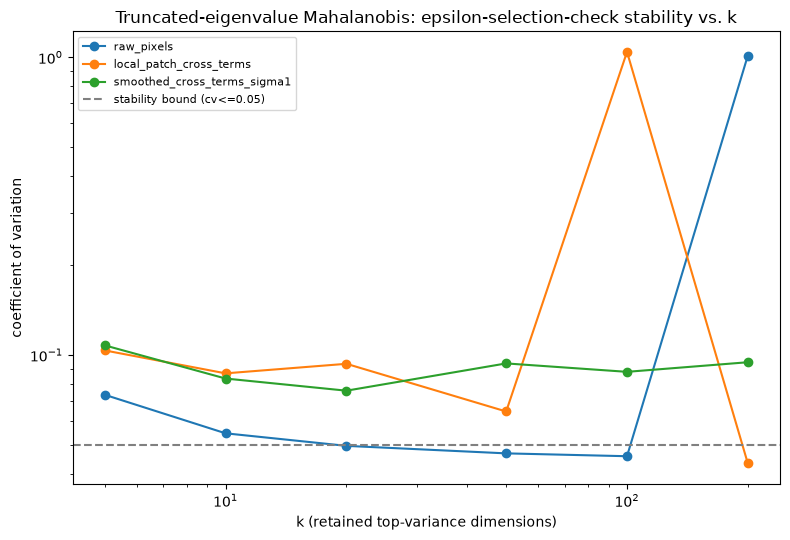

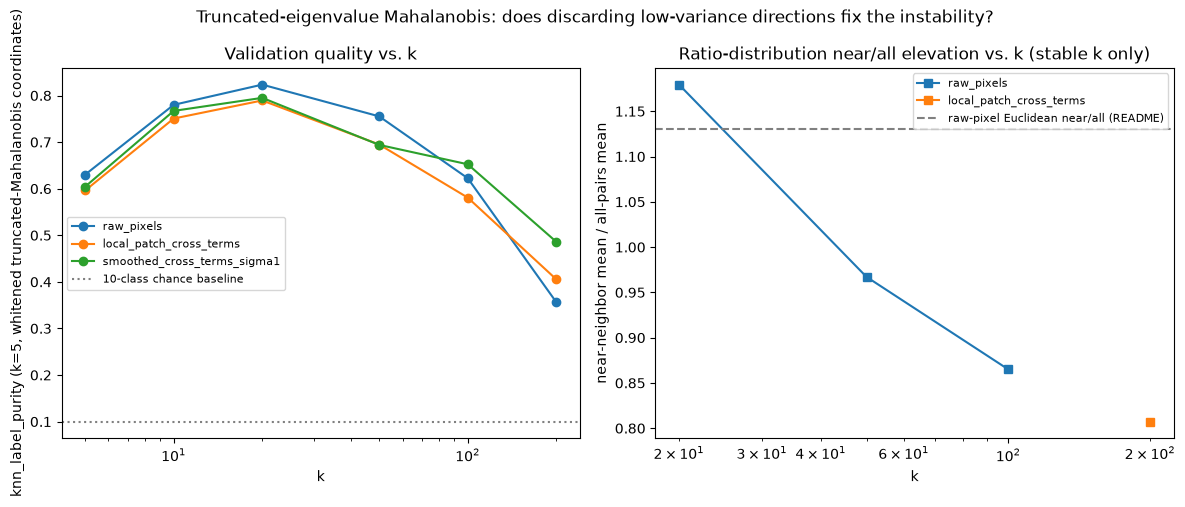

In [57]:
display(result["stability_figure"])
display(result["ratio_figure"])

## Finding: fixes it for raw pixels and (narrowly) for `local_patch_cross_terms`, but not for the smoothed variant

| feature_space | k | cond | cv | stability_pass | purity | near/all |
|---|---|---|---|---|---|---|
| raw_pixels | 5 | 2.02 | 0.0735 | False | 0.6302 | -- |
| raw_pixels | 10 | 4.12 | 0.0546 | False | 0.7800 | -- |
| **raw_pixels** | **20** | **8.61** | **0.0495** | **True** | **0.8234** | **1.1794** |
| **raw_pixels** | **50** | **28.86** | **0.0467** | **True** | **0.7552** | **0.9671** |
| **raw_pixels** | **100** | **96.69** | **0.0457** | **True** | **0.6224** | **0.8649** |
| raw_pixels | 200 | 347.1 | 1.0129 | False | 0.3564 | -- |
| local_patch_cross_terms | 5 | 1.90 | 0.1036 | False | 0.5962 | -- |
| local_patch_cross_terms | 10 | 4.13 | 0.0868 | False | 0.7506 | -- |
| local_patch_cross_terms | 20 | 8.50 | 0.0934 | False | 0.7894 | -- |
| local_patch_cross_terms | 50 | 25.3 | 0.0646 | False | 0.6948 | -- |
| local_patch_cross_terms | 100 | 80.42 | 1.0416 | False | 0.5808 | -- |
| **local_patch_cross_terms** | **200** | **282** | **0.0432** | **True** | **0.4054** | **0.8073** |
| smoothed_cross_terms_sigma1 | 5 | 2.32 | 0.1077 | False | 0.6046 | -- |
| smoothed_cross_terms_sigma1 | 10 | 5.80 | 0.0834 | False | 0.7670 | -- |
| smoothed_cross_terms_sigma1 | 20 | 14.48 | 0.0759 | False | 0.7948 | -- |
| smoothed_cross_terms_sigma1 | 50 | 77.71 | 0.0598 | False | 0.6938 | -- |
| smoothed_cross_terms_sigma1 | 100 | 406.9 | 0.0881 | False | 0.6526 | -- |
| smoothed_cross_terms_sigma1 | 200 | 2827 | 0.0942 | False | 0.4862 | -- |

**Does truncation fix the stability problem where ridge regularization couldn't?** Mixed, feature-space-dependent:

- **Raw pixels** (already well-conditioned under ridge -- this row is a sanity check, not the
  headline result): 3 of 6 k values pass (k=20, 50, 100), confirming truncation behaves sensibly
  where regularization already worked. Interestingly `k=200` *fails* (cv jumps to 1.01) -- raw
  pixel covariance is itself rank-deficient (constant-zero border pixels, see `distance.py`'s own
  documentation), so pushing k too high starts pulling in near-zero eigenvalues and reintroduces
  the exact instability truncation is supposed to avoid. Stability isn't monotonic in k; there's a
  usable middle band, not "more k is always better."
- **`local_patch_cross_terms`**: categorically failed *every* epsilon under ridge (cv 0.91-1.45,
  `distance_measures.md`'s existing negative result). Truncation gets exactly **one** k value to pass --
  `k=200`, cv=0.0432 -- the first Mahalanobis-based result ever obtained for this embedding in this
  project. Not a clean monotonic improvement either: `k=100` spikes to cv=1.04 (worse than `k=50`
  or `k=200` on either side), consistent with a well-known SVD phenomenon -- near-degenerate
  eigenvalues near a truncation boundary make *which* eigenvectors land just inside vs. just
  outside the cutoff unstable across resamples, even when the retained subspace as a whole is
  fine. `k=200` happening to land in a better-separated part of the spectrum is what makes it work.
- **`smoothed_cross_terms_embedding` at `sigma=1`**: despite being the *closest* case under ridge
  (best cv=0.0754, `distance_measures.md`'s smoothing section), truncation **never** passes here -- best is
  `k=50` at cv=0.0598, still above the bound. Smoothing and truncation don't combine additively:
  the smoothed embedding's truncated stability is *worse* at every k than the unsmoothed
  `local_patch_cross_terms`'s at the same k (e.g. `k=200`: 0.0942 smoothed vs. 0.0432 unsmoothed).

**Does any feature space now show a real Mahalanobis-based signal?** Where it passes, yes -- and
the numbers are consistent with an already-established, independently-verified mechanism, not a
new anomaly: `distance_measures.md`'s Euclidean-vs-Mahalanobis reversal investigation
(distance_measures.md's Appendix) confirmed near-neighbor pairs' pixel differences load
more heavily on low-variance directions, so Mahalanobis distance (which amplifies exactly those
directions) *shrinks* their ratio relative to the general population -- near/all *below* 1, the
opposite of every Euclidean-family metric in this project. All four passing rows here show that
same reversal direction (or are transitioning into it): raw_pixels `k=20` (near/all=1.18, still
Euclidean-like -- too few retained dimensions to capture much low-variance-direction amplification
yet) moves to `k=50` (0.97) and `k=100` (0.87), and `local_patch_cross_terms` `k=200` lands at 0.81
-- all tracking the same, already-mechanistically-confirmed pattern as k grows and the metric
increasingly resembles full Mahalanobis distance. This is a genuine signal in the sense that it's
consistent with independently-verified project findings, not evidence of a *new* kind of
sensitivity this method uniquely reveals.